In [145]:
# =============================================================================
# COMPLETE RADIOMICS PROCESSING PIPELINE FOR MULTI-MODALITY DATASETS
# =============================================================================
# This integrated notebook cell handles the complete automation pipeline for 
# radiomics feature standardization, naming conflict resolution, dynamic mapping 
# generation, and persistent cloud storage operations.
# =============================================================================

import os
import re
from pathlib import Path
import pandas as pd

print("=" * 80)
print("🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE ON KAGGLE")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. GLOBAL PIPELINE CONFIGURATIONS (CONFIG)
# -----------------------------------------------------------------------------
INPUT_FILE = "../Dataset/Breast-Data/Mask1/Pre_M1.csv"
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
TARGET_COLUMN = "Label"


# -----------------------------------------------------------------------------
# 2. FEATURE NOMENCLATURE TRANSFORMATION ALGORITHM
# -----------------------------------------------------------------------------
def clean_feature_name(col_name, target_column="Label"):
    """Standardizes radiomics feature identifiers according to scientific repository norms.

    Preprocessing Paradigm:
        1. Preserves the experimental target variable (e.g., Dose) dynamically.
        2. Isolates raw imaging modality prefixes (e.g., CT_, PET1_) and appends them as formal suffixes.
        3. Strips institutional validation or compliance standards enclosed in brackets (e.g., IBSI tags).
        4. Compresses prolonged radiomics terminology into unified abbreviations (e.g., Morph, IB, IH).
        5. Maintains diagnostic brackets while positioning the structural modality tag at the terminus.
    """
    original = str(col_name).strip()

    # Retain the exact experimental target variable structure
    protected_columns = {
        target_column,
        "INFO_PatientName",
        "INFO_NameOfRoi"
    }

    if original in protected_columns:
        return original
    
    new_name = original

    # B) Suppress institutional meta-tags and substrings enclosed within parentheses
    new_name = re.sub(r"\([^)]*\)", "", new_name)

    # C) Compress extensive radiomics ontological classes into scientific abbreviations
    new_name = re.sub(r"MORPHOLOGICAL", "Morph", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-BASED", "IB", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-HISTOGRAM", "IH", new_name, flags=re.IGNORECASE)

    # D) Clean whitespace discrepancies and uniformize underscores (_) within the body
    new_name = new_name.strip()
    new_name = re.sub(r"\s+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = re.sub(r"^_+|_+$", "", new_name)
    new_name = re.sub(r"[^0-9a-zA-Z_]+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = new_name.strip("_")
    return new_name


# -----------------------------------------------------------------------------
# 3. SPATIAL COLUMN COLLISION RESOLUTION
# -----------------------------------------------------------------------------
def make_unique_columns(columns):
    """Enforces absolute feature identification uniqueness across the dataset array.

    Resolves potential nomenclature collisions induced by feature compression processes 
    by appending serialized suffixes sequentially.
    """
    seen = {}
    unique_columns = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            unique_columns.append(col)
        else:
            seen[col] += 1
            unique_columns.append(f"{col}_{seen[col]}")

    return unique_columns


# -----------------------------------------------------------------------------
# 4. CORE PIPELINE EXECUTION ENGINE
# -----------------------------------------------------------------------------
file_path = Path(INPUT_FILE)
output_path = Path(OUTPUT_DIR)

if not file_path.exists():
    raise FileNotFoundError(f"❌ Input dataset not found at the specified path: {INPUT_FILE}")

print(f"📖 Reading dataset: {file_path.name}")

all_mappings = []

try:
    # Ingest source dataset from Kaggle environment
    df = pd.read_csv(file_path)
    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        print(f"Dropping empty columns: {empty_cols}")
        df = df.drop(columns=empty_cols)
    old_columns = df.columns.tolist()

    # Execute dynamic matrix headers transformation
    print("⏳ Running dynamic column name transformation...")
    cleaned_columns = [clean_feature_name(col, TARGET_COLUMN) for col in old_columns]

    # Resolve structural identity duplications to prevent Pandas namespace errors
    final_columns = make_unique_columns(cleaned_columns)
    df.columns = final_columns

    # Persist the standardized dataset array to the working workspace
    output_csv_name = file_path.stem + "_Cleaned.csv"
    output_csv_path = output_path / output_csv_name
    df.to_csv(output_csv_path, index=False)
    
    print(f"✅ Cleaned dataset successfully saved to:\n   {output_csv_path}")

    # Generate metadata tracking manifest for experimental provenance
    mapping_df = pd.DataFrame({
        "file_name": file_path.name,
        "old_column_name": old_columns,
        "cleaned_column_name": cleaned_columns,
        "final_column_name": final_columns
    })
    all_mappings.append(mapping_df)

except Exception as e:
    print(f"❌ Critical Error during processing: {e}")
    raise

# -----------------------------------------------------------------------------
# 5. METADATA PROVENANCE PERSISTENCE & VERIFICATION
# -----------------------------------------------------------------------------
if len(all_mappings) > 0:
    final_mapping = pd.concat(all_mappings, ignore_index=True)
    mapping_path = output_path / "column_name_mapping_all_files.csv"
    final_mapping.to_csv(mapping_path, index=False)

    print("\n" + "=" * 80)
    print("🏁 PIPELINE EXECUTION FINISHED SUCCESSFULLY!")
    print(f"🗺️ Master column mapping file saved to:\n   {mapping_path}")
    print(f"📁 Output directory is ready: {OUTPUT_DIR}")
    print("=" * 80) 
else:
    print("⚠️ Process finished with no output. Please check the input dataset structure.")

🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE ON KAGGLE
📖 Reading dataset: Pre_M1.csv
Dropping empty columns: ['Unnamed: 2']
⏳ Running dynamic column name transformation...
✅ Cleaned dataset successfully saved to:
   output/Pre_M1_Cleaned.csv

🏁 PIPELINE EXECUTION FINISHED SUCCESSFULLY!
🗺️ Master column mapping file saved to:
   output/column_name_mapping_all_files.csv
📁 Output directory is ready: ./output


In [146]:
# =============================================================================
# RUNTIME SAFETY PATCH: SERIAL EXECUTION FOR PYTHON 3.13 / JOBLIB-LOKY STABILITY
# =============================================================================
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["JOBLIB_TEMP_FOLDER"] = os.path.abspath("./joblib_tmp")
os.makedirs(os.environ["JOBLIB_TEMP_FOLDER"], exist_ok=True)

N_JOBS_SAFE = 1

In [147]:
!pip install imblearn
!pip install statsmodels
!pip install imbalanced-learn 

In [148]:
# =============================================================================
# SYSTEM CONFIGURATION AND REPRODUCIBLE ENVIRONMENT INITIALIZATION
# =============================================================================
# Purpose:
#   - Consolidate all external packages, statistical tools, and ML frameworks.
#   - Establish environment flags for dynamic optional dependencies.
#   - Enforce operational constraints to isolate global execution states.
#
# Execution Context:
#   - To maintain methodological rigor and eliminate data leakage risks, 
#     no data ingestion or matrix transformations are initiated within this cell.
# =============================================================================

import io
import sys
import warnings
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr, shapiro, pearsonr, ttest_ind

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GroupKFold,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import RFE, mutual_info_classif, VarianceThreshold
from sklearn.impute import SimpleImputer

# Suppress non-critical runtime warnings for production-ready reporting
warnings.filterwarnings('ignore', category=UserWarning)
# Establish global typesetting and visualization parameters for publication figures
matplotlib.rcParams['font.size'] = 11

# -----------------------------------------------------------------------------
# DYNAMIC EXTENSION VALIDATION (OPTIONAL PACKAGES)
# -----------------------------------------------------------------------------
# Inspect local runtime environment capabilities to toggle advanced functional 
# modules dynamically without breaking core model compilation pipelines.
# -----------------------------------------------------------------------------

# Hyperparameter Optimization Framework Verification (Optuna)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

# Gradient Boosting Framework Verification (XGBoost)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Light Gradient Boosting Machine Verification (LightGBM)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except Exception:
    HAS_BORUTA = False

In [149]:
df.head()

,INFO_PatientName,INFO_NameOfRoi,Morph_Volume_cm3,Morph_ApproximateVolume_cm3,Morph_voxelsCounting_vx,Morph_SurfaceArea_cm2,Morph_SurfaceToVolumeRatio_cm,Morph_Compacity,Morph_Compactness1,Morph_Compactness2,...,GLSZM_LargeZoneHighGreyLevelEmphasis,GLSZM_GreyLevelNonUniformity,GLSZM_NormalisedGreyLevelNonUniformity,GLSZM_ZoneSizeNonUniformity,GLSZM_NormalisedZoneSizeNonUniformity,GLSZM_ZonePercentage,GLSZM_GreyLevelVariance,GLSZM_ZoneSizeVariance,GLSZM_ZoneSizeEntropy,Label
0,Pre_D_P1,M1_S2_P1_R_#1,1.074417,1.090,1090,7.079835,6.589469,17.533231,0.032178,0.367899,...,5.048857e+04,10.527132,0.040803,75.976744,0.294484,0.236697,50.287257,107.050237,6.437730,1
1,Pre_D_P1,M1_S1_P1_R_#1,9.876958,9.909,9909,29.855902,3.022783,16.516654,0.034159,0.414580,...,3.217510e+06,44.866931,0.044555,244.813307,0.243112,0.101625,44.766606,9622.090625,7.083283,1
2,Pre_D_P1,M1_S3_P1_R_#1,0.187583,0.196,196,2.043052,10.891437,15.567716,0.036241,0.466662,...,5.750794e+03,3.882353,0.057093,17.794118,0.261678,0.346939,34.000865,8.868512,5.341067,1
3,Pre_D_P1,M1_S5_P1_R_#1,0.192417,0.202,202,2.246322,11.674260,17.497073,0.032245,0.369421,...,2.432606e+04,3.416667,0.071181,11.708333,0.243924,0.237624,24.484375,57.956597,5.152569,1
4,Pre_D_P1,M1_S4_P1_R_#1,0.073667,0.082,82,1.787012,24.258075,32.427989,0.017398,0.107550,...,1.516655e+03,3.000000,0.054545,29.945455,0.544463,0.670732,41.981488,1.195372,4.912734,1


In [150]:
# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================
# Purpose:
#   - Define the global configuration dictionary managing the ML pipeline.
#   - Establish strict operational parameters for feature selection filters,
#     stability pathways, nested cross-validation, and ontological categorization.
#   - Mitigate data leakage risks across data processing boundaries.
# =============================================================================


# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================

CONFIG = {

    # -------------------------------------------------------------------------
    # DATA DOMAIN PARAMETERS
    # -------------------------------------------------------------------------
    'VOLUME_COL': 'Morph_Volume_cm3',  
    'LABEL_COL': 'Label',
    'GROUP_COL': 'INFO_PatientName',


    'PRINT_PATIENT_BREAKDOWN': False,
    # -------------------------------------------------------------------------
    # STAGE 0: UNIVARIATE SIGNIFICANCE FILTER
    # -------------------------------------------------------------------------
    'SIGNIFICANCE_ALPHA': 0.05,
    'SIGNIFICANCE_METHOD': 'fdr_bh',

    # -------------------------------------------------------------------------
    # STAGE 1: VOLUME DEPENDENCE CONTROL
    # -------------------------------------------------------------------------
    'VOLUME_CORR_THRESHOLD': 0.50,

    # -------------------------------------------------------------------------
    # STAGE 2: REDUNDANCY FILTERING
    # -------------------------------------------------------------------------
    'REDUNDANCY_CORR_THRESHOLD': 0.75,

    # -------------------------------------------------------------------------
    # STAGE 3: MULTICOLLINEARITY CONTROL (VIF)
    # -------------------------------------------------------------------------
    'VIF_THRESHOLD': 6,
    'MRMR_N_FEATURES': 16,

    # -------------------------------------------------------------------------
    # FEATURE SELECTION STRATEGY
    # -------------------------------------------------------------------------
    # 'FS_METHOD': 'corr_mrmr',  # Options: 'current_4stage', 'corr_mrmr', 'corr_elasticnet', 'mrmr_only'
    # 'FS_METHOD': 'current_4stage',
    # 'FS_METHOD': 'corr_elasticnet',
    # 'FS_METHOD': 'mrmr_only', #65-69
    # 'FS_METHOD' : "rfe_only", #59
    'FS_METHOD' : 'boruta_like',
    # 'FS_METHOD' : 'mrmr_custom',
    # 'FS_METHOD' : 'hier_mrmr_elasticnet',

    'USE_VOLUME_FILTER': False,

    'FS_CORR_THRESHOLD': 0.85,
    # 'FS_N_FEATURES': 8,
    # 'FS_N_FEATURES': 12,
    'FS_N_FEATURES': 16,
    # 'FS_N_FEATURES': 24,


    'USE_SMOTE': False,
    # -------------------------------------------------------------------------
    # STAGE 4: STABILITY SELECTION
    # -------------------------------------------------------------------------
    'STABILITY_N_ITERATIONS': 500, # 2000 for final runs
    'STABILITY_SUBSAMPLE_RATIO': 0.6,
    'STABILITY_SELECTION_THRESHOLD': 0.75,

    'TARGET_PFER': 1.0,

    'ELASTICNET_L1_RATIOS': [0.6, 0.7, 0.8, 0.9, 0.95],
    'ELASTICNET_CS': [0.001, 0.01, 0.05, 0.1, 0.5],
    'ELASTICNET_COEF_THRESHOLD': 1e-3,

    # -------------------------------------------------------------------------
    # ADAPTIVE THRESHOLDING
    # -------------------------------------------------------------------------
    'STABILITY_FALLBACK_STEP': 0.05,
    'STABILITY_FALLBACK_MIN_THRESHOLD': 0.55,
    'STABILITY_FALLBACK_MIN_FEATURES': 6,

    # -------------------------------------------------------------------------
    # NESTED CROSS-VALIDATION
    # -------------------------------------------------------------------------
    'N_OUTER_FOLDS': 5,
    'N_INNER_FOLDS': 3,
    'N_OPTUNA_TRIALS': 20,
    'RANDOM_STATE': 100,

    # -------------------------------------------------------------------------
    # GROUPED CV (PATIENT-AWARE)
    # -------------------------------------------------------------------------
    'GKFOLD_N_SPLITS': 5,
    'GKFOLD_N_BOOTSTRAP': 2000,
    'GKFOLD_BOOTSTRAP_CI': 0.95,

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    'VERBOSE_FS': False,

    # -------------------------------------------------------------------------
    # FEATURE TAXONOMY (RADIONICS IBSI GROUPING)
    # -------------------------------------------------------------------------
    'CATEGORY_PATTERNS': {
        'MORPHOLOGY': [
            'shape', 'mesh', 'volume', 'surface', 'diameter',
            'sphericity', 'compactness', 'elongation', 'flatness'
        ],
        'INTENSITY': [
            'firstorder', 'histogram'
        ],
        'TEXTURE': [
            'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm'
        ],
    },
}


# -----------------------------------------------------------------------------
# PIPELINE VERIFICATION AND HARDWARE ENVIRONMENT LOGGING
# -----------------------------------------------------------------------------
print("█" * 80)
print("   ✅ CELL 4: CONFIGURATION LOADED — NO LEAKAGE PIPELINE")
print("█" * 80)
print(f"\n   Libraries: numpy, pandas, scipy, sklearn, matplotlib")
print(f"   Optional:  Optuna={HAS_OPTUNA} | XGBoost={HAS_XGB} | LightGBM={HAS_LGBM}")
print(f"   Random State: {CONFIG['RANDOM_STATE']}")
print(
    f"   Evaluation: Nested CV | "
    f"Outer={CONFIG['N_OUTER_FOLDS']} | Inner={CONFIG['N_INNER_FOLDS']} | "
    f"Patient-aware=True"
)
print(f"   Verbose FS: {CONFIG['VERBOSE_FS']}")

████████████████████████████████████████████████████████████████████████████████
   ✅ CELL 4: CONFIGURATION LOADED — NO LEAKAGE PIPELINE
████████████████████████████████████████████████████████████████████████████████

   Libraries: numpy, pandas, scipy, sklearn, matplotlib
   Optional:  Optuna=True | XGBoost=True | LightGBM=True
   Random State: 100
   Evaluation: Nested CV | Outer=5 | Inner=3 | Patient-aware=True
   Verbose FS: False


In [151]:
# Verify volume column after Cell 1 column cleaning

volume_candidates = [
    c for c in df.columns
    if "Volume" in c and "ApproximateVolume" not in c
]

print("Volume candidates:", volume_candidates)

if CONFIG["VOLUME_COL"] not in df.columns:
    # if len(volume_candidates) == 1:
    CONFIG["VOLUME_COL"] = volume_candidates[0]
        # print(f"CONFIG['VOLUME_COL'] updated to: {CONFIG['VOLUME_COL']}")
    # else:
    #     raise ValueError(
    #         f"Could not uniquely identify volume column. Candidates: {volume_candidates}"
    #     )
else:
    print(f"CONFIG['VOLUME_COL'] verified: {CONFIG['VOLUME_COL']}")

volume_col = CONFIG["VOLUME_COL"]
volume_col

Volume candidates: ['Morph_Volume_cm3', 'Morph_SurfaceToVolumeRatio_cm']
CONFIG['VOLUME_COL'] verified: Morph_Volume_cm3


'Morph_Volume_cm3'

In [152]:
CONFIG['VOLUME_COL'] = volume_col
assert CONFIG['LABEL_COL'] in df.columns
assert CONFIG['GROUP_COL'] in df.columns
assert CONFIG['VOLUME_COL'] in df.columns

In [153]:
# # =============================================================================
# # DATA INGESTION, METADATA ISOLATION, AND PREPROCESSING FILTERS
# # =============================================================================
# # Purpose:
# #   - Ingest the standardized multi-modality radiomics dataset from storage.
# #   - Isolate diagnostic features from clinical metadata and non-predictive keys.
# #   - Robustly handle missing values (NaN/Inf) via median imputation.
# #   - Prune invariant (constant) features to streamline computational overhead.
# # =============================================================================

# print("█" * 80)
# print("  📂 DATA LOADING: CLEANED Pre_M1 DATASET")
# print("█" * 80)

# import numpy as np
# import pandas as pd

# # --- Load Standardized Cohort ------------------------------------------------
# df = pd.read_csv('output/Pre_M1_Cleaned.csv')

# # --- Metadata and Exclusion Filter Design ------------------------------------
# # Identify structural identification keys, batch definitions, and administrative 
# # strings to protect the underlying training architecture from covariate leakage.
# non_feature_cols = [
#     CONFIG['LABEL_COL'],
#     CONFIG['GROUP_COL'],
#     'INFO_NameOfRoi',
#     'Unnamed: 0'
# ]

# # --- Feature Vector Extraction -----------------------------------------------
# # Isolate dynamic computational features by matching criteria against the exclusion list
# # and enforcing strict numeric datatype evaluation.
# feature_cols = df.select_dtypes(include=[np.number]).columns
# feature_cols = [c for c in feature_cols if c not in non_feature_cols]

# X_raw = df[feature_cols].values.astype(np.float64)
# y = df[CONFIG['LABEL_COL']].values.astype(int)
# feature_names_raw = list(feature_cols)

# # --- Group-Aware Covariate Identification ------------------------------------
# # Extract cohort names or subject identifiers to map patient-specific structures.
# if CONFIG['GROUP_COL'] not in df.columns:
#     raise ValueError(
#         f"Required group column '{CONFIG['GROUP_COL']}' not found. "
#         "Patient-aware CV is required to avoid patient-level leakage."
#     )

# groups = df[CONFIG['GROUP_COL']].values
# USE_GROUPS = True

# # --- Missing and Extreme Values Mitigation (NaN / Inf) ------------------------
# # Sequentially evaluate feature dimensions to substitute numerical instabilities 
# # using non-parametric column median values calculated from valid entries.
# nan_inf_count = 0
# bad_mask = np.isnan(X_raw) | np.isinf(X_raw)
# nan_inf_count = int(bad_mask.sum())

# if nan_inf_count > 0:
#     print(
#         f"\n  ⚠️ Found {nan_inf_count} NaN/Inf values. "
#         "Do not impute here. Imputation must be performed inside each CV fold."
#     )
# else:
#     print("\n  ✅ No NaN/Inf values detected")

# # --- Zero-Variance Feature Pruning -------------------------------------------
# # Filter out redundant zero-variance columns by setting a strict minimum 
# # variance floor threshold to ensure mathematical optimization stability.
# X = X_raw.copy()
# feature_names = feature_names_raw.copy()
# n_constant = int((np.std(X_raw, axis=0) <= 1e-10).sum())

# print(f"      Globally constant features detected: {n_constant}")
# print("      Constant-feature removal will be performed inside CV folds.")


# # --- Data Profile Compilation ------------------------------------------------
# data_info = {
#     'n_samples':    X.shape[0],
#     'n_features':   X.shape[1],
#     'n_positive':   int(y.sum()),
#     'n_negative':   int((1 - y).sum()),
#     'n_patients':   len(np.unique(groups)) if USE_GROUPS else 'N/A',
#     'n_constant_removed': int(n_constant),
# }

# print(f"\n  ✅ Data loaded successfully:")
# print(f"      Samples:          {data_info['n_samples']}")
# print(f"      Features:         {data_info['n_features']}")
# print(f"      Constant detected: {n_constant} (not removed here)")
# print(f"      Label=0 (benign):    {data_info['n_negative']}")
# print(f"      Label=1 (malignant): {data_info['n_positive']}")
# print(f"      Patients:         {data_info['n_patients']}")
# print(f"      Groups available: {USE_GROUPS}")

# # --- Longitudinal / Patient Cohort Integrity Verification --------------------
# if USE_GROUPS and CONFIG.get('PRINT_PATIENT_BREAKDOWN', False):
#     print(f"\n  📋 Patient breakdown:")
#     for pat in sorted(np.unique(groups)):
#         pat_y = y[groups == pat]
#         n_t = (pat_y == 1).sum()
#         n_n = (pat_y == 0).sum()
#         flag = "⚠️ single-class" if len(np.unique(pat_y)) < 2 else ""
#         print(f"      {pat:<8}: {len(pat_y):>3} samples  "
#               f"(M:{n_t:>2} / B:{n_n:>2})  {flag}")
        

# if USE_GROUPS:
#     patient_counts = pd.Series(groups).value_counts()
#     print(f"Min samples per patient: {patient_counts.min()}")
#     print(f"Max samples per patient: {patient_counts.max()}")
#     print(f"Median samples per patient: {patient_counts.median()}")

In [154]:
# =============================================================================
# STEP 1 — ROBUST DATA INGESTION, DATA QA, AND LEAKAGE-SAFE MATRIX SETUP
# =============================================================================
# Purpose:
#   - Load the cleaned radiomics dataset generated by the previous column-cleaning cell.
#   - Define X, y, groups, and feature_names in a leakage-safe way.
#   - Detect structural problems: empty columns, non-numeric features, NaN/Inf,
#     constant features, duplicate patients, class imbalance, and patient-label structure.
#   - Do NOT apply imputation, scaling, SMOTE, PCA, or feature selection here.
#     These operations must be performed inside CV folds only.
# =============================================================================

print("█" * 80)
print("  STEP 1 — DATA LOADING, QUALITY CONTROL, AND MATRIX INITIALIZATION")
print("█" * 80)

import os
import json
import numpy as np
import pandas as pd
from collections import Counter

# -----------------------------------------------------------------------------
# 1. Load cleaned dataset
# -----------------------------------------------------------------------------
cleaned_dataset_path = "output/Pre_M1_Cleaned.csv"

if not os.path.exists(cleaned_dataset_path):
    raise FileNotFoundError(
        f"Cleaned dataset not found: {cleaned_dataset_path}\n"
        "Run the first column-cleaning cell before this cell."
    )

df = pd.read_csv(cleaned_dataset_path)

print(f"\nLoaded dataset: {cleaned_dataset_path}")
print(f"Raw cleaned dataframe shape: {df.shape}")

# -----------------------------------------------------------------------------
# 2. Required column validation
# -----------------------------------------------------------------------------
required_cols = [
    CONFIG["LABEL_COL"],
    CONFIG["GROUP_COL"]
]

missing_required = [c for c in required_cols if c not in df.columns]

if len(missing_required) > 0:
    raise ValueError(f"Missing required columns: {missing_required}")

# Optional metadata columns that should never enter the model
metadata_cols = [
    CONFIG["GROUP_COL"],
    "INFO_NameOfRoi",
]

# Label column
label_col = CONFIG["LABEL_COL"]
group_col = CONFIG["GROUP_COL"]

# -----------------------------------------------------------------------------
# 3. Remove fully empty columns if any survived previous cleaning
# -----------------------------------------------------------------------------
empty_cols = df.columns[df.isna().all()].tolist()

if len(empty_cols) > 0:
    print(f"\nFully empty columns detected and removed: {empty_cols}")
    df = df.drop(columns=empty_cols)
else:
    print("\nNo fully empty columns detected.")

# -----------------------------------------------------------------------------
# 4. Validate binary label
# -----------------------------------------------------------------------------
if df[label_col].isna().any():
    raise ValueError(f"Label column '{label_col}' contains missing values.")

unique_labels = sorted(df[label_col].unique().tolist())

print(f"\nUnique labels found: {unique_labels}")

if set(unique_labels) != {0, 1}:
    raise ValueError(
        f"Expected binary labels {{0, 1}}, but found: {unique_labels}. "
        "Please check label encoding before modeling."
    )

y = df[label_col].astype(int).values

# -----------------------------------------------------------------------------
# 5. Extract patient groups
# -----------------------------------------------------------------------------
if df[group_col].isna().any():
    raise ValueError(f"Group column '{group_col}' contains missing patient IDs.")

groups = df[group_col].astype(str).values
USE_GROUPS = True

# -----------------------------------------------------------------------------
# 6. Build numeric radiomics feature matrix
# -----------------------------------------------------------------------------
non_feature_cols = set([
    label_col,
    group_col,
    "INFO_NameOfRoi",
    "Unnamed: 0"
])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c not in non_feature_cols
]

if len(feature_cols) == 0:
    raise ValueError("No numeric radiomics features found after excluding metadata and label columns.")

X_raw = df[feature_cols].astype(np.float64).values
feature_names_raw = list(feature_cols)

# Keep these names for downstream compatibility
X = X_raw.copy()
feature_names = feature_names_raw.copy()

# -----------------------------------------------------------------------------
# 7. Data quality diagnostics
# -----------------------------------------------------------------------------
bad_mask = np.isnan(X_raw) | np.isinf(X_raw)
n_bad_values = int(bad_mask.sum())

feature_nan_counts = pd.Series(np.isnan(X_raw).sum(axis=0), index=feature_names_raw)
feature_inf_counts = pd.Series(np.isinf(X_raw).sum(axis=0), index=feature_names_raw)

n_features_with_nan = int((feature_nan_counts > 0).sum())
n_features_with_inf = int((feature_inf_counts > 0).sum())

feature_variance = pd.Series(np.nanvar(X_raw, axis=0), index=feature_names_raw)
constant_features = feature_variance[feature_variance <= 1e-12].index.tolist()

# Near-zero variance using a conservative threshold
near_zero_variance_features = feature_variance[
    (feature_variance > 1e-12) & (feature_variance <= 1e-8)
].index.tolist()

duplicate_feature_names = pd.Series(feature_names_raw).value_counts()
duplicate_feature_names = duplicate_feature_names[duplicate_feature_names > 1]

# -----------------------------------------------------------------------------
# 8. Cohort and imbalance diagnostics
# -----------------------------------------------------------------------------
label_counts = pd.Series(y).value_counts().sort_index()
label_ratio = label_counts / label_counts.sum()

patient_counts = pd.Series(groups).value_counts()
n_patients = patient_counts.shape[0]

patient_label_profile = (
    pd.DataFrame({
        "Patient_ID": groups,
        "Label": y
    })
    .groupby("Patient_ID")["Label"]
    .agg(["count", "nunique", "min", "max"])
    .sort_values(["nunique", "count"], ascending=[False, False])
)

mixed_label_patients = patient_label_profile[patient_label_profile["nunique"] > 1]

# -----------------------------------------------------------------------------
# 9. Check feasibility of StratifiedGroupKFold
# -----------------------------------------------------------------------------
n_outer = CONFIG.get("N_OUTER_FOLDS", 5)

if n_patients < n_outer:
    raise ValueError(
        f"Number of unique patients ({n_patients}) is smaller than N_OUTER_FOLDS ({n_outer}). "
        "Reduce CONFIG['N_OUTER_FOLDS']."
    )

# -----------------------------------------------------------------------------
# 10. Save QA reports
# -----------------------------------------------------------------------------
qa_dir = os.path.join(CONFIG.get("SAVE_DIR", "./nested_cv_outputs"), "step_1_data_qa")
os.makedirs(qa_dir, exist_ok=True)

data_quality_report = pd.DataFrame({
    "feature": feature_names_raw,
    "nan_count": feature_nan_counts.values,
    "inf_count": feature_inf_counts.values,
    "variance": feature_variance.values,
    "is_constant": feature_variance.values <= 1e-12,
    "is_near_zero_variance": ((feature_variance.values > 1e-12) & (feature_variance.values <= 1e-8))
})

data_quality_report.to_csv(os.path.join(qa_dir, "data_quality_report.csv"), index=False)
patient_label_profile.to_csv(os.path.join(qa_dir, "patient_label_profile.csv"))
pd.DataFrame({
    "Label": label_counts.index,
    "Count": label_counts.values,
    "Proportion": label_ratio.values
}).to_csv(os.path.join(qa_dir, "class_distribution.csv"), index=False)

# -----------------------------------------------------------------------------
# 11. Console summary
# -----------------------------------------------------------------------------
print("\n" + "═" * 80)
print("DATASET STRUCTURE")
print("═" * 80)
print(f"Samples:                  {X.shape[0]}")
print(f"Numeric radiomics feats:  {X.shape[1]}")
print(f"Unique patients/groups:   {n_patients}")
print(f"Metadata columns excluded: {[c for c in metadata_cols if c in df.columns]}")

print("\n" + "═" * 80)
print("CLASS DISTRIBUTION")
print("═" * 80)
for cls in [0, 1]:
    count = int(label_counts.get(cls, 0))
    prop = float(label_ratio.get(cls, 0))
    name = "Benign" if cls == 0 else "Malignant"
    print(f"Label={cls} ({name:<9}): {count:>3} samples | {prop:.2%}")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\nImbalance ratio majority/minority: {imbalance_ratio:.3f}")

if imbalance_ratio < 1.5:
    print("Imbalance severity: mild")
elif imbalance_ratio < 3:
    print("Imbalance severity: moderate")
else:
    print("Imbalance severity: severe")

print("\n" + "═" * 80)
print("PATIENT / GROUP STRUCTURE")
print("═" * 80)
print(f"Min samples per patient:    {patient_counts.min()}")
print(f"Median samples per patient: {patient_counts.median()}")
print(f"Max samples per patient:    {patient_counts.max()}")
print(f"Patients with mixed labels: {mixed_label_patients.shape[0]}")

if mixed_label_patients.shape[0] > 0:
    print("\nPatients containing both benign and malignant rows:")
    print(mixed_label_patients.head(20).to_string())

print("\n" + "═" * 80)
print("FEATURE QUALITY")
print("═" * 80)
print(f"NaN/Inf values in X:             {n_bad_values}")
print(f"Features with NaN:               {n_features_with_nan}")
print(f"Features with Inf:               {n_features_with_inf}")
print(f"Constant features detected:      {len(constant_features)}")
print(f"Near-zero variance features:     {len(near_zero_variance_features)}")
print(f"Duplicate feature names:         {duplicate_feature_names.shape[0]}")

if len(constant_features) > 0:
    print("\nConstant features:")
    for f in constant_features[:30]:
        print(f"  - {f}")
    if len(constant_features) > 30:
        print(f"  ... and {len(constant_features) - 30} more")

print("\n" + "═" * 80)
print("LEAKAGE-SAFE PREPROCESSING DECISION")
print("═" * 80)
print("No imputation, scaling, SMOTE, PCA, or feature selection was applied globally.")
print("These operations must remain inside the CV loop.")
print("X, y, groups, feature_names, X_raw, and feature_names_raw are ready for downstream cells.")

# -----------------------------------------------------------------------------
# 12. Global summary object for later comparison
# -----------------------------------------------------------------------------
data_info = {
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "n_patients": int(n_patients),
    "n_label_0": int(label_counts.get(0, 0)),
    "n_label_1": int(label_counts.get(1, 0)),
    "imbalance_ratio": float(imbalance_ratio),
    "n_bad_values": int(n_bad_values),
    "n_constant_features": int(len(constant_features)),
    "n_near_zero_variance_features": int(len(near_zero_variance_features)),
    "n_mixed_label_patients": int(mixed_label_patients.shape[0]),
    "qa_dir": qa_dir
}

print("\nSaved QA reports to:")
print(f"  {qa_dir}")

print("\n✅ STEP 1 completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 1 — DATA LOADING, QUALITY CONTROL, AND MATRIX INITIALIZATION
████████████████████████████████████████████████████████████████████████████████

Loaded dataset: output/Pre_M1_Cleaned.csv
Raw cleaned dataframe shape: (117, 148)

No fully empty columns detected.

Unique labels found: [0, 1]

════════════════════════════════════════════════════════════════════════════════
DATASET STRUCTURE
════════════════════════════════════════════════════════════════════════════════
Samples:                  117
Numeric radiomics feats:  145
Unique patients/groups:   48
Metadata columns excluded: ['INFO_PatientName', 'INFO_NameOfRoi']

════════════════════════════════════════════════════════════════════════════════
CLASS DISTRIBUTION
════════════════════════════════════════════════════════════════════════════════
Label=0 (Benign   ):  52 samples | 44.44%
Label=1 (Malignant):  65 samples | 55.56%

Imbalance ratio major

████████████████████████████████████████████████████████████████████████████████
  STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE EDA
████████████████████████████████████████████████████████████████████████████████

EDA output directory:
  ./nested_cv_outputs/step_1b_statistical_eda
Plot output directory:
  ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style

════════════════════════════════════════════════════════════════════════════════
CLASS BALANCE STATISTICAL TEST
════════════════════════════════════════════════════════════════════════════════
 label class_name  count  proportion  binomial_balance_p_value
     0     Benign     52    0.444444                  0.267182
     1  Malignant     65    0.555556                  0.267182

Exact binomial test p-value: 0.267182
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig01_class_distribution.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig01_class_di

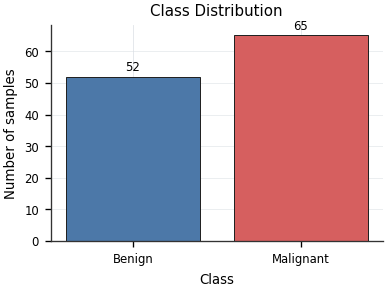


════════════════════════════════════════════════════════════════════════════════
PATIENT SAMPLE COUNT SUMMARY
════════════════════════════════════════════════════════════════════════════════
       samples_per_patient
count            48.000000
mean              2.437500
std               1.999002
min               1.000000
25%               1.000000
50%               2.000000
75%               3.000000
max               8.000000
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig02_samples_per_patient.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig02_samples_per_patient.pdf


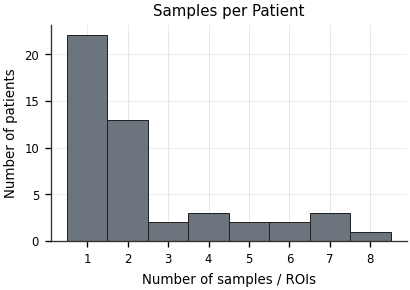

Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig03_feature_variance_distribution.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig03_feature_variance_distribution.pdf


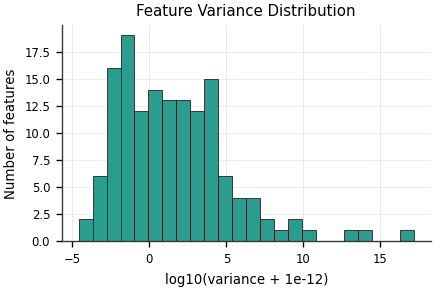


════════════════════════════════════════════════════════════════════════════════
SHAPIRO-WILK NORMALITY SUMMARY
════════════════════════════════════════════════════════════════════════════════
Normal features before FDR:     27
Non-normal features before FDR: 118
Normal features after FDR:      27
Non-normal features after FDR:  118
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig04_feature_normality_summary.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig04_feature_normality_summary.pdf


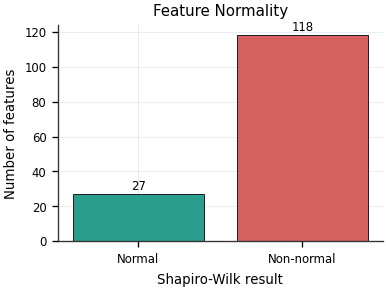


════════════════════════════════════════════════════════════════════════════════
TOP FEATURE-LABEL ASSOCIATIONS AFTER FDR
════════════════════════════════════════════════════════════════════════════════
                                                     feature                correlation_method  correlation_coefficient  correlation_p_value  correlation_q_value_fdr class_difference_test  class_difference_p_value  class_difference_q_value_fdr  cohen_d_malignant_minus_benign
                                             Morph_Compacity                          Spearman                 0.327981             0.000306                 0.007401        Mann_Whitney_U                  0.000416                      0.010053                        0.620920
                                          Morph_Compactness1                          Spearman                -0.327981             0.000306                 0.007401        Mann_Whitney_U                  0.000416                      0.010053 

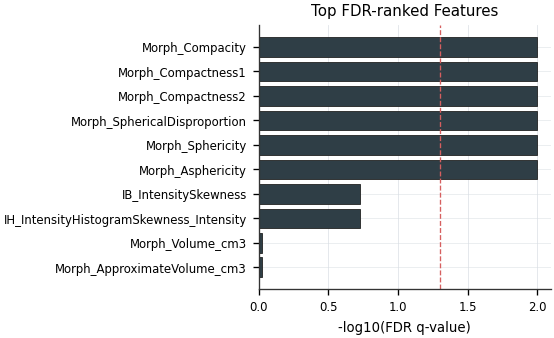

Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig06_top4_feature_boxplots.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig06_top4_feature_boxplots.pdf


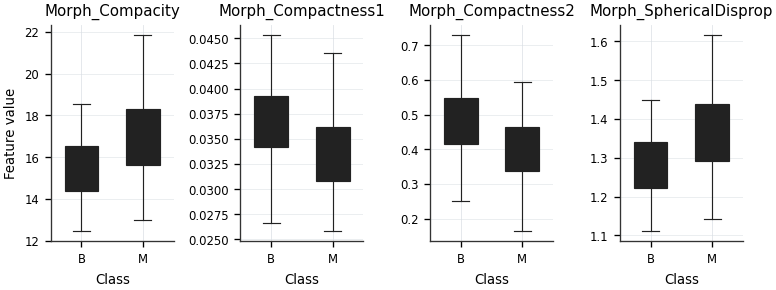

Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig07_top12_feature_correlation_heatmap.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig07_top12_feature_correlation_heatmap.pdf


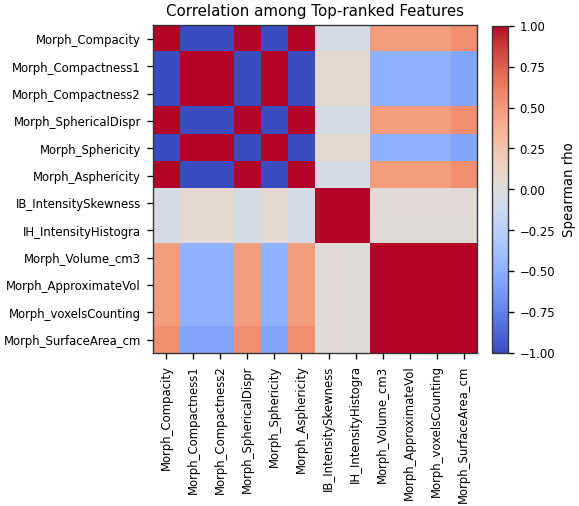

Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig08_pca_projection.png
Saved: ./nested_cv_outputs/step_1b_statistical_eda/plots_publication_style/fig08_pca_projection.pdf


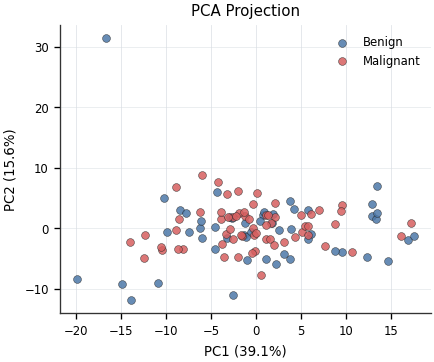


════════════════════════════════════════════════════════════════════════════════
PCA EXPLAINED VARIANCE
════════════════════════════════════════════════════════════════════════════════
component  explained_variance_ratio
      PC1                  0.390735
      PC2                  0.156034

════════════════════════════════════════════════════════════════════════════════
STEP 1B SUMMARY
════════════════════════════════════════════════════════════════════════════════
n_samples: 117
n_features: 145
n_label_0: 52
n_label_1: 65
class_balance_binomial_p_value: 0.26718230499039625
n_normal_features_raw_p_ge_0_05: 27
n_non_normal_features_raw_p_lt_0_05: 118
n_normal_features_fdr_q_ge_0_05: 27
n_non_normal_features_fdr_q_lt_0_05: 118
n_features_with_fdr_significant_class_difference: 6
n_features_with_fdr_significant_correlation: 6
pca_pc1_explained_variance_ratio: 0.39073499049060123
pca_pc2_explained_variance_ratio: 0.15603411796485342
eda_dir: ./nested_cv_outputs/step_1b_statistical_eda
pl

In [155]:
# =============================================================================
# STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE VISUAL EDA
# =============================================================================
# Purpose:
#   - Perform statistical QA after robust data ingestion.
#   - Avoid redundant figures.
#   - Generate compact, publication-style plots suitable for manuscripts.
#   - Save all figures as both high-resolution PNG and vector PDF.
#
# Important:
#   - This cell is EDA only.
#   - It does NOT modify X, y, groups, or feature_names.
#   - PCA here is visualization-only and must not be used for model training
#     outside cross-validation.
# =============================================================================

print("█" * 80)
print("  STEP 1B — COMPACT STATISTICAL QA AND PUBLICATION-STYLE EDA")
print("█" * 80)

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    shapiro,
    pearsonr,
    spearmanr,
    ttest_ind,
    mannwhitneyu,
    binomtest
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Output directories
# -----------------------------------------------------------------------------
eda_dir = os.path.join(CONFIG.get("SAVE_DIR", "./nested_cv_outputs"), "step_1b_statistical_eda")
plot_dir = os.path.join(eda_dir, "plots_publication_style")

os.makedirs(eda_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

print(f"\nEDA output directory:\n  {eda_dir}")
print(f"Plot output directory:\n  {plot_dir}")

# -----------------------------------------------------------------------------
# 2. Publication-style plotting theme
# -----------------------------------------------------------------------------
# Professional, compact, manuscript-oriented theme.
# Labels are kept in English because most journals require English figures.
plt.style.use("default")

FIG_DPI = 600

COLORS = {
    "benign": "#4C78A8",
    "malignant": "#D65F5F",
    "neutral": "#6C757D",
    "accent": "#2A9D8F",
    "dark": "#2F3E46",
    "grid": "#D9DEE3"
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axis(ax):
    """
    Minimal journal-style axis formatting.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", linestyle="-", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


def save_figure(fig, filename_base):
    """
    Save each figure in both PNG and PDF formats.
    """
    png_path = os.path.join(plot_dir, f"{filename_base}.png")
    pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# -----------------------------------------------------------------------------
# 3. Safety checks
# -----------------------------------------------------------------------------
required_objects = ["X", "y", "groups", "feature_names"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(f"Required object '{obj_name}' not found. Run Step 1 first.")

X_eda = np.asarray(X, dtype=float)
y_eda = np.asarray(y, dtype=int)
groups_eda = np.asarray(groups).astype(str)
feature_names_eda = list(feature_names)

if X_eda.shape[1] != len(feature_names_eda):
    raise ValueError("X column count does not match feature_names length.")

# -----------------------------------------------------------------------------
# 4. Helper functions
# -----------------------------------------------------------------------------
def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR correction.
    Returns q-values in original order.
    """
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    q_values = np.full(n, np.nan)
    valid_mask = np.isfinite(p_values)
    valid_p = p_values[valid_mask]

    if len(valid_p) == 0:
        return q_values

    order = np.argsort(valid_p)
    ranked_p = valid_p[order]

    adjusted = ranked_p * len(valid_p) / (np.arange(1, len(valid_p) + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    valid_q = np.empty_like(valid_p)
    valid_q[order] = adjusted

    q_values[valid_mask] = valid_q
    return q_values


def cohen_d(x0, x1):
    """
    Cohen's d: malignant minus benign.
    """
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)

    x0 = x0[np.isfinite(x0)]
    x1 = x1[np.isfinite(x1)]

    n0, n1 = len(x0), len(x1)

    if n0 < 2 or n1 < 2:
        return np.nan

    s0 = np.var(x0, ddof=1)
    s1 = np.var(x1, ddof=1)

    pooled_sd = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))

    if pooled_sd == 0:
        return np.nan

    return (np.mean(x1) - np.mean(x0)) / pooled_sd


def group_shapiro(x):
    """
    Safe Shapiro-Wilk test for one group.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 3 or np.std(x) == 0:
        return np.nan, False

    stat, p = shapiro(x)
    return p, bool(p >= 0.05)


# -----------------------------------------------------------------------------
# 5. Class balance statistical test
# -----------------------------------------------------------------------------
label_counts = pd.Series(y_eda).value_counts().sort_index()

n_label_0 = int(label_counts.get(0, 0))
n_label_1 = int(label_counts.get(1, 0))
n_total = int(n_label_0 + n_label_1)

minority_count = min(n_label_0, n_label_1)

balance_test = binomtest(
    k=minority_count,
    n=n_total,
    p=0.5,
    alternative="two-sided"
)

class_balance_report = pd.DataFrame({
    "label": [0, 1],
    "class_name": ["Benign", "Malignant"],
    "count": [n_label_0, n_label_1],
    "proportion": [n_label_0 / n_total, n_label_1 / n_total],
    "binomial_balance_p_value": [balance_test.pvalue, balance_test.pvalue]
})

class_balance_report.to_csv(
    os.path.join(eda_dir, "class_balance_statistical_test.csv"),
    index=False
)

print("\n" + "═" * 80)
print("CLASS BALANCE STATISTICAL TEST")
print("═" * 80)
print(class_balance_report.to_string(index=False))
print(f"\nExact binomial test p-value: {balance_test.pvalue:.6f}")

# Figure 1: Class distribution only. No pie chart to avoid redundancy.
fig, ax = plt.subplots(figsize=(3.4, 2.6))

ax.bar(
    ["Benign", "Malignant"],
    [n_label_0, n_label_1],
    color=[COLORS["benign"], COLORS["malignant"]],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
clean_axis(ax)

for i, v in enumerate([n_label_0, n_label_1]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
save_figure(fig, "fig01_class_distribution")
plt.show()


# -----------------------------------------------------------------------------
# 6. Patient/group structure
# -----------------------------------------------------------------------------
patient_counts = pd.Series(groups_eda).value_counts()

patient_count_summary = patient_counts.describe().to_frame("samples_per_patient")
patient_count_summary.to_csv(os.path.join(eda_dir, "patient_sample_count_summary.csv"))

print("\n" + "═" * 80)
print("PATIENT SAMPLE COUNT SUMMARY")
print("═" * 80)
print(patient_count_summary.to_string())

# Figure 2: Only one patient-distribution figure.
fig, ax = plt.subplots(figsize=(3.6, 2.6))

bins = np.arange(1, int(patient_counts.max()) + 2) - 0.5

ax.hist(
    patient_counts.values,
    bins=bins,
    color=COLORS["neutral"],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Samples per Patient")
ax.set_xlabel("Number of samples / ROIs")
ax.set_ylabel("Number of patients")
ax.set_xticks(range(1, int(patient_counts.max()) + 1))
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig02_samples_per_patient")
plt.show()


# -----------------------------------------------------------------------------
# 7. Missingness and variance reports
# -----------------------------------------------------------------------------
nan_counts = pd.Series(np.isnan(X_eda).sum(axis=0), index=feature_names_eda)
inf_counts = pd.Series(np.isinf(X_eda).sum(axis=0), index=feature_names_eda)
bad_counts = nan_counts + inf_counts

bad_feature_report = pd.DataFrame({
    "feature": feature_names_eda,
    "nan_count": nan_counts.values,
    "inf_count": inf_counts.values,
    "bad_value_count": bad_counts.values
}).sort_values("bad_value_count", ascending=False)

bad_feature_report.to_csv(
    os.path.join(eda_dir, "feature_missing_inf_report.csv"),
    index=False
)

feature_variance = pd.Series(np.nanvar(X_eda, axis=0), index=feature_names_eda)

variance_report = pd.DataFrame({
    "feature": feature_names_eda,
    "variance": feature_variance.values,
    "log10_variance": np.log10(feature_variance.values + 1e-12)
}).sort_values("variance", ascending=True)

variance_report.to_csv(
    os.path.join(eda_dir, "feature_variance_report.csv"),
    index=False
)

# Figure 3: Feature variance distribution.
fig, ax = plt.subplots(figsize=(3.8, 2.6))

ax.hist(
    variance_report["log10_variance"],
    bins=24,
    color=COLORS["accent"],
    edgecolor="#222222",
    linewidth=0.5
)

ax.set_title("Feature Variance Distribution")
ax.set_xlabel("log10(variance + 1e-12)")
ax.set_ylabel("Number of features")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig03_feature_variance_distribution")
plt.show()


# -----------------------------------------------------------------------------
# 8. Shapiro-Wilk normality test per feature
# -----------------------------------------------------------------------------
normality_rows = []

for j, feat in enumerate(feature_names_eda):
    xj = X_eda[:, j]
    xj = xj[np.isfinite(xj)]

    if len(xj) < 3 or np.nanstd(xj) == 0:
        shapiro_stat = np.nan
        shapiro_p = np.nan
        is_normal = False
    else:
        shapiro_stat, shapiro_p = shapiro(xj)
        is_normal = bool(shapiro_p >= 0.05)

    normality_rows.append({
        "feature": feat,
        "n_valid": int(len(xj)),
        "shapiro_stat": shapiro_stat,
        "shapiro_p_value": shapiro_p,
        "is_normal_global_p_ge_0_05": is_normal
    })

normality_report = pd.DataFrame(normality_rows)

normality_report["shapiro_q_value_fdr"] = benjamini_hochberg(
    normality_report["shapiro_p_value"].values
)

normality_report["is_normal_after_fdr_q_ge_0_05"] = (
    normality_report["shapiro_q_value_fdr"] >= 0.05
)

normality_report.to_csv(
    os.path.join(eda_dir, "shapiro_wilk_normality_report.csv"),
    index=False
)

n_normal_raw = int(normality_report["is_normal_global_p_ge_0_05"].sum())
n_non_normal_raw = int((~normality_report["is_normal_global_p_ge_0_05"]).sum())

n_normal_fdr = int(normality_report["is_normal_after_fdr_q_ge_0_05"].sum())
n_non_normal_fdr = int((~normality_report["is_normal_after_fdr_q_ge_0_05"]).sum())

print("\n" + "═" * 80)
print("SHAPIRO-WILK NORMALITY SUMMARY")
print("═" * 80)
print(f"Normal features before FDR:     {n_normal_raw}")
print(f"Non-normal features before FDR: {n_non_normal_raw}")
print(f"Normal features after FDR:      {n_normal_fdr}")
print(f"Non-normal features after FDR:  {n_non_normal_fdr}")

# Figure 4: Normal vs non-normal summary only.
fig, ax = plt.subplots(figsize=(3.4, 2.6))

ax.bar(
    ["Normal", "Non-normal"],
    [n_normal_raw, n_non_normal_raw],
    color=[COLORS["accent"], COLORS["malignant"]],
    edgecolor="#222222",
    linewidth=0.6
)

ax.set_title("Feature Normality")
ax.set_xlabel("Shapiro-Wilk result")
ax.set_ylabel("Number of features")
clean_axis(ax)

for i, v in enumerate([n_normal_raw, n_non_normal_raw]):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
save_figure(fig, "fig04_feature_normality_summary")
plt.show()


# -----------------------------------------------------------------------------
# 9. Feature-label association:
#    Pearson if both class-specific distributions are normal,
#    Spearman if at least one class-specific distribution is non-normal.
# -----------------------------------------------------------------------------
association_rows = []

for j, feat in enumerate(feature_names_eda):
    xj = X_eda[:, j]

    finite_mask = np.isfinite(xj) & np.isfinite(y_eda)
    xj_valid = xj[finite_mask]
    y_valid = y_eda[finite_mask]

    x0 = xj_valid[y_valid == 0]
    x1 = xj_valid[y_valid == 1]

    shapiro_p_0, normal_0 = group_shapiro(x0)
    shapiro_p_1, normal_1 = group_shapiro(x1)

    use_parametric = bool(normal_0 and normal_1)

    # Correlation with binary label
    if len(np.unique(xj_valid)) < 2 or len(np.unique(y_valid)) < 2:
        corr_method = "undefined"
        corr_coef = np.nan
        corr_p = np.nan
    else:
        if use_parametric:
            corr_method = "Pearson_point_biserial_equivalent"
            corr_coef, corr_p = pearsonr(xj_valid, y_valid)
        else:
            corr_method = "Spearman"
            corr_coef, corr_p = spearmanr(xj_valid, y_valid)

    # Class difference test
    if len(x0) < 2 or len(x1) < 2:
        class_test = "undefined"
        class_test_stat = np.nan
        class_test_p = np.nan
    else:
        if use_parametric:
            class_test = "Welch_t_test"
            class_test_stat, class_test_p = ttest_ind(
                x0,
                x1,
                equal_var=False,
                nan_policy="omit"
            )
        else:
            class_test = "Mann_Whitney_U"
            try:
                class_test_stat, class_test_p = mannwhitneyu(
                    x0,
                    x1,
                    alternative="two-sided"
                )
            except ValueError:
                class_test_stat, class_test_p = np.nan, np.nan

    association_rows.append({
        "feature": feat,
        "n_valid": int(len(xj_valid)),
        "mean_benign": np.nanmean(x0) if len(x0) else np.nan,
        "mean_malignant": np.nanmean(x1) if len(x1) else np.nan,
        "median_benign": np.nanmedian(x0) if len(x0) else np.nan,
        "median_malignant": np.nanmedian(x1) if len(x1) else np.nan,
        "shapiro_p_benign": shapiro_p_0,
        "shapiro_p_malignant": shapiro_p_1,
        "normal_in_both_classes": use_parametric,
        "correlation_method": corr_method,
        "correlation_coefficient": corr_coef,
        "correlation_p_value": corr_p,
        "class_difference_test": class_test,
        "class_difference_stat": class_test_stat,
        "class_difference_p_value": class_test_p,
        "cohen_d_malignant_minus_benign": cohen_d(x0, x1)
    })

association_report = pd.DataFrame(association_rows)

association_report["correlation_q_value_fdr"] = benjamini_hochberg(
    association_report["correlation_p_value"].values
)

association_report["class_difference_q_value_fdr"] = benjamini_hochberg(
    association_report["class_difference_p_value"].values
)

association_report = association_report.sort_values(
    ["class_difference_q_value_fdr", "correlation_q_value_fdr"],
    ascending=[True, True]
)

association_report.to_csv(
    os.path.join(eda_dir, "feature_label_association_report.csv"),
    index=False
)

print("\n" + "═" * 80)
print("TOP FEATURE-LABEL ASSOCIATIONS AFTER FDR")
print("═" * 80)

display_cols = [
    "feature",
    "correlation_method",
    "correlation_coefficient",
    "correlation_p_value",
    "correlation_q_value_fdr",
    "class_difference_test",
    "class_difference_p_value",
    "class_difference_q_value_fdr",
    "cohen_d_malignant_minus_benign"
]

print(association_report[display_cols].head(15).to_string(index=False))


# -----------------------------------------------------------------------------
# 10. Figure 5: Top FDR-ranked features
# -----------------------------------------------------------------------------
assoc_plot_df = association_report.copy()

safe_q = assoc_plot_df["class_difference_q_value_fdr"].copy()
safe_q = safe_q.replace(0, np.nextafter(0, 1))
assoc_plot_df["minus_log10_q"] = -np.log10(safe_q)

assoc_plot_df = assoc_plot_df.replace([np.inf, -np.inf], np.nan)
assoc_plot_df = assoc_plot_df.dropna(subset=["minus_log10_q"])

top_assoc = assoc_plot_df.head(10).iloc[::-1]

if len(top_assoc) > 0:
    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    ax.barh(
        top_assoc["feature"],
        top_assoc["minus_log10_q"],
        color=COLORS["dark"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(
        -np.log10(0.05),
        linestyle="--",
        linewidth=0.8,
        color=COLORS["malignant"]
    )

    ax.set_title("Top FDR-ranked Features")
    ax.set_xlabel("-log10(FDR q-value)")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig05_top_fdr_ranked_features")
    plt.show()


# -----------------------------------------------------------------------------
# 11. Figure 6: Compact boxplots for top 4 FDR-ranked features
# -----------------------------------------------------------------------------
top_box_features = association_report["feature"].head(4).tolist()

if len(top_box_features) > 0:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(top_box_features),
        figsize=(min(6.4, 1.6 * len(top_box_features)), 2.6),
        sharey=False
    )

    if len(top_box_features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_box_features):
        j = feature_names_eda.index(feat)
        xj = X_eda[:, j]

        x0 = xj[y_eda == 0]
        x1 = xj[y_eda == 1]

        bp = ax.boxplot(
            [x0[np.isfinite(x0)], x1[np.isfinite(x1)]],
            labels=["B", "M"],
            patch_artist=True,
            showfliers=False,
            widths=0.55
        )

        bp["boxes"][0].set_facecolor(COLORS["benign"])
        bp["boxes"][1].set_facecolor(COLORS["malignant"])

        for element in ["boxes", "whiskers", "caps", "medians"]:
            for item in bp[element]:
                item.set_color("#222222")
                item.set_linewidth(0.7)

        ax.set_title(feat[:22])
        ax.set_xlabel("Class")
        ax.tick_params(axis="x", rotation=0)
        clean_axis(ax)

    axes[0].set_ylabel("Feature value")

    plt.tight_layout()
    save_figure(fig, "fig06_top4_feature_boxplots")
    plt.show()


# -----------------------------------------------------------------------------
# 12. Figure 7: Spearman correlation heatmap among top 12 FDR-ranked features
# -----------------------------------------------------------------------------
top_heatmap_features = association_report["feature"].head(12).tolist()

if len(top_heatmap_features) >= 2:
    top_indices = [feature_names_eda.index(f) for f in top_heatmap_features]

    X_top = pd.DataFrame(
        X_eda[:, top_indices],
        columns=top_heatmap_features
    )

    corr_matrix = X_top.corr(method="spearman")

    corr_matrix.to_csv(
        os.path.join(eda_dir, "top12_features_spearman_correlation_matrix.csv")
    )

    fig, ax = plt.subplots(figsize=(5.0, 4.4))

    im = ax.imshow(
        corr_matrix,
        aspect="auto",
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman rho")

    short_labels = [f[:20] for f in top_heatmap_features]

    ax.set_xticks(np.arange(len(short_labels)))
    ax.set_yticks(np.arange(len(short_labels)))
    ax.set_xticklabels(short_labels, rotation=90)
    ax.set_yticklabels(short_labels)

    ax.set_title("Correlation among Top-ranked Features")
    ax.grid(False)

    plt.tight_layout()
    save_figure(fig, "fig07_top12_feature_correlation_heatmap")
    plt.show()


# -----------------------------------------------------------------------------
# 13. Figure 8: PCA projection
# -----------------------------------------------------------------------------
# EDA-only global transformation.
# Do not use these PCA components for model training outside CV.
imputer_eda = SimpleImputer(strategy="median")
scaler_eda = StandardScaler()

X_imp = imputer_eda.fit_transform(X_eda)
X_scaled = scaler_eda.fit_transform(X_imp)

pca = PCA(n_components=2, random_state=CONFIG.get("RANDOM_STATE", 42))
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Label": y_eda,
    "Patient_ID": groups_eda
})

pca_df.to_csv(os.path.join(eda_dir, "pca_2d_coordinates.csv"), index=False)

pca_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

pca_variance_df.to_csv(
    os.path.join(eda_dir, "pca_2d_explained_variance.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(3.8, 3.2))

for cls, label_name, color in [
    (0, "Benign", COLORS["benign"]),
    (1, "Malignant", COLORS["malignant"])
]:
    idx = y_eda == cls
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=label_name,
        s=22,
        alpha=0.85,
        color=color,
        edgecolor="#222222",
        linewidth=0.3
    )

ax.set_title("PCA Projection")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(frameon=False, loc="best")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig08_pca_projection")
plt.show()

print("\n" + "═" * 80)
print("PCA EXPLAINED VARIANCE")
print("═" * 80)
print(pca_variance_df.to_string(index=False))


# -----------------------------------------------------------------------------
# 14. Compact JSON summary for future comparison
# -----------------------------------------------------------------------------
step_1b_summary = {
    "n_samples": int(X_eda.shape[0]),
    "n_features": int(X_eda.shape[1]),
    "n_label_0": int(n_label_0),
    "n_label_1": int(n_label_1),
    "class_balance_binomial_p_value": float(balance_test.pvalue),
    "n_normal_features_raw_p_ge_0_05": int(n_normal_raw),
    "n_non_normal_features_raw_p_lt_0_05": int(n_non_normal_raw),
    "n_normal_features_fdr_q_ge_0_05": int(n_normal_fdr),
    "n_non_normal_features_fdr_q_lt_0_05": int(n_non_normal_fdr),
    "n_features_with_fdr_significant_class_difference": int(
        (association_report["class_difference_q_value_fdr"] < 0.05).sum()
    ),
    "n_features_with_fdr_significant_correlation": int(
        (association_report["correlation_q_value_fdr"] < 0.05).sum()
    ),
    "pca_pc1_explained_variance_ratio": float(pca.explained_variance_ratio_[0]),
    "pca_pc2_explained_variance_ratio": float(pca.explained_variance_ratio_[1]),
    "eda_dir": eda_dir,
    "plot_dir": plot_dir
}

with open(os.path.join(eda_dir, "step_1b_summary.json"), "w") as f:
    json.dump(step_1b_summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 1B SUMMARY")
print("═" * 80)

for k, v in step_1b_summary.items():
    print(f"{k}: {v}")

print("\nSaved statistical reports and publication-style plots to:")
print(f"  {eda_dir}")
print(f"  {plot_dir}")

print("\n✅ STEP 1B completed successfully.")

In [156]:
# =============================================================================
# STEP 2A — BASELINE RUN CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Define a clean baseline before testing SMOTE, alternative feature selection,
#     dimensionality reduction, and explainability modules.
#   - Keep this baseline reproducible and separately saved.
# =============================================================================

print("█" * 80)
print("  STEP 2A — BASELINE CONFIGURATION LOCK")
print("█" * 80)

import os
import json

# -----------------------------------------------------------------------------
# Baseline identity
# -----------------------------------------------------------------------------
CONFIG["RUN_NAME"] = "step_2_baseline_nested_cv_no_smote"
CONFIG["SAVE_DIR"] = os.path.join(
    "./nested_cv_outputs",
    CONFIG["RUN_NAME"]
)

os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# -----------------------------------------------------------------------------
# Core baseline settings
# -----------------------------------------------------------------------------
# CONFIG["USE_SMOTE"] = False

# Keep current notebook feature selection strategy as baseline.
# This should match the method already used in your current pipeline.
CONFIG["FS_METHOD"] = CONFIG.get("FS_METHOD")
CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

# Patient-aware nested CV
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

# -----------------------------------------------------------------------------
# Safety checks
# -----------------------------------------------------------------------------
if "groups" not in globals():
    raise RuntimeError("groups object not found. Run Step 1 first.")

if len(set(groups)) < CONFIG["N_OUTER_FOLDS"]:
    raise ValueError(
        f"Unique patients/groups = {len(set(groups))}, "
        f"but N_OUTER_FOLDS = {CONFIG['N_OUTER_FOLDS']}."
    )

baseline_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups)))
}

with open(os.path.join(CONFIG["SAVE_DIR"], "baseline_config_snapshot.json"), "w") as f:
    json.dump(baseline_config_snapshot, f, indent=4)

print("\nBaseline configuration:")
for k, v in baseline_config_snapshot.items():
    print(f"  {k}: {v}")

print("\n✅ STEP 2A completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 2A — BASELINE CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████

Baseline configuration:
  RUN_NAME: step_2_baseline_nested_cv_no_smote
  SAVE_DIR: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote
  USE_SMOTE: False
  FS_METHOD: boruta_like
  FS_N_FEATURES: 16
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 20
  RANDOM_STATE: 100
  N_SAMPLES: 117
  N_FEATURES: 145
  N_PATIENTS: 48

✅ STEP 2A completed successfully.


In [157]:
# =============================================================================
# MULTI-STAGE FEATURE SELECTION ENGINE (STAGE 1 TO STAGE 4)
# =============================================================================
# Purpose:
#   - Stage 1: Eliminate morphological volume confounders using Spearman rho.
#   - Stage 2: Prune redundant features based on Pearson r and AUC rankings.
#   - Stage 3: Perform Block-wise mRMR selection separately on CT and PET blocks.
#   - Stage 4: Enforce stability selection via subsampled ElasticNet LogReg.
# =============================================================================

import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

# -----------------------------------------------------------------------------
# STAGE 1: MORPHOLOGICAL VOLUME INDEPENDENCE FILTER
# -----------------------------------------------------------------------------
def stage1_volume_independence(X_train, feat_names, volume_col, threshold,
                               category_patterns, all_feature_names_original,
                               X_train_original):
    print("\n" + "═" * 75)
    print("  📐 Stage 1: Volume Independence Filter")
    print(f"     Threshold: |ρ_Spearman| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)

    # Morphology flag (for reporting only, NOT for automatic removal)
    morph_keywords = category_patterns.get('MORPHOLOGY', [])
    morph_flag = {}
    for fn in feat_names:
        fn_lower = fn.lower()
        is_morph = any(kw.lower() in fn_lower for kw in morph_keywords)
        is_morph = is_morph or any(tag in fn_lower
                                    for tag in ['morphological', '_morph_', '_shape_'])
        morph_flag[fn] = is_morph

    # Find volume vector
    vol_vector = None
    vol_source = "NOT FOUND"

    # Try 1: from original feature matrix
    if all_feature_names_original is not None and volume_col in all_feature_names_original:
        vol_idx = all_feature_names_original.index(volume_col)
        vol_vector = X_train_original[:, vol_idx]
        vol_source = volume_col

    # Try 2: fallback search in original
    if vol_vector is None and all_feature_names_original is not None:
        for i_col, fn_col in enumerate(all_feature_names_original):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):
                vol_vector = X_train_original[:, i_col]
                vol_source = fn_col
                break

    # Try 3: from current features
    if vol_vector is None:
        for i_col, fn_col in enumerate(feat_names):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):              
                vol_vector = X_train[:, i_col]
                vol_source = fn_col
                break

    print(f"   📦 Volume column: {vol_source}")

    vol_corr_mask = np.zeros(n_input, dtype=bool)
    vol_details = {}

    if vol_vector is not None:
        print(f"\n  {'Feature':<55} {'|ρ|':>6}  {'Status':<10}  {'Morph?':>6}")
        print("  " + "─" * 85)

        for j in range(n_input):
            fn = feat_names[j]
            try:
                rho, _ = spearmanr(X_train[:, j], vol_vector)
                abs_rho = abs(rho) if np.isfinite(rho) else 0.0
            except Exception:
                abs_rho = 0.0

            vol_details[fn] = abs_rho

            if abs_rho > threshold:
                vol_corr_mask[j] = True
                print(f"     ❌ {fn[:53]:53s} {abs_rho:6.3f}  REMOVED   "
                      f"{str(morph_flag[fn]):>6}")
            elif abs_rho > threshold * 0.7:
                print(f"     ⚠️ {fn[:53]:53s} {abs_rho:6.3f}  kept      "
                      f"{str(morph_flag[fn]):>6}")
    else:
        print("  ⚠️ Volume column NOT FOUND — skipping this stage")

    keep_idx = np.where(~vol_corr_mask)[0]

    print(f"\n  📊 Summary: {n_input} → {len(keep_idx)} "
          f"(removed {int(vol_corr_mask.sum())} volume-dependent)")

    info = {
        'n_input': n_input,
        'n_output': len(keep_idx),
        'n_vol_dep_removed': int(vol_corr_mask.sum()),
        'vol_corr_details': vol_details,
        'removed_features': [feat_names[i] for i in np.where(vol_corr_mask)[0]],
        'kept_features': [feat_names[i] for i in keep_idx],
        'morph_flag': morph_flag,
    }
    return keep_idx, info


# -----------------------------------------------------------------------------
# STAGE 2: REDUNDANCY REDUCTION (PEARSON PAIR-WISE CLUSTERING)
# -----------------------------------------------------------------------------
def stage2_redundancy_reduction(X_train, y_train, feat_names, threshold=0.90):
    print("\n" + "═" * 75)
    print("  🔗 Stage 2: Redundancy Reduction (Pearson |r| clustering)")
    print(f"     Threshold: |r| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)
    corr_matrix = np.nan_to_num(
        np.corrcoef(X_train, rowvar=False),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )
    auc_scores = np.zeros(n_input)
    for j in range(n_input):
        try:
            if np.std(X_train[:, j]) < 1e-12:
                auc_scores[j] = 0.5
            else:
                auc = roc_auc_score(y_train, X_train[:, j])
                auc_scores[j] = max(auc, 1 - auc)
        except Exception:
            auc_scores[j] = 0.5

    remaining = set(range(n_input))
    selected_idx = []
    removal_reasons = {}

    for idx in np.argsort(-auc_scores):
        if idx not in remaining:
            continue
        selected_idx.append(idx)
        remaining.discard(idx)

        to_remove = set()
        for other in remaining:
            if abs(corr_matrix[idx, other]) > threshold:
                to_remove.add(other)
                removal_reasons[other] = (idx, corr_matrix[idx, other])
        remaining -= to_remove

    selected_idx = sorted(selected_idx)
    removed_features = [i for i in range(n_input) if i not in selected_idx]

    print(f"\n  📋 All features ranked by AUC:")
    print(f"  {'#':<4} {'Feature':<55} {'AUC':<8} {'Status':<10}")
    print("  " + "─" * 80)
    for rank, idx in enumerate(np.argsort(-auc_scores), 1):
        status = "✅ KEPT" if idx in selected_idx else "❌ REMOVED"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{auc_scores[idx]:.4f}  {status}")

    if removed_features:
        print(f"\n  ❌ REMOVED {len(removed_features)} features (beaten by correlated feature):")
        print(f"  {'#':<4} {'Removed':<42} {'AUC':<8} {'Beaten By':<32} {'|r|':<8}")
        print("  " + "─" * 95)
        for rank, idx in enumerate(removed_features, 1):
            if idx in removal_reasons:
                w_idx, corr_val = removal_reasons[idx]
                print(f"  {rank:<4} {feat_names[idx][:40]:<42} "
                      f"{auc_scores[idx]:.4f}  "
                      f"{feat_names[w_idx][:30]:<32} {abs(corr_val):.4f}")

    print(f"\n  ✅ KEPT {len(selected_idx)} features:")
    for rank, idx in enumerate(selected_idx, 1):
        print(f"     {rank}. {feat_names[idx][:55]} (AUC: {auc_scores[idx]:.4f})")

    print(f"\n  📊 Summary: {n_input} → {len(selected_idx)}")

    info = {
        'n_input': n_input,
        'n_output': len(selected_idx),
        'threshold': threshold,
        'removed_features': [(feat_names[i], float(auc_scores[i]),
                              feat_names[removal_reasons[i][0]] if i in removal_reasons else "N/A",
                              float(abs(removal_reasons[i][1])) if i in removal_reasons else 0)
                             for i in removed_features],
        'kept_features': [feat_names[i] for i in selected_idx],
        'auc_scores': dict(zip(feat_names, auc_scores.tolist())),
    }
    return np.array(selected_idx), auc_scores, info


# -----------------------------------------------------------------------------
# STAGE 3: BLOCK-WISE mRMR (MODALITY SPECIFIC DISCRIMINATION)
# -----------------------------------------------------------------------------


def stage3_mrmr_selection_blockwise(X_train, y_train, feat_names, n_features=14):
    print("\n" + "═" * 75)
    print("  🧠 Stage 3: mRMR Selection (Single Modality)")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 3 mRMR requires at least two classes in y_train.")

    n_features = min(n_features, X_train.shape[1])
    class_counts = np.bincount(y_train.astype(int))
    min_class_count = class_counts[class_counts > 0].min()
    safe_neighbors = max(1, min(3, min_class_count - 1))

    relevance = mutual_info_classif(
        X_train,
        y_train,
        random_state=42,
        n_neighbors=safe_neighbors
    )

    corr_mat = np.nan_to_num(np.corrcoef(X_train, rowvar=False))

    selected = []
    remaining = list(range(X_train.shape[1]))

    for k in range(n_features):
        best_score = -np.inf
        best_idx = None

        for idx in remaining:
            rel = relevance[idx]
            if len(selected) == 0:
                red = 0
            else:
                red = np.mean([abs(corr_mat[idx, s]) for s in selected])

            score = rel - red

            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

        print(f"   {k+1}. {feat_names[best_idx]:<40} score={best_score:.4f}")

    return selected, relevance, {"kept_features": [feat_names[i] for i in selected]}


# -----------------------------------------------------------------------------
# STAGE 4: RESAMPLED STABILITY SELECTION (ELASTIC-NET LOGISTIC REGRESSION)
# -----------------------------------------------------------------------------
def stage4_stability_selection(X_train, y_train, feat_names,
                               n_iterations=300, subsample_ratio=0.5,
                               sel_threshold=0.75, l1_ratios=None,
                               Cs=None, random_state=42,
                               coef_threshold=1e-3,
                               fallback_step=0.05,       
                               fallback_min_threshold=0.40,  
                               fallback_min_features=3):     

    print("\n" + "═" * 75)
    print("  🎯 Stage 4: Stability Selection (ElasticNet LogReg)")
    print(f"     Iterations: {n_iterations} | Subsample: {subsample_ratio}")
    print(f"     Selection threshold: {sel_threshold}")
    print(f"     Coefficient threshold: {coef_threshold}")
    print(f"     Fallback: step={fallback_step}, "
          f"min_thresh={fallback_min_threshold}, "
          f"min_features={fallback_min_features}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 4 stability selection requires at least two classes in y_train.")

    if l1_ratios is None:
        l1_ratios = [0.8, 0.9, 0.95, 1.0]
    if Cs is None:
        Cs = [0.005, 0.01, 0.05, 0.1]

    n_features = len(feat_names)
    n_samples = X_train.shape[0]
    n_sub = max(int(n_samples * subsample_ratio), 10)

    # Scale once
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    selection_count = np.zeros(n_features)
    coef_accumulator = np.zeros(n_features)
    rng = np.random.RandomState(random_state)

    successful = 0
    failed = 0

    for it in range(n_iterations):
        # Random subsample (stratified)
        idx_0 = np.where(y_train == 0)[0]
        idx_1 = np.where(y_train == 1)[0]

        n_sub_0 = max(int(len(idx_0) * subsample_ratio), 2)
        n_sub_1 = max(int(len(idx_1) * subsample_ratio), 2)

        if len(idx_0) > 0:
            sub_0 = rng.choice(idx_0, size=min(n_sub_0, len(idx_0)), replace=False)
        else:
            sub_0 = np.array([], dtype=int)
        if len(idx_1) > 0:
            sub_1 = rng.choice(idx_1, size=min(n_sub_1, len(idx_1)), replace=False)
        else:
            sub_1 = np.array([], dtype=int)
        sub_idx = np.concatenate([sub_0, sub_1])

        X_sub = X_scaled[sub_idx]
        y_sub = y_train[sub_idx]

        # Random hyperparameters
        l1_ratio = rng.choice(l1_ratios)
        C = rng.choice(Cs)

        try:
            model = LogisticRegression(
                penalty='elasticnet', solver='saga',
                C=C, l1_ratio=l1_ratio,
                max_iter=5000,
                random_state=random_state + it,
                tol=1e-5
            )
            model.fit(X_sub, y_sub)

            coefs = np.abs(model.coef_[0])
            selected_mask = np.abs(coefs) > coef_threshold
            selection_count += selected_mask.astype(float)
            coef_accumulator += coefs
            successful += 1

        except Exception:
            failed += 1

        # Progress tracking updates
        if (it + 1) % 100 == 0:
            current_freq = selection_count / max(successful, 1)
            n_passing = np.sum(current_freq >= sel_threshold)
            print(f"    ... iteration {it + 1}/{n_iterations} "
                  f"(success: {successful}, failed: {failed}, "
                  f"passing: {n_passing} features)")

    # Compute operational frequencies
    if successful > 0:
        selection_freq = selection_count / successful
        mean_coefs = coef_accumulator / successful
    else:
        selection_freq = np.zeros(n_features)
        mean_coefs = np.zeros(n_features)

    # ══════════════════════════════════════════════════════════
    # ADAPTIVE FALLBACK PROTOCOL: GRADUAL THRESHOLD DECAY
    # ══════════════════════════════════════════════════════════
    current_threshold = sel_threshold
    keep_idx = np.where(selection_freq >= current_threshold)[0]

    # Dynamically decay selection criterion if total retained features falls below safety boundaries
    if len(keep_idx) < fallback_min_features:
        print(f"\n  ⚠️  Only {len(keep_idx)} features at threshold "
              f"{current_threshold:.2f} (need ≥{fallback_min_features})")
        print(f"  🔄 Starting adaptive threshold reduction...")

        while (len(keep_idx) < fallback_min_features and
               current_threshold > fallback_min_threshold):

            current_threshold -= fallback_step
            current_threshold = round(current_threshold, 4)  # Safeguard floating-point precision bounds
            keep_idx = np.where(selection_freq >= current_threshold)[0]

            print(f"      → threshold = {current_threshold:.2f} "
                  f"→ {len(keep_idx)} features selected")

        # Absolute fallback override if minimal conditions remain unsatisfied
        if len(keep_idx) < fallback_min_features:
            print(f"\n  🚨 Still only {len(keep_idx)} features at "
                  f"minimum threshold {fallback_min_threshold:.2f}")
            print(f"  🔄 Selecting top {fallback_min_features} by frequency...")
            keep_idx = np.argsort(-selection_freq)[:fallback_min_features]
            if len(keep_idx) > 0:
                current_threshold = selection_freq[keep_idx[-1]]
            else:
                current_threshold = fallback_min_threshold
            print(f"      → Effective threshold: {current_threshold:.3f}")

        if current_threshold < sel_threshold:
            print(f"\n  📌 Final threshold: {current_threshold:.2f} "
                  f"(original: {sel_threshold:.2f})")

    # --- Verbose Output Generation -------------------------------------------
    print(f"\n  📋 Feature selection frequencies "
          f"(threshold used: {current_threshold:.2f}):")
    print(f"  {'#':<4} {'Feature':<55} {'Freq':<8} "
          f"{'MeanCoef':<10} {'Status':<10}")
    print("  " + "─" * 90)

    for rank, idx in enumerate(np.argsort(-selection_freq), 1):
        status = "✅ KEPT" if selection_freq[idx] >= current_threshold else "❌"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{selection_freq[idx]:.3f}  {mean_coefs[idx]:.6f}  {status}")

    print(f"\n  📊 Summary: {n_features} → {len(keep_idx)} "
          f"(removed {n_features - len(keep_idx)})")
    print(f"     Successful iterations: {successful}/{n_iterations}")
    if current_threshold < sel_threshold:
        print(f"     ⚠️  Threshold was reduced: "
              f"{sel_threshold:.2f} → {current_threshold:.2f}")

    info = {
        'n_input': n_features,
        'n_output': len(keep_idx),
        'n_iterations_success': successful,
        'n_iterations_failed': failed,
        'original_threshold': sel_threshold,
        'final_threshold': current_threshold,
        'threshold_was_reduced': current_threshold < sel_threshold,
        'selection_frequencies': dict(zip(feat_names, selection_freq.tolist())),
        'mean_coefficients': dict(zip(feat_names, mean_coefs.tolist())),
        'kept_features': [feat_names[i] for i in keep_idx],
    }
    return keep_idx, selection_freq, info



# -----------------------------------------------------------------------------
# ALTERNATIVE FS: CORRELATION FILTER + ELASTICNET SELECTION
# -----------------------------------------------------------------------------
def stage_elasticnet_selection(X_train, y_train, feat_names,
                               n_features=12,
                               l1_ratio=0.8,
                               C=0.1,
                               random_state=100):
    print("\n" + "═" * 75)
    print("  🧬 Alternative FS: ElasticNet Logistic Selection")
    print(f"     Target features: {n_features}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("ElasticNet selection requires at least two classes in y_train.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=C,
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=random_state,
        class_weight='balanced',
        tol=1e-5
    )

    model.fit(X_scaled, y_train)

    coef_abs = np.abs(model.coef_[0])

    if np.all(coef_abs == 0):
        keep_idx = np.argsort(-coef_abs)[:min(n_features, X_train.shape[1])]
    else:
        keep_idx = np.argsort(-coef_abs)[:min(n_features, X_train.shape[1])]

    keep_idx = np.array(sorted(keep_idx))

    print(f"  📊 Summary: {X_train.shape[1]} → {len(keep_idx)}")
    print("  ✅ Selected features:")
    for i, idx in enumerate(keep_idx, 1):
        print(f"     {i}. {feat_names[idx]} | coef_abs={coef_abs[idx]:.6f}")

    info = {
        "n_input": X_train.shape[1],
        "n_output": len(keep_idx),
        "kept_features": [feat_names[i] for i in keep_idx],
        "coef_abs": dict(zip(feat_names, coef_abs.tolist()))
    }

    return keep_idx, coef_abs, info

    
# -----------------------------------------------------------------------------
# PIPELINE STEP DEFINITION VERIFICATION
# -----------------------------------------------------------------------------
print(f"\n  ✅ All 4 feature selection functions defined:")
print(f"     1. stage1_volume_independence()")
print(f"     2. stage2_redundancy_reduction()")
print(f"     3. stage3_mrmr_selection_blockwise()")
print(f"     4. stage4_stability_selection()")
if 'X' in globals() and 'feature_names' in globals():
    print(f"\n  📊 Current data: X.shape = {X.shape}, features = {len(feature_names)}")


  ✅ All 4 feature selection functions defined:
     1. stage1_volume_independence()
     2. stage2_redundancy_reduction()
     3. stage3_mrmr_selection_blockwise()
     4. stage4_stability_selection()

  📊 Current data: X.shape = (117, 145), features = 145


In [158]:
# =============================================================================
# MODEL ARCHITECTURE POOL AND BASE ESTIMATOR TEMPLATES
# =============================================================================
# Purpose:
#   - Define a comprehensive dictionary of core base estimators across multiple
#     algorithmic paradigms (Linear, Kernel, Ensembles, Distance, Probabilistic).
#   - Conditionally compile advanced gradient boosting estimators based on 
#     detected environment runtime extensions.
#   - Establish standard configurations for data balance mitigation via class weights.
# =============================================================================
from sklearn.pipeline import Pipeline


print("█" * 80)
print("  🤖 CELL 3.5: MODEL DEFINITIONS")
print("█" * 80)

RANDOM_STATE = CONFIG['RANDOM_STATE']

# --- Core Model Pool Construction --------------------------------------------
NESTED_CV_MODELS = {
    # --- Parametric & Linear Estimators --------------------------------------
    'LogisticRegression': LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        tol=1e-4,
        n_jobs=1,
    ),
    

    # --- Structural Maximum Margin Kernels (SVM) -----------------------------

    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),

    # --- Tree-Based Resampling Ensembles ------------------------------------
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_depth=None,  
        max_leaf_nodes=3  
    ),

    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=1,
    ),
    # Note: AdaBoost classifier has been systematically excluded from this array

    # --- Non-Parametric & Instance/Distance Estimators -----------------------
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=1))
    ]),

    # --- Generative & Probabilistic Estimators -------------------------------
    'NaiveBayes': GaussianNB(),
}

# --- Conditional Compilations (Advanced Tree Frameworks) ---------------------
# Dynamic ingestion of external execution frames if pre-validated in local space
if HAS_XGB:
    NESTED_CV_MODELS['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=1,
    )
    print("  ✅ XGBoost added to model pool")

if HAS_LGBM:
    NESTED_CV_MODELS['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=1,
        class_weight='balanced',
    )
    print("  ✅ LightGBM added to model pool")

# --- Pool Verification and Meta-Manifest Compilation -------------------------
print(f"\n  📦 Total models defined: {len(NESTED_CV_MODELS)}")
print(f"  {'─' * 50}")
for i, (name, model) in enumerate(NESTED_CV_MODELS.items(), 1):
    model_class = type(model).__name__
    print(f"  {i:>2}. {name:<25} → {model_class}")

print(f"\n  💡 Note: These are BASE templates.")
if HAS_OPTUNA:
    print(f"     Optuna will tune hyperparameters in the inner CV loop")
    print(f"     ({CONFIG['N_OPTUNA_TRIALS']} trials per model per outer fold)")
else:
    print(f"     ⚠️ Optuna NOT available — using default hyperparameters")

print(f"\n{'█' * 80}")

████████████████████████████████████████████████████████████████████████████████
  🤖 CELL 3.5: MODEL DEFINITIONS
████████████████████████████████████████████████████████████████████████████████
  ✅ XGBoost added to model pool
  ✅ LightGBM added to model pool

  📦 Total models defined: 10
  ──────────────────────────────────────────────────
   1. LogisticRegression        → LogisticRegression
   2. SVM_RBF                   → Pipeline
   3. SVM_Linear                → Pipeline
   4. RandomForest              → RandomForestClassifier
   5. GradientBoosting          → GradientBoostingClassifier
   6. ExtraTrees                → ExtraTreesClassifier
   7. KNN                       → Pipeline
   8. NaiveBayes                → GaussianNB
   9. XGBoost                   → XGBClassifier
  10. LightGBM                  → LGBMClassifier

  💡 Note: These are BASE templates.
     Optuna will tune hyperparameters in the inner CV loop
     (20 trials per model per outer fold)

██████████████████████

In [159]:
# =============================================================================
# LASSO FEATURE SELECTION UTILITIES
# =============================================================================

from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_lasso(X_train, y_train):
    """
    Computes absolute univariate discriminative ability using max(AUC, 1-AUC).
    Used only as fallback if LASSO selects zero features.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_lasso_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    Cs=None,
    coef_threshold=1e-6,
    random_state=100
):
    """
    LASSO logistic-regression feature selection.

    Notes:
    - Scaling is done internally because LASSO coefficients are scale-sensitive.
    - This function is called only inside each outer train fold.
    - It returns selected column indices relative to the input X_train.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    if Cs is None:
        Cs = np.logspace(-3, 1, 10)

    n_features = int(min(n_features, X_train.shape[1]))

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_safe)

    class_counts = Counter(y_train)
    min_class_count = min(class_counts.values()) if len(class_counts) == 2 else 0
    cv_splits = min(3, min_class_count)

    print("\n  ─────────────────────────────────────────────")
    print("  LASSO feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  Class distribution: {dict(class_counts)}")
    print("  ─────────────────────────────────────────────")

    try:
        if cv_splits >= 2:
            inner_cv = StratifiedKFold(
                n_splits=cv_splits,
                shuffle=True,
                random_state=random_state
            )

            lasso_model = LogisticRegressionCV(
                Cs=Cs,
                cv=inner_cv,
                penalty="l1",
                solver="liblinear",
                scoring="roc_auc",
                class_weight="balanced",
                max_iter=10000,
                random_state=random_state,
                n_jobs=1,
                refit=True
            )
        else:
            lasso_model = LogisticRegression(
                C=1.0,
                penalty="l1",
                solver="liblinear",
                class_weight="balanced",
                max_iter=10000,
                random_state=random_state
            )

        lasso_model.fit(X_scaled, y_train)

        coef = np.abs(lasso_model.coef_).ravel()
        selected_nonzero = np.where(coef > coef_threshold)[0]

        if len(selected_nonzero) > 0:
            ranked_idx = selected_nonzero[np.argsort(-coef[selected_nonzero])]
            selected_idx = ranked_idx[:n_features]
            selection_source = "nonzero_lasso_coefficients"
        else:
            print("  ⚠️ LASSO selected zero features. Falling back to univariate AUC ranking.")
            auc_scores = _safe_univariate_auc_scores_lasso(X_scaled, y_train)
            selected_idx = np.argsort(-auc_scores)[:n_features]
            coef = auc_scores
            selection_source = "fallback_univariate_auc"

    except Exception as e:
        print(f"  ⚠️ LASSO failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_lasso(X_scaled, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        coef = auc_scores
        selection_source = "fallback_univariate_auc_after_lasso_failure"

    selected_idx = np.asarray(selected_idx, dtype=int)
    selected_names = [feat_names[i] for i in selected_idx]

    info = {
        "selection_source": selection_source,
        "n_input_features": int(X_train.shape[1]),
        "n_selected_features": int(len(selected_idx)),
        "selected_features": selected_names,
        "selected_scores": [float(coef[i]) for i in selected_idx]
    }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {selection_source}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [160]:
# =============================================================================
# RFE FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_rfe(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if RFE fails.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_rfe_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    step=0.10,
    C=1.0,
    random_state=100
):
    """
    Recursive Feature Elimination using class-weighted logistic regression.

    Notes:
    - Scaling is performed internally because coefficient-based RFE is scale-sensitive.
    - RFE is called inside each outer train fold only.
    - Returned indices are relative to input X_train.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_features = int(min(n_features, X_train.shape[1]))

    print("\n  ─────────────────────────────────────────────")
    print("  RFE feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  RFE step: {step}")
    print("  ─────────────────────────────────────────────")

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_safe)

    try:
        base_estimator = LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=C,
            class_weight="balanced",
            max_iter=10000,
            random_state=random_state
        )

        selector = RFE(
            estimator=base_estimator,
            n_features_to_select=n_features,
            step=step
        )

        selector.fit(X_scaled, y_train)

        selected_idx = np.where(selector.support_)[0]
        ranking = selector.ranking_.astype(float)

        # Lower ranking is better. Convert to score so higher is better.
        selection_score = 1.0 / ranking

        selected_idx = selected_idx[np.argsort(ranking[selected_idx])]
        selection_source = "rfe_logistic_regression"

    except Exception as e:
        print(f"  ⚠️ RFE failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_rfe(X_scaled, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        selection_score = auc_scores
        ranking = np.argsort(np.argsort(-auc_scores)) + 1
        selection_source = "fallback_univariate_auc_after_rfe_failure"

    selected_idx = np.asarray(selected_idx, dtype=int)
    selected_names = [feat_names[i] for i in selected_idx]

    info = {
        "selection_source": selection_source,
        "n_input_features": int(X_train.shape[1]),
        "n_selected_features": int(len(selected_idx)),
        "selected_features": selected_names,
        "selected_scores": [float(selection_score[i]) for i in selected_idx],
        "selected_ranks": [float(ranking[i]) for i in selected_idx]
    }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {selection_source}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [161]:
# =============================================================================
# BORUTA-LIKE FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_boruta(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if Boruta-like fails.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_boruta_like_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    n_iterations=50,
    percentile_shadow=100,
    random_state=100,
    n_estimators=500,
    max_depth=None
):
    """
    Boruta-like feature selection using shadow features.

    For each iteration:
    - Create shuffled shadow features.
    - Train ExtraTrees on real + shadow features.
    - Count a hit when real feature importance exceeds shadow threshold.

    Returns:
    - selected_idx
    - selected_names
    - info
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_features = int(min(n_features, X_train.shape[1]))

    print("\n  ─────────────────────────────────────────────")
    print("  Boruta-like shadow feature selection")
    print(f"  Input features: {X_train.shape[1]}")
    print(f"  Target features: {n_features}")
    print(f"  Iterations: {n_iterations}")
    print(f"  Shadow threshold percentile: {percentile_shadow}")
    print("  ─────────────────────────────────────────────")

    X_safe = np.nan_to_num(
        X_train,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    rng = np.random.default_rng(random_state)

    n_real_features = X_safe.shape[1]
    hit_counts = np.zeros(n_real_features, dtype=float)
    importance_sum = np.zeros(n_real_features, dtype=float)
    importance_sq_sum = np.zeros(n_real_features, dtype=float)

    try:
        for it in range(n_iterations):
            # Create shadow features by independently shuffling each column
            X_shadow = X_safe.copy()

            for j in range(n_real_features):
                X_shadow[:, j] = rng.permutation(X_shadow[:, j])

            X_aug = np.hstack([X_safe, X_shadow])

            clf = ExtraTreesClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight="balanced",
                random_state=random_state + it,
                n_jobs=1,
                bootstrap=False
            )

            clf.fit(X_aug, y_train)

            importances = clf.feature_importances_
            real_importance = importances[:n_real_features]
            shadow_importance = importances[n_real_features:]

            if percentile_shadow == 100:
                shadow_threshold = np.max(shadow_importance)
            else:
                shadow_threshold = np.percentile(
                    shadow_importance,
                    percentile_shadow
                )

            hit_counts += (real_importance > shadow_threshold).astype(float)
            importance_sum += real_importance
            importance_sq_sum += real_importance ** 2

        hit_rate = hit_counts / n_iterations
        mean_importance = importance_sum / n_iterations

        importance_std = np.sqrt(
            np.maximum(
                (importance_sq_sum / n_iterations) - mean_importance ** 2,
                0
            )
        )

        ranking_df = pd.DataFrame({
            "feature": feat_names,
            "index": np.arange(n_real_features),
            "hit_count": hit_counts,
            "hit_rate": hit_rate,
            "mean_importance": mean_importance,
            "std_importance": importance_std
        })

        ranking_df = ranking_df.sort_values(
            ["hit_rate", "mean_importance"],
            ascending=[False, False]
        ).reset_index(drop=True)

        selected_idx = ranking_df["index"].head(n_features).values.astype(int)
        selected_names = [feat_names[i] for i in selected_idx]

        selection_source = "boruta_like_shadow_extratrees"

        info = {
            "selection_source": selection_source,
            "n_input_features": int(n_real_features),
            "n_selected_features": int(len(selected_idx)),
            "n_iterations": int(n_iterations),
            "percentile_shadow": float(percentile_shadow),
            "selected_features": selected_names,
            "selected_hit_rates": [
                float(ranking_df.loc[ranking_df["index"] == i, "hit_rate"].iloc[0])
                for i in selected_idx
            ],
            "selected_mean_importances": [
                float(ranking_df.loc[ranking_df["index"] == i, "mean_importance"].iloc[0])
                for i in selected_idx
            ]
        }

    except Exception as e:
        print(f"  ⚠️ Boruta-like failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        auc_scores = _safe_univariate_auc_scores_boruta(X_safe, y_train)
        selected_idx = np.argsort(-auc_scores)[:n_features]
        selected_names = [feat_names[i] for i in selected_idx]

        info = {
            "selection_source": "fallback_univariate_auc_after_boruta_failure",
            "n_input_features": int(n_real_features),
            "n_selected_features": int(len(selected_idx)),
            "selected_features": selected_names,
            "selected_scores": [float(auc_scores[i]) for i in selected_idx]
        }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {info['selection_source']}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [162]:
# =============================================================================
# CUSTOM mRMR FEATURE SELECTION UTILITIES
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score


def _safe_univariate_auc_scores_mrmr_custom(X_train, y_train):
    """
    Computes abs-discriminative univariate AUC score: max(AUC, 1-AUC).
    Used only if mRMR-custom fails or mutual information is degenerate.
    """
    scores = np.zeros(X_train.shape[1], dtype=float)

    for j in range(X_train.shape[1]):
        xj = X_train[:, j]

        if np.nanstd(xj) < 1e-12:
            scores[j] = 0.5
            continue

        try:
            auc = roc_auc_score(y_train, xj)
            scores[j] = max(auc, 1 - auc)
        except Exception:
            scores[j] = 0.5

    return scores


def stage_mrmr_custom_selection(
    X_train,
    y_train,
    feat_names,
    n_features=16,
    redundancy_weight=0.50,
    mi_n_neighbors=3,
    random_state=100
):
    """
    Custom mRMR-like greedy selector.

    Score(candidate) = relevance(candidate) - redundancy_weight * redundancy(candidate)

    Relevance:
        normalized mutual information with y

    Redundancy:
        mean absolute Spearman correlation with already selected features

    Notes:
    - All fitting is done only inside the current training fold.
    - This is not applied globally, so it remains leakage-safe.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=int)
    feat_names = list(feat_names)

    n_input_features = X_train.shape[1]
    n_features = int(min(n_features, n_input_features))

    print("\n  ─────────────────────────────────────────────")
    print("  Custom mRMR feature selection")
    print(f"  Input features: {n_input_features}")
    print(f"  Target features: {n_features}")
    print(f"  Redundancy weight: {redundancy_weight}")
    print("  ─────────────────────────────────────────────")

    try:
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        X_imp = imputer.fit_transform(X_train)
        X_scaled = scaler.fit_transform(X_imp)

        X_scaled = np.nan_to_num(
            X_scaled,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        relevance = mutual_info_classif(
            X_scaled,
            y_train,
            discrete_features=False,
            n_neighbors=mi_n_neighbors,
            random_state=random_state
        )

        relevance = np.asarray(relevance, dtype=float)
        relevance = np.nan_to_num(
            relevance,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        if np.nanmax(relevance) <= 1e-12:
            print("  ⚠️ Mutual information was near-zero for all features. Using AUC relevance fallback.")
            relevance = _safe_univariate_auc_scores_mrmr_custom(X_scaled, y_train)

        rel_min = np.nanmin(relevance)
        rel_max = np.nanmax(relevance)

        if rel_max > rel_min:
            relevance_norm = (relevance - rel_min) / (rel_max - rel_min)
        else:
            relevance_norm = relevance.copy()

        corr_df = pd.DataFrame(
            X_scaled,
            columns=feat_names
        ).corr(method="spearman").abs()

        corr_matrix = corr_df.values
        corr_matrix = np.nan_to_num(
            corr_matrix,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )
        np.fill_diagonal(corr_matrix, 0.0)

        selected = []
        remaining = list(range(n_input_features))
        greedy_scores = np.zeros(n_input_features, dtype=float)
        redundancy_values = np.zeros(n_input_features, dtype=float)

        for step_i in range(n_features):
            if len(selected) == 0:
                candidate_scores = relevance_norm[remaining]
                best_local_pos = int(np.argmax(candidate_scores))
                best_idx = remaining[best_local_pos]
                best_score = relevance_norm[best_idx]
                best_redundancy = 0.0
            else:
                scores = []

                for idx in remaining:
                    redundancy = float(np.mean(corr_matrix[idx, selected]))
                    score = float(
                        relevance_norm[idx]
                        - redundancy_weight * redundancy
                    )
                    scores.append(score)

                scores = np.asarray(scores, dtype=float)
                best_local_pos = int(np.argmax(scores))
                best_idx = remaining[best_local_pos]
                best_score = float(scores[best_local_pos])
                best_redundancy = float(np.mean(corr_matrix[best_idx, selected]))

            selected.append(best_idx)
            remaining.remove(best_idx)

            greedy_scores[best_idx] = best_score
            redundancy_values[best_idx] = best_redundancy

        selected_idx = np.asarray(selected, dtype=int)
        selected_names = [feat_names[i] for i in selected_idx]

        selection_source = "custom_mrmr_mutual_information_spearman_redundancy"

        info = {
            "selection_source": selection_source,
            "n_input_features": int(n_input_features),
            "n_selected_features": int(len(selected_idx)),
            "redundancy_weight": float(redundancy_weight),
            "mi_n_neighbors": int(mi_n_neighbors),
            "selected_features": selected_names,
            "selected_relevance": [
                float(relevance_norm[i])
                for i in selected_idx
            ],
            "selected_redundancy": [
                float(redundancy_values[i])
                for i in selected_idx
            ],
            "selected_mrmr_scores": [
                float(greedy_scores[i])
                for i in selected_idx
            ]
        }

    except Exception as e:
        print(f"  ⚠️ mRMR-custom failed: {repr(e)}")
        print("  Falling back to univariate AUC ranking.")

        X_safe = np.nan_to_num(
            X_train,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        auc_scores = _safe_univariate_auc_scores_mrmr_custom(
            X_safe,
            y_train
        )

        selected_idx = np.argsort(-auc_scores)[:n_features]
        selected_names = [feat_names[i] for i in selected_idx]

        info = {
            "selection_source": "fallback_univariate_auc_after_mrmr_failure",
            "n_input_features": int(n_input_features),
            "n_selected_features": int(len(selected_idx)),
            "selected_features": selected_names,
            "selected_scores": [
                float(auc_scores[i])
                for i in selected_idx
            ]
        }

    print(f"  Selected features: {len(selected_idx)}")
    print(f"  Selection source: {info['selection_source']}")
    print(f"  Top selected features: {selected_names[:10]}")

    return selected_idx, selected_names, info

In [163]:
# =============================================================================
# REPRODUCIBLE SEQUENTIAL FEATURE SELECTION PIPELINE WRAPPER
# =============================================================================
# Purpose:
#   - Encapsulate stages 1 through 4 into a single procedural pipeline.
#   - Isolate feature space transformations locally within individual cross-validation 
#     folds to guarantee strict data separation and eliminate selection bias.
#   - Track feature coordinate tracking matrices dynamically using explicit indexing masks.
# =============================================================================

def execute_fs_pipeline_on_fold(X_train, y_train, feat_names,
                                X_orig_train, feat_names_orig, config):
    """Executes the localized multi-stage feature selection workflow within a single CV fold.

    This function sequentially filters out confounding, redundant, and unstable 
    radiomics features, ensuring that the feature space is optimized without 
    incurring cross-validation data leakage.

    Args:
        X_train (np.ndarray): Local scaled feature matrix for training within the fold.
        y_train (np.ndarray): Ground-truth class labels for target metrics mapping.
        feat_names (list of str): Current computational identifiers for the column subset.
        X_orig_train (np.ndarray): Unaltered structural reference feature training space.
        feat_names_orig (list of str): Static master nomenclature baseline array.
        config (dict): Global configurations managing algorithmic hyperparameter margins.

    Returns:
        tuple: (selected_mask, final_names) where selected_mask contains the global indices
               of the selected features, and final_names contains their string identifiers.
    """
    import numpy as np

    current_X = X_train.copy()
    current_names = list(feat_names)
    selected_mask = np.arange(X_train.shape[1])  # Dynamically track global index positions


    global_idx = np.arange(len(feat_names))

    fs_method = config.get('FS_METHOD')
    use_volume_filter = config.get('USE_VOLUME_FILTER', False)
    fs_corr_threshold = config.get('FS_CORR_THRESHOLD', config['REDUNDANCY_CORR_THRESHOLD'])
    fs_n_features = config.get('FS_N_FEATURES', config.get('MRMR_N_FEATURES', 12))

    print(f"  🔧 Feature selection method: {fs_method}")
    print(f"  🔧 Use volume filter: {use_volume_filter}")
    print(f"  🔧 Target number of features: {fs_n_features}")

    # --- Optional Stage 1: Volume Independence Filter -----------------------------
    if use_volume_filter:
        try:
            keep_idx_1, info_1 = stage1_volume_independence(
                current_X, current_names,
                volume_col=config['VOLUME_COL'],
                threshold=config['VOLUME_CORR_THRESHOLD'],
                category_patterns=config['CATEGORY_PATTERNS'],
                all_feature_names_original=feat_names_orig,
                X_train_original=X_orig_train
            )

            if len(keep_idx_1) > 0:
                selected_mask = selected_mask[keep_idx_1]
                current_X = current_X[:, keep_idx_1]
                current_names = [current_names[i] for i in keep_idx_1]
                print(f"  Optional volume filter: {len(keep_idx_1)} features kept")
            else:
                print("  Optional volume filter selected 0 features; keeping all features")

        except Exception as e:
            print(f"  Optional volume filter failed: {e}; skipping")
    else:
        print("  Optional volume filter skipped")


    if fs_method == 'current_4stage':
        # --- Stage 2: Pair-wise Redundancy Reduction -----------------------------
        try:
            keep_idx_2, _, info_2 = stage2_redundancy_reduction(
                current_X, y_train, current_names,
                threshold=config['REDUNDANCY_CORR_THRESHOLD']
            )
            if len(keep_idx_2) > 0:
                selected_mask = selected_mask[keep_idx_2]
                global_idx = global_idx[keep_idx_2]
                current_X = current_X[:, keep_idx_2]
                current_names = [current_names[i] for i in keep_idx_2]
                print(f"  Stage 2: {len(keep_idx_2)} features kept")
            else:
                print("  Stage 2: skipped (0 features selected, keeping all)")
        except Exception as e:
            print(f"  Stage 2 failed: {e}, skipping")

        # --- Stage 3: Modality-Specific Block-wise mRMR Selection ----------------
        try:

            keep_idx_3, _, info_3 = stage3_mrmr_selection_blockwise(
                current_X, y_train, current_names,
                n_features=config.get('MRMR_N_FEATURES', 14)
            )
            if len(keep_idx_3) > 0:
                selected_mask = selected_mask[keep_idx_3]
                global_idx = global_idx[keep_idx_3]
                current_X = current_X[:, keep_idx_3]
                current_names = [current_names[i] for i in keep_idx_3]
                print(f"  Stage 3: {len(keep_idx_3)} features kept")
            else:
                print("  Stage 3: skipped (0 features selected, keeping all)")
        except Exception as e:
            print(f"  Stage 3 failed: {e}, skipping")

        # --- Stage 4: Resampled ElasticNet Stability Selection -------------------
        try:
            keep_idx_final, _, info_final = stage4_stability_selection(
                current_X, y_train, current_names,
                n_iterations=config['STABILITY_N_ITERATIONS'],
                subsample_ratio=config['STABILITY_SUBSAMPLE_RATIO'],
                sel_threshold=config['STABILITY_SELECTION_THRESHOLD'],
                l1_ratios=config['ELASTICNET_L1_RATIOS'],
                Cs=config['ELASTICNET_CS'],
                coef_threshold=config['ELASTICNET_COEF_THRESHOLD'],
                fallback_step=config.get('STABILITY_FALLBACK_STEP', 0.05),
                fallback_min_threshold=config.get('STABILITY_FALLBACK_MIN_THRESHOLD', 0.40),
                fallback_min_features=config.get('STABILITY_FALLBACK_MIN_FEATURES', 4)
            )
            if len(keep_idx_final) > 0:
                selected_mask = selected_mask[keep_idx_final]
                global_idx = global_idx[keep_idx_final]
                current_X = current_X[:, keep_idx_final]
                current_names = [current_names[i] for i in keep_idx_final]
                print(f"  Stage 4: {len(keep_idx_final)} features kept")
            else:
                print("  Stage 4: skipped (0 features selected, keeping all)")
        except Exception as e:
            
            print(f"  Stage 4 failed: {e}, skipping")



    elif fs_method == 'corr_mrmr':
        # Stage 2: correlation filtering
        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X, y_train, current_names,
            threshold=fs_corr_threshold
        )
        selected_mask = selected_mask[keep_idx_2]
        global_idx = global_idx[keep_idx_2]
        current_X = current_X[:, keep_idx_2]
        current_names = [current_names[i] for i in keep_idx_2]
        print(f"  Corr filter: {len(keep_idx_2)} features kept")

        # Stage 3: mRMR
        keep_idx_3, _, info_3 = stage3_mrmr_selection_blockwise(
            current_X, y_train, current_names,
            n_features=fs_n_features
        )
        selected_mask = selected_mask[keep_idx_3]
        global_idx = global_idx[keep_idx_3]
        current_X = current_X[:, keep_idx_3]
        current_names = [current_names[i] for i in keep_idx_3]
        print(f"  mRMR: {len(keep_idx_3)} features kept")

    elif fs_method == 'corr_elasticnet':
        # Stage 2: correlation filtering
        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X, y_train, current_names,
            threshold=fs_corr_threshold
        )
        selected_mask = selected_mask[keep_idx_2]
        global_idx = global_idx[keep_idx_2]
        current_X = current_X[:, keep_idx_2]
        current_names = [current_names[i] for i in keep_idx_2]
        print(f"  Corr filter: {len(keep_idx_2)} features kept")

        # ElasticNet selection
        keep_idx_en, _, info_en = stage_elasticnet_selection(
            current_X, y_train, current_names,
            n_features=fs_n_features,
            random_state=config['RANDOM_STATE']
        )
        selected_mask = selected_mask[keep_idx_en]
        global_idx = global_idx[keep_idx_en]
        current_X = current_X[:, keep_idx_en]
        current_names = [current_names[i] for i in keep_idx_en]
        print(f"  ElasticNet: {len(keep_idx_en)} features kept")

    elif fs_method == 'mrmr_only':
        keep_idx_3, _, info_3 = stage3_mrmr_selection_blockwise(
            current_X, y_train, current_names,
            n_features=fs_n_features
        )
        selected_mask = selected_mask[keep_idx_3]
        global_idx = global_idx[keep_idx_3]
        current_X = current_X[:, keep_idx_3]
        current_names = [current_names[i] for i in keep_idx_3]
        print(f"  mRMR only: {len(keep_idx_3)} features kept")


    elif fs_method in ['lasso_only', 'corr_lasso']:
        # ---------------------------------------------------------------------
        # LASSO-only / Correlation + LASSO feature selection
        # ---------------------------------------------------------------------

        print("  🔬 LASSO feature-selection branch")

        # Optional correlation pruning before LASSO
        if fs_method == 'corr_lasso':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before LASSO: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for LASSO.")

        # LASSO selection
        keep_idx_lasso, selected_names_lasso, info_lasso = stage_lasso_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            Cs=config.get("LASSO_CS", np.logspace(-3, 1, 10)),
            coef_threshold=config.get("LASSO_COEF_THRESHOLD", 1e-6),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_lasso) == 0:
            raise RuntimeError("LASSO selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_lasso]
        global_idx = global_idx[keep_idx_lasso]
        current_X = current_X[:, keep_idx_lasso]
        current_names = [current_names[i] for i in keep_idx_lasso]

        print(f"  ✅ LASSO branch complete: {len(selected_mask)} features selected")


    elif fs_method == 'hier_mrmr_elasticnet':
        # ---------------------------------------------------------------------
        # Hierarchical Feature Selection:
        #   1) Correlation redundancy filter
        #   2) Native notebook mRMR candidate selection
        #   3) ElasticNet final sparse refinement
        # ---------------------------------------------------------------------

        print("  🔬 Hierarchical FS: correlation filter → native mRMR → ElasticNet")

        # Stage 1 — Correlation redundancy filter
        hier_corr_threshold = config.get("HIER_CORR_THRESHOLD", fs_corr_threshold)

        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X,
            y_train,
            current_names,
            threshold=hier_corr_threshold
        )

        if len(keep_idx_2) == 0:
            print("  ⚠️ Hier Stage 1 returned 0 features; keeping all features for next stage.")
        else:
            selected_mask = selected_mask[keep_idx_2]
            global_idx = global_idx[keep_idx_2]
            current_X = current_X[:, keep_idx_2]
            current_names = [current_names[i] for i in keep_idx_2]
            print(f"  Hier Stage 1 — Corr filter: {len(keep_idx_2)} features kept")

        # Stage 2 — Native mRMR candidate pool
        hier_mrmr_candidates = int(
            min(
                config.get("HIER_MRMR_CANDIDATES", max(24, fs_n_features * 2)),
                current_X.shape[1]
            )
        )

        keep_idx_3, _, info_3 = stage3_mrmr_selection_blockwise(
            current_X,
            y_train,
            current_names,
            n_features=hier_mrmr_candidates
        )

        if len(keep_idx_3) == 0:
            print("  ⚠️ Hier Stage 2 mRMR returned 0 features; keeping current features for ElasticNet.")
        else:
            selected_mask = selected_mask[keep_idx_3]
            global_idx = global_idx[keep_idx_3]
            current_X = current_X[:, keep_idx_3]
            current_names = [current_names[i] for i in keep_idx_3]
            print(f"  Hier Stage 2 — Native mRMR: {len(keep_idx_3)} candidate features kept")

        # Stage 3 — ElasticNet sparse refinement
        final_n_features = int(min(fs_n_features, current_X.shape[1]))

        keep_idx_en, _, info_en = stage_elasticnet_selection(
            current_X,
            y_train,
            current_names,
            n_features=final_n_features,
            random_state=config["RANDOM_STATE"]
        )

        if len(keep_idx_en) == 0:
            print("  ⚠️ Hier Stage 3 ElasticNet returned 0 features; keeping mRMR candidates.")
        else:
            selected_mask = selected_mask[keep_idx_en]
            global_idx = global_idx[keep_idx_en]
            current_X = current_X[:, keep_idx_en]
            current_names = [current_names[i] for i in keep_idx_en]
            print(f"  Hier Stage 3 — ElasticNet refinement: {len(keep_idx_en)} final features kept")

        print(f"  ✅ Hierarchical mRMR + ElasticNet complete: {len(selected_mask)} features selected")



    elif fs_method in ['rfe_only', 'corr_rfe']:
        # ---------------------------------------------------------------------
        # RFE-only / Correlation + RFE feature selection
        # ---------------------------------------------------------------------

        print("  🔬 RFE feature-selection branch")

        # Optional correlation pruning before RFE
        if fs_method == 'corr_rfe':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before RFE: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for RFE.")

        # RFE selection
        keep_idx_rfe, selected_names_rfe, info_rfe = stage_rfe_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            step=config.get("RFE_STEP", 0.10),
            C=config.get("RFE_C", 1.0),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_rfe) == 0:
            raise RuntimeError("RFE selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_rfe]
        global_idx = global_idx[keep_idx_rfe]
        current_X = current_X[:, keep_idx_rfe]
        current_names = [current_names[i] for i in keep_idx_rfe]

        print(f"  ✅ RFE branch complete: {len(selected_mask)} features selected")


    elif fs_method in ['boruta_like', 'corr_boruta_like']:
        # ---------------------------------------------------------------------
        # Boruta-like / Correlation + Boruta-like feature selection
        # ---------------------------------------------------------------------

        print("  🔬 Boruta-like feature-selection branch")

        # Optional correlation pruning before Boruta-like
        if fs_method == 'corr_boruta_like':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before Boruta-like: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for Boruta-like.")

        # Boruta-like selection
        keep_idx_boruta, selected_names_boruta, info_boruta = stage_boruta_like_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            n_iterations=config.get("BORUTA_N_ITERATIONS", 50),
            percentile_shadow=config.get("BORUTA_SHADOW_PERCENTILE", 100),
            random_state=config.get("RANDOM_STATE", 100),
            n_estimators=config.get("BORUTA_N_ESTIMATORS", 500),
            max_depth=config.get("BORUTA_MAX_DEPTH", None)
        )

        if len(keep_idx_boruta) == 0:
            raise RuntimeError("Boruta-like selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_boruta]
        global_idx = global_idx[keep_idx_boruta]
        current_X = current_X[:, keep_idx_boruta]
        current_names = [current_names[i] for i in keep_idx_boruta]

        print(f"  ✅ Boruta-like branch complete: {len(selected_mask)} features selected")
        



    elif fs_method in ['mrmr_custom', 'corr_mrmr_custom']:
        # ---------------------------------------------------------------------
        # Custom mRMR / Correlation + Custom mRMR feature selection
        # ---------------------------------------------------------------------

        print("  🔬 Custom mRMR feature-selection branch")

        # Optional correlation pruning before custom mRMR
        if fs_method == 'corr_mrmr_custom':
            keep_idx_corr, _, info_corr = stage2_redundancy_reduction(
                current_X,
                y_train,
                current_names,
                threshold=fs_corr_threshold
            )

            if len(keep_idx_corr) > 0:
                selected_mask = selected_mask[keep_idx_corr]
                global_idx = global_idx[keep_idx_corr]
                current_X = current_X[:, keep_idx_corr]
                current_names = [current_names[i] for i in keep_idx_corr]
                print(f"  Corr filter before custom mRMR: {len(keep_idx_corr)} features kept")
            else:
                print("  ⚠️ Corr filter selected zero features; keeping all features for custom mRMR.")

        keep_idx_mrmr_custom, selected_names_mrmr_custom, info_mrmr_custom = stage_mrmr_custom_selection(
            current_X,
            y_train,
            current_names,
            n_features=fs_n_features,
            redundancy_weight=config.get("MRMR_REDUNDANCY_WEIGHT", 0.50),
            mi_n_neighbors=config.get("MRMR_MI_N_NEIGHBORS", 3),
            random_state=config.get("RANDOM_STATE", 100)
        )

        if len(keep_idx_mrmr_custom) == 0:
            raise RuntimeError("mRMR-custom selected zero features after fallback. Check data and selector.")

        selected_mask = selected_mask[keep_idx_mrmr_custom]
        global_idx = global_idx[keep_idx_mrmr_custom]
        current_X = current_X[:, keep_idx_mrmr_custom]
        current_names = [current_names[i] for i in keep_idx_mrmr_custom]

        print(f"  ✅ Custom mRMR branch complete: {len(selected_mask)} features selected")
        
        
    else:
        raise ValueError(f"Unknown FS_METHOD: {fs_method}")

        
    final_names = list(current_names)

    print(f"  ✅ FS Pipeline complete: {len(selected_mask)} / {X_train.shape[1]} features selected")

    print("\n  [DEBUG] Final selected_mask:", selected_mask)
    print("  [DEBUG] final_names:", final_names)

    return selected_mask, final_names

In [164]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [165]:
# =============================================================================
# NESTED CROSS-VALIDATION HYPERPARAMETER TUNING SUBSYSTEM (OPTUNA ENGINE)
# =============================================================================
# Purpose:
#   - Define conservative, publication-grade search spaces for core estimators
#     to robustly suppress over-fitting trends on low-sample radiomics cohorts.
#   - Standardize patient-aware Inner Cross-Validation loops utilizing closures.
#   - Inject localized synthetic oversampling (SMOTE) to safely mitigate class 
#     imbalances within training boundaries without structural leakage.
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

import optuna
import numpy as np
from collections import Counter
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Enforce uniform warnings suppression across dynamic optimization trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------------------------------------------------------
# 1. OPTUNA CONFIGURATION BOUNDARIES AND HYPERPARAMETER SEARCH SPACES
# -----------------------------------------------------------------------------
def get_optuna_search_space(trial, model_name, random_state):
    """Generates localized parameter distributions for Optuna optimization loops.

    The continuous and discrete search margins are configured tightly to guarantee
    mathematical convergence and structural generalization on high-dimensional clinical matrices.

    Args:
        trial (optuna.trial.Trial): Active operational optimization trial instance.
        model_name (str): Unique identifier match key for the targeted estimator paradigm.
        random_state (int): Global seed managing reproducible random distributions.

    Returns:
        BaseEstimator: An uncompiled Scikit-Learn estimator instantiated with sampled parameters.
    """
    if model_name == 'LogisticRegression':
        C = trial.suggest_float('C', 1e-4, 1.0, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        return LogisticRegression(
            C=C,
            l1_ratio=l1_ratio,
            penalty='elasticnet',
            solver='saga',
            max_iter=5000,
            random_state=random_state,
            class_weight='balanced',
            tol=1e-4
        )

    elif model_name == 'SVM_RBF':
        C = trial.suggest_float('C', 1e-3, 10.0, log=True)
        
        gamma = trial.suggest_float('gamma', 1e-4, 1e-1, log=True)
        return SVC(
            C=C,
            kernel='rbf',
            gamma=gamma,
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'SVM_Linear':
        C = trial.suggest_float('C', 1e-4, 1.0, log=True)
        return SVC(
            C=C,
            kernel='linear',
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
        max_depth = trial.suggest_int(
            'max_depth',
            2,
            8
        )
        min_samples_leaf = trial.suggest_int(
            'min_samples_leaf',
            1,
            10
        )
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=1, class_weight='balanced'
        )

    elif model_name == 'GradientBoosting':
        n_estimators = trial.suggest_int('n_estimators', 25, 100, step=25)
        max_depth = trial.suggest_int('max_depth', 1, 3)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
        subsample = trial.suggest_float('subsample', 0.7, 1.0)
        return GradientBoostingClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            random_state=random_state
        )

    elif model_name == 'ExtraTrees':
        n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return ExtraTreesClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=1, class_weight='balanced'
        )

    elif model_name == 'KNN':
        n_neighbors = trial.suggest_int(
            'n_neighbors',
            3,
            15
        )        
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        metric = trial.suggest_categorical(
        'metric',
            ['euclidean', 'manhattan']
        )

        return KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )

    elif model_name == 'NaiveBayes':
        var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-6, log=True)
        return GaussianNB(var_smoothing=var_smoothing)

    elif model_name == 'XGBoost' and HAS_XGB:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return XGBClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, use_label_encoder=False,
            eval_metric='logloss', verbosity=0
        )

    elif model_name == 'LightGBM' and HAS_LGBM:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        num_leaves = trial.suggest_int('num_leaves', 8, 64)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return LGBMClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, num_leaves=num_leaves,
            subsample=subsample, colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, verbose=-1, class_weight='balanced'
        )

    else:
        # Static Fallback Model Assignment
        return clone(NESTED_CV_MODELS[model_name])




def build_model_from_best_params(model_name, params, random_state):
    """Builds the final estimator from Optuna best_params without calling trial.suggest_* again."""

    if model_name == 'LogisticRegression':
        return LogisticRegression(
            C=params['C'],
            l1_ratio=params['l1_ratio'],
            penalty='elasticnet',
            solver='saga',
            max_iter=5000,
            random_state=random_state,
            class_weight='balanced',
            tol=1e-4
        )

    elif model_name == 'SVM_RBF':
        return SVC(
            C=params['C'],
            kernel='rbf',
            gamma=params['gamma'],
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'SVM_Linear':
        return SVC(
            C=params['C'],
            kernel='linear',
            probability=True,
            random_state=random_state,
            class_weight='balanced'
        )

    elif model_name == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=random_state,
            n_jobs=1,
            class_weight='balanced'
        )

    elif model_name == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            random_state=random_state
        )

    elif model_name == 'ExtraTrees':
        return ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=random_state,
            n_jobs=1,
            class_weight='balanced'
        )

    elif model_name == 'KNN':
        return KNeighborsClassifier(
            n_neighbors=params['n_neighbors'],
            weights=params['weights'],
            metric=params['metric']
        )

    elif model_name == 'NaiveBayes':
        return GaussianNB(
            var_smoothing=params['var_smoothing']
        )

    elif model_name == 'XGBoost' and HAS_XGB:
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=random_state,
            eval_metric='logloss',
            verbosity=0
        )

    elif model_name == 'LightGBM' and HAS_LGBM:
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=random_state,
            verbose=-1,
            class_weight='balanced'
        )

    else:
        return clone(NESTED_CV_MODELS[model_name])
    

    
# -----------------------------------------------------------------------------
# 2. LOCALIZED RESAMPLING FRAMEWORK (SMOTE PRESERVATION)
# -----------------------------------------------------------------------------
# def apply_smote_if_possible(X, y, random_state=42):
#     """Safely executes SMOTE balancing if valid structural prerequisites are met.

#     Protects the pipeline compilation from failure loops in extremely small cohorts 
#     by adaptively down-scaling nearest neighbor checks based on the minority class count.
#     """
#     classes, counts = np.unique(y, return_counts=True)

#     if len(classes) < 2:
#         return X, y

#     minority_count = np.min(counts)

#     if minority_count < 2:
#         return X, y

#     # Dynamically optimize k_neighbors margin relative to minority sample availability
#     k_neighbors = min(5, minority_count - 1)

#     try:
#         smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
#         return smote.fit_resample(X, y)
#     except Exception:
#         return X, y


# -----------------------------------------------------------------------------
# 3. CLOSED INNER-LOOP OPTIMIZATION OBJECTIVE FUNCTION
# -----------------------------------------------------------------------------
def make_optuna_objective(model_name, X_inner, y_inner, groups_inner,
                          n_inner_folds, random_state, use_smote=False):
    """Constructs a localized cross-validation tracking instance for Optuna tuning routines.

    Enforces strict patient-level grouping segregation dynamically when tracking matrix structures 
    to preserve mathematical generalization integrity and counter diagnostic target leakage.
    """
    def objective(trial):
        clf = get_optuna_search_space(trial, model_name, random_state)
        class_counts = np.bincount(y_inner.astype(int))
        class_counts = class_counts[class_counts > 0]

        if len(class_counts) < 2:
            return 0.5

        min_class_count = int(class_counts.min())

        n_unique = len(np.unique(groups_inner)) if groups_inner is not None else 0

        actual_inner_folds = min(n_inner_folds, min_class_count)

        if groups_inner is not None and n_unique > 1:
            actual_inner_folds = min(actual_inner_folds, n_unique)

        if actual_inner_folds < 2:
            return 0.5

        # Patient-Aware Configuration Routing Strategy
        if groups_inner is not None and n_unique > 1 and actual_inner_folds >= 2:
            inner_cv = StratifiedGroupKFold(
                n_splits=actual_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner, groups_inner))
        else:
            inner_cv = StratifiedKFold(
                n_splits=actual_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner))

        auc_scores = []

        # Functional Internal Cross-Validation Optimization Loop
        for tr_idx, val_idx in splits:
            X_tr, X_val = X_inner[tr_idx], X_inner[val_idx]
            y_tr, y_val = y_inner[tr_idx], y_inner[val_idx]

            # Enforce strict internal operational transformation sequence
            # 1) Fold-specific imputation
            imputer = SimpleImputer(strategy='median')
            X_tr = imputer.fit_transform(X_tr)
            X_val = imputer.transform(X_val)

            # 2) Fold-specific constant-feature removal
            vt = VarianceThreshold(threshold=1e-10)
            try:
                X_tr = vt.fit_transform(X_tr)
                X_val = vt.transform(X_val)
            except ValueError:
                # If all features are constant in this inner split, return poor trial score
                auc_scores.append(0.5)
                continue

            # 3) Fold-specific scaling
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

            if use_smote:
                X_tr, y_tr = apply_smote_if_possible(
                    X_tr, y_tr, random_state=random_state
                )

            try:
                clf_clone = clone(clf)
                clf_clone.fit(X_tr, y_tr)

                # Route classification matrix probabilities dynamically based on object attributes
                if hasattr(clf_clone, "predict_proba"):
                    y_prob_val = clf_clone.predict_proba(X_val)[:, 1]
                elif hasattr(clf_clone, "decision_function"):
                    y_prob_val = clf_clone.decision_function(X_val)
                else:
                    y_prob_val = clf_clone.predict(X_val)
                if len(np.unique(y_val)) < 2:
                    continue
                auc = roc_auc_score(y_val, y_prob_val)

            except Exception:
                auc = 0.5  # Strategic floor fallback for unconverged models

            auc_scores.append(auc)

        if len(auc_scores) == 0:
            return 0.5
        mean_auc = np.median(auc_scores)
        complexity_penalty = 0.001 * X_inner.shape[1]
        return mean_auc - complexity_penalty

    return objective

In [166]:
# =============================================================================
# INTEGRATED NESTED CROSS-VALIDATION MATRIX, OPTUNA TUNING, AND I/O SUBSYSTEM
# =============================================================================
# Purpose:
#   - Execute an un-leaked Nested Cross-Validation (Stratified or Group aware).
#   - Conduct inner-loop hyperparameter exploration with Optuna TPE samplers.
#   - Apply training-confined synthetic oversampling (SMOTE) to prevent leakages.
#   - Compile comprehensive statistics (mean, std, pooled) for multi-metric profiles.
#   - Persist tabular exports, serialized binary assets, and operational meta-logs.
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold


import os
import json
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

# Operational Prerequisite Assumption:
# Global baseline frames (CONFIG, NESTED_CV_MODELS, X, y, feature_names, X_raw, 
# feature_names_raw, execute_fs_pipeline_on_fold, make_optuna_objective, 
# get_optuna_search_space, and optionally 'groups') must be initialized in runtime.

# =============================================================================
# ANALYTICAL PIPELINE UTILITY HIGHER-ORDER FUNCTIONS
# =============================================================================

def apply_smote_if_possible(X, y, random_state=100):
    """Safely executes SMOTE balancing if valid structural prerequisites are met."""
    class_counts = Counter(y)

    if len(class_counts) < 2:
        return X, y

    minority_count = min(class_counts.values())

    if minority_count < 2:
        return X, y

    k_neighbors = min(5, minority_count - 1)

    try:
        smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
        X_res, y_res = smote.fit_resample(X, y)
        return X_res, y_res
    except Exception:
        return X, y


def compute_specificity(y_true, y_pred):
    """Computes binary True Negative Rate (Specificity) via confusion matrix analysis."""
    try:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan
    except Exception:
        return np.nan


def to_serializable(obj):
    """Recursively converts NumPy numeric primitives into standard JSON serializable objects."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, )):
        return int(obj)
    if isinstance(obj, (np.floating, )):
        return float(obj)
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    return obj


def build_oof_predictions_dataframe(nested_cv_results):
    """Assembles an unrolled out-of-fold predictions data matrix for tabular modeling."""
    rows = []
    for model_name, results in nested_cv_results.items():
        n = len(results['y_true'])
        for i in range(n):
            rows.append({
                'Model': model_name,
                'y_true': results['y_true'][i],
                'y_prob': results['y_prob'][i],
                'y_pred': results['y_pred'][i]
            })
    return pd.DataFrame(rows)


def build_selected_features_long_dataframe(selected_features_per_fold):
    """Maps dynamic feature selection signatures across separate cross-validation folds."""
    rows = []
    for fold_idx, feat_list in enumerate(selected_features_per_fold, start=1):
        for rank_idx, feat in enumerate(feat_list, start=1):
            rows.append({
                'Fold': fold_idx,
                'Feature_Rank_in_Fold': rank_idx,
                'Feature_Name': feat
            })
    return pd.DataFrame(rows)


def build_fold_details_dataframe(fold_details):
    """Flattens nested multi-model verification arrays into clean structured DataFrames."""
    rows = []
    for fold_info in fold_details:
        base_info = {
            'Fold': fold_info['fold'],
            'n_train': fold_info['n_train'],
            'n_test': fold_info['n_test'],
            'n_features': fold_info['n_features'],
            'test_patients': str(fold_info['test_patients']) if fold_info['test_patients'] is not None else None
        }
        for model_name, model_res in fold_info['model_results'].items():
            row = base_info.copy()
            row['Model'] = model_name
            for k, v in model_res.items():
                row[k] = v
            rows.append(row)
    return pd.DataFrame(rows)


def save_nested_cv_outputs(
    save_dir,
    df_summary,
    fold_details,
    selected_features_per_fold,
    nested_cv_results,
    config_dict=None
):
    """Main execution engine governing persistent file exports and structured metadata logs."""
    os.makedirs(save_dir, exist_ok=True)

    df_fold_details = build_fold_details_dataframe(fold_details)
    df_oof_predictions = build_oof_predictions_dataframe(nested_cv_results)
    df_selected_features_long = build_selected_features_long_dataframe(selected_features_per_fold)

    # Tabular file exports
    df_summary.to_csv(os.path.join(save_dir, 'df_summary.csv'), index=False)
    df_fold_details.to_csv(os.path.join(save_dir, 'df_fold_details.csv'), index=False)
    df_oof_predictions.to_csv(os.path.join(save_dir, 'df_oof_predictions.csv'), index=False)
    df_selected_features_long.to_csv(os.path.join(save_dir, 'df_selected_features_long.csv'), index=False)

    # Serialized binary (pickle) exports
    df_summary.to_pickle(os.path.join(save_dir, 'df_summary.pkl'))

    with open(os.path.join(save_dir, 'nested_cv_results.pkl'), 'wb') as f:
        pickle.dump(nested_cv_results, f)

    with open(os.path.join(save_dir, 'selected_features_per_fold.pkl'), 'wb') as f:
        pickle.dump(selected_features_per_fold, f)

    with open(os.path.join(save_dir, 'fold_details.pkl'), 'wb') as f:
        pickle.dump(fold_details, f)

    metadata = {
        'save_dir': save_dir,
        'saved_files': [
            'df_summary.csv',
            'df_fold_details.csv',
            'df_oof_predictions.csv',
            'df_selected_features_long.csv',
            'df_summary.pkl',
            'nested_cv_results.pkl',
            'selected_features_per_fold.pkl',
            'fold_details.pkl',
            'run_metadata.json',
        ],
        'config': to_serializable(config_dict) if config_dict is not None else None,
        'available_runtime_variables': {
            'df_summary': 'Overall pooled and fold-mean model performance summary',
            'fold_details': 'Fold-level summary with per-model metrics inside each fold',
            'selected_features_per_fold': 'Selected feature names for each outer fold',
            'nested_cv_results': 'Main dictionary containing pooled y_true, y_prob, y_pred and fold metrics',
            'df_fold_details': 'Flat dataframe version of fold_details for easy analysis',
            'df_oof_predictions': 'Out-of-fold predictions for every model, one row per sample-prediction',
            'df_selected_features_long': 'Long-format dataframe of selected features per fold'
        }
    }

    with open(os.path.join(save_dir, 'run_metadata.json'), 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return {
        'df_fold_details': df_fold_details,
        'df_oof_predictions': df_oof_predictions,
        'df_selected_features_long': df_selected_features_long,
        'save_dir': save_dir
    }


# =============================================================================
# MAIN NESTED CROSS-VALIDATION EXECUTION BLOCK
# =============================================================================


from sklearn.metrics import roc_curve

def find_best_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return thresholds[best_idx]


smote_msg = "with SMOTE" if CONFIG.get("USE_SMOTE", False) else "without SMOTE"

print(f"\n{'═'*80}")
print(f"  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING ({smote_msg})")
print(f"  Outer Folds: {CONFIG['N_OUTER_FOLDS']} | Inner Folds: {CONFIG['N_INNER_FOLDS']}")
print(f"  Optuna Trials per model per fold: {CONFIG['N_OPTUNA_TRIALS']}")
print(f"  Patient-Aware: {'Yes (StratifiedGroupKFold)' if 'groups' in dir() else 'No'}")
print(f"  Imbalance Handling: {'Yes (SMOTE on training splits only)' if CONFIG.get('USE_SMOTE', False) else 'No'}")
print(f"{'═'*80}\n")


N_OUTER = CONFIG['N_OUTER_FOLDS']
N_INNER = CONFIG['N_INNER_FOLDS']
N_OPTUNA_TRIALS = CONFIG['N_OPTUNA_TRIALS']
RANDOM_STATE = CONFIG['RANDOM_STATE']
SAVE_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')

USE_GROUPS = (
    ('groups' in globals())
    and (groups is not None)
    and (len(np.unique(groups)) >= N_OUTER)
)

if USE_GROUPS:
    outer_cv = StratifiedGroupKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    print(f"✔ Using StratifiedGroupKFold (Patient-Aware)")
    print(f"   Unique Patients: {len(np.unique(groups))}")
else:
    outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    print(f"⚠️ Using StratifiedKFold (No patient grouping)")

nested_cv_results = {
    model_name: {
        'y_true': [],
        'y_prob': [],
        'y_pred': [],
        'fold_aucs': [],
        'fold_accuracies': [],
        'fold_bal_accuracies': [],
        'fold_pr_aucs': [],
        'n_features_per_fold': [],
        'best_params_per_fold': [],
        'fold_f1_scores': [],
        'fold_precisions': [],
        'fold_recalls': [],
        'fold_specificities': [],
    } for model_name in NESTED_CV_MODELS
}

selected_features_per_fold = []
fold_details = []

X_nested = X.copy()
y_nested = y.copy()
feat_names_nested = list(feature_names)

X_orig_backup = X_raw.copy()
feat_names_orig_backup = list(feature_names_raw)

if USE_GROUPS:
    outer_splits = list(outer_cv.split(X_nested, y_nested, groups))
else:
    outer_splits = list(outer_cv.split(X_nested, y_nested))

# Storage dictionaries for downstream visualization tracking
train_auc_per_fold = {m: [] for m in NESTED_CV_MODELS}
test_auc_per_fold  = {m: [] for m in NESTED_CV_MODELS}

for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
    print(f"\n{'─'*80}")
    print(f"📊 OUTER FOLD {fold_idx + 1}/{N_OUTER}")
    print(f"{'─'*80}")

    X_train_outer, X_test_outer = X_nested[train_idx], X_nested[test_idx]
    y_train_outer, y_test_outer = y_nested[train_idx], y_nested[test_idx]

    # --- Outer-fold preprocessing: fit only on outer train ------------------------
    outer_imputer = SimpleImputer(strategy='median')
    X_train_imp = outer_imputer.fit_transform(X_train_outer)
    X_test_imp = outer_imputer.transform(X_test_outer)

    outer_vt = VarianceThreshold(threshold=1e-10)

    try:
        X_train_base = outer_vt.fit_transform(X_train_imp)
        X_test_base = outer_vt.transform(X_test_imp)

        vt_mask = outer_vt.get_support()
        feat_names_outer = [
            feat_names_nested[i] for i, keep in enumerate(vt_mask) if keep
        ]

    except ValueError:
        print("   ⚠️ VarianceThreshold removed all features; falling back to imputed features")
        X_train_base = X_train_imp
        X_test_base = X_test_imp
        feat_names_outer = list(feat_names_nested)
            
    if USE_GROUPS:
        groups_train = groups[train_idx]
        test_patients = np.unique(groups[test_idx])
        print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
        print(f"   Test Patients: {test_patients}")
    else:
        groups_train = None
        test_patients = None
        print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")

    print(f"   Train class distribution: {dict(Counter(y_train_outer))}")
    print(f"   Test class distribution:  {dict(Counter(y_test_outer))}")

    # -- Feature Selection on outer train only --
    print(f"\n   🔬 Running Feature Selection on Outer Train Fold...")
    try:
        sel_idx, sel_names = execute_fs_pipeline_on_fold(
            X_train_base,
            y_train_outer,
            feat_names_outer,
            X_train_base,
            feat_names_outer,
            CONFIG
        )
        print(f"   ✔ Selected {len(sel_idx)} features")
    except Exception as e:
        print(f"   ✗ FS Error: {e}")
        print(f"   ⚠️ Falling back to all features")
        sel_idx = np.arange(X_train_base.shape[1])
        sel_names = feat_names_outer

    selected_features_per_fold.append(sel_names)
    if len(sel_names) <= 15:
        print(f"   📋 Selected Features: {sel_names}")
    else:
        print(f"   📋 Selected Features (top 15): {sel_names[:15]} ...")

    X_train_sel = X_train_base[:, sel_idx]
    X_test_sel = X_test_base[:, sel_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled = scaler.transform(X_test_sel)

    print(f"\n   🎯 Optuna Tuning & Evaluating {len(NESTED_CV_MODELS)} models "
          f"({N_OPTUNA_TRIALS} trials each, with SMOTE in inner CV)...\n")
    print("sel_idx:", sel_idx)
    print("names from feat_names_outer:", [feat_names_outer[i] for i in sel_idx])
    print("sel_names returned by pipeline:", sel_names)

    fold_model_results = {}

    for model_name, model_template in NESTED_CV_MODELS.items():
        use_smote_this_model = CONFIG.get('USE_SMOTE', False)

        objective_fn = make_optuna_objective(
            model_name=model_name,
            X_inner=X_train_sel,
            y_inner=y_train_outer,
            groups_inner=groups_train,
            n_inner_folds=N_INNER,
            random_state=RANDOM_STATE,
            use_smote=use_smote_this_model
        )

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(objective_fn, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

        best_params = study.best_params
        best_inner_auc = study.best_value

        best_clf = build_model_from_best_params(
            model_name=model_name,
            params=best_params,
            random_state=RANDOM_STATE
        )

        if CONFIG.get('USE_SMOTE', False):
            X_train_bal, y_train_bal = apply_smote_if_possible(
                X_train_scaled, y_train_outer, random_state=RANDOM_STATE
            )
        else:
            X_train_bal, y_train_bal = X_train_scaled, y_train_outer

        print(f"      {model_name:<22} | Outer-train before SMOTE: {dict(Counter(y_train_outer))} "
              f"-> after SMOTE: {dict(Counter(y_train_bal))}")

        best_clf.fit(X_train_bal, y_train_bal)
        
        if hasattr(best_clf, 'predict_proba'):
            y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
            y_prob_train = best_clf.predict_proba(X_train_scaled)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

        elif hasattr(best_clf, 'decision_function'):
            y_prob = best_clf.decision_function(X_test_scaled)
            y_prob_train = best_clf.decision_function(X_train_scaled)
            y_pred = (y_prob >= 0.0).astype(int)

        else:
            y_pred = best_clf.predict(X_test_scaled)
            y_prob = y_pred.astype(float)
            y_prob_train = best_clf.predict(X_train_scaled).astype(float)


        if hasattr(best_clf, 'predict_proba'):
            y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
        else:
            y_prob = best_clf.decision_function(X_test_scaled)

        try:
            fold_auc = roc_auc_score(y_test_outer, y_prob)
        except Exception:
            fold_auc = 0.5

        try:
            fold_train_auc = roc_auc_score(y_train_outer, y_prob_train)
        except Exception:
            fold_train_auc = 0.5
        
        # Save evaluation records into visualization dictionaries
        train_auc_per_fold[model_name].append(fold_train_auc)
        test_auc_per_fold[model_name].append(fold_auc)

        # Calculate alternative structural performance parameters
        fold_acc = accuracy_score(y_test_outer, y_pred)
        fold_bal_acc = balanced_accuracy_score(y_test_outer, y_pred)
        fold_pr_auc = average_precision_score(y_test_outer, y_prob)
        fold_precision = precision_score(y_test_outer, y_pred, zero_division=0)
        fold_recall = recall_score(y_test_outer, y_pred, zero_division=0)
        fold_f1 = f1_score(y_test_outer, y_pred, zero_division=0)
        fold_specificity = compute_specificity(y_test_outer, y_pred)

        # Append tracking history vectors comprehensively
        nested_cv_results[model_name]['y_true'].extend(list(y_test_outer))
        nested_cv_results[model_name]['y_prob'].extend(list(y_prob))
        nested_cv_results[model_name]['y_pred'].extend(list(y_pred))
        nested_cv_results[model_name]['fold_aucs'].append(fold_auc)
        nested_cv_results[model_name]['fold_accuracies'].append(fold_acc)
        nested_cv_results[model_name]['fold_bal_accuracies'].append(fold_bal_acc)
        nested_cv_results[model_name]['fold_pr_aucs'].append(fold_pr_auc)
        nested_cv_results[model_name]['n_features_per_fold'].append(len(sel_idx))
        nested_cv_results[model_name]['best_params_per_fold'].append(best_params)
        nested_cv_results[model_name]['fold_f1_scores'].append(fold_f1)
        nested_cv_results[model_name]['fold_precisions'].append(fold_precision)
        nested_cv_results[model_name]['fold_recalls'].append(fold_recall)
        nested_cv_results[model_name]['fold_specificities'].append(fold_specificity)

        fold_model_results[model_name] = {
            'AUC': fold_auc,
            'Acc': fold_acc,
            'BalAcc': fold_bal_acc,
            'PRAUC': fold_pr_auc,
            'Precision': fold_precision,
            'Recall': fold_recall,
            'F1': fold_f1,
            'Specificity': fold_specificity,
            'BestInnerAUC': best_inner_auc
        }

        print(f"      {model_name:<22} | "
              f"AUC: {fold_auc:.4f} | "
              f"PR-AUC: {fold_pr_auc:.4f} | "
              f"Acc: {fold_acc:.4f} | "
              f"BalAcc: {fold_bal_acc:.4f} | "
              f"F1: {fold_f1:.4f} | "
              f"Prec: {fold_precision:.4f} | "
              f"Rec: {fold_recall:.4f} | "
              f"Spec: {fold_specificity:.4f}")

    fold_details.append({
        'fold': fold_idx + 1,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'n_features': len(sel_idx),
        'test_patients': list(test_patients) if USE_GROUPS else None,
        'model_results': fold_model_results
    })

os.makedirs(SAVE_DIR, exist_ok=True)
# --- FIGURE 1: TEST AUC GENERATION ---
plt.figure(figsize=(10, 5))
for model_name, aucs in test_auc_per_fold.items():
    plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
plt.title("Test AUC per Fold (All Models)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "auc_test_per_fold.png"), dpi=300)
plt.close()

# --- FIGURE 2: TRAIN AUC GENERATION ---
plt.figure(figsize=(10, 5))
for model_name, aucs in train_auc_per_fold.items():
    plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
plt.title("Train AUC per Fold (All Models)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "auc_train_per_fold.png"), dpi=300)
plt.close()


# =============================================================================
# METRIC EVALUATION COMPILATION & SUMMARY REPORTING
# =============================================================================
print(f"\n\n{'█'*80}")
print(f"  ✔ NESTED CROSS-VALIDATION COMPLETE  (with Optuna + SMOTE)")
print(f"{'█'*80}")

print(f"\n{'═'*80}")
print(f"  NESTED CV RESULTS SUMMARY")
print(f"{'═'*80}\n")

summary_data = []
for model_name, results in nested_cv_results.items():
    fold_aucs = results['fold_aucs']
    fold_accs = results['fold_accuracies']
    fold_bal_accs = results['fold_bal_accuracies']
    fold_pr_aucs = results['fold_pr_aucs']
    fold_f1s = results['fold_f1_scores']
    fold_precs = results['fold_precisions']
    fold_recs = results['fold_recalls']
    fold_specs = results['fold_specificities']
    n_feats = results['n_features_per_fold']

    try:
        pooled_auc = roc_auc_score(results['y_true'], results['y_prob'])
    except Exception:
        pooled_auc = 0.5

    pooled_acc = accuracy_score(results['y_true'], results['y_pred'])
    pooled_bal_acc = balanced_accuracy_score(results['y_true'], results['y_pred'])
    pooled_pr_auc = average_precision_score(results['y_true'], results['y_prob'])
    pooled_prec = precision_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_rec = recall_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_f1 = f1_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_spec = compute_specificity(results['y_true'], results['y_pred'])

    summary_data.append({
        'Model': model_name,
        
        'Mean_AUC': np.mean(fold_aucs),
        'Std_AUC': np.std(fold_aucs),
        'Pooled_AUC': pooled_auc,
        
        'Mean_PR_AUC': np.mean(fold_pr_aucs),
        'Std_PR_AUC': np.std(fold_pr_aucs),
        'Pooled_PR_AUC': pooled_pr_auc,
        
        'Mean_Acc': np.mean(fold_accs),
        'Std_Acc': np.std(fold_accs),
        'Pooled_Acc': pooled_acc,
        
        'Mean_Bal_Acc': np.mean(fold_bal_accs),
        'Std_Bal_Acc': np.std(fold_bal_accs),
        'Pooled_Bal_Acc': pooled_bal_acc,
        
        'Mean_Prec': np.mean(fold_precs),
        'Std_Prec': np.std(fold_precs),
        'Pooled_Prec': pooled_prec,
        
        'Mean_Rec': np.mean(fold_recs),
        'Std_Rec': np.std(fold_recs),
        'Pooled_Rec': pooled_rec,
        
        'Mean_F1': np.mean(fold_f1s),
        'Std_F1': np.std(fold_f1s),
        'Pooled_F1': pooled_f1,
        
        'Mean_Specificity': np.mean(fold_specs),
        'Std_Specificity': np.std(fold_specs),
        'Pooled_Specificity': pooled_spec,
        
        'Avg_Features': np.mean(n_feats)
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Mean_AUC', ascending=False).reset_index(drop=True)

print("📊 Model Performance (sorted by Mean AUC):\n")
print(df_summary.to_string(index=False, float_format='%.4f'))

print(f"\n{'═'*80}")
print(f"  DETAILED FOLD-BY-FOLD RESULTS")
print(f"{'═'*80}\n")
for fold_info in fold_details:
    print(f"📅 Fold {fold_info['fold']}:")
    print(f"   Train: {fold_info['n_train']} | Test: {fold_info['n_test']} | Features: {fold_info['n_features']}")
    if fold_info['test_patients']:
        print(f"   Test Patients: {fold_info['test_patients']}")
    print(f"   Model AUCs: ", end="")
    aucs_str = " | ".join([f"{m}: {r['AUC']:.3f}" for m, r in fold_info['model_results'].items()])
    print(aucs_str[:120] + "..." if len(aucs_str) > 120 else aucs_str)
    print()

print(f"\n{'═'*80}")
print(f"  OPTUNA BEST HYPERPARAMETERS PER FOLD")
print(f"{'═'*80}\n")
for model_name, results in nested_cv_results.items():
    print(f"   🔧 {model_name}:")
    for i, params in enumerate(results['best_params_per_fold']):
        print(f"      Fold {i+1}: {params}")
    print()


# =============================================================================
# EXPORT PERSISTENT ASSETS AND METADATA DEFINITIONS
# =============================================================================
exported_objects = save_nested_cv_outputs(
    save_dir=SAVE_DIR,
    df_summary=df_summary,
    fold_details=fold_details,
    selected_features_per_fold=selected_features_per_fold,
    nested_cv_results=nested_cv_results,
    config_dict=CONFIG
)

df_fold_details = exported_objects['df_fold_details']
df_oof_predictions = exported_objects['df_oof_predictions']
df_selected_features_long = exported_objects['df_selected_features_long']

print(f"\n{'═'*80}")
print(f"  EXPORTABLE OBJECTS CREATED & SAVED")
print(f"{'═'*80}")
print(f"\nRuntime variables available:")
print(f"   • df_summary")
print(f"   • fold_details")
print(f"   • selected_features_per_fold")
print(f"   • nested_cv_results")
print(f"   • df_fold_details")
print(f"   • df_oof_predictions")
print(f"   • df_selected_features_long")

print(f"\nSaved to directory: {SAVE_DIR}")
print(f"   • df_summary.csv")
print(f"   • df_fold_details.csv")
print(f"   • df_oof_predictions.csv")
print(f"   • df_selected_features_long.csv")
print(f"   • df_summary.pkl")
print(f"   • nested_cv_results.pkl")
print(f"   • selected_features_per_fold.pkl")
print(f"   • fold_details.pkl")
print(f"   • run_metadata.json")

print(f"\n{'█'*80}")
print(f"  ✔ NESTED CV ANALYSIS COMPLETE  (Optuna-tuned + SMOTE)")
print(f"{'█'*80}")


════════════════════════════════════════════════════════════════════════════════
  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING (without SMOTE)
  Outer Folds: 5 | Inner Folds: 3
  Optuna Trials per model per fold: 20
  Patient-Aware: Yes (StratifiedGroupKFold)
  Imbalance Handling: No
════════════════════════════════════════════════════════════════════════════════

✔ Using StratifiedGroupKFold (Patient-Aware)
   Unique Patients: 48

────────────────────────────────────────────────────────────────────────────────
📊 OUTER FOLD 1/5
────────────────────────────────────────────────────────────────────────────────
   Train: 90 samples | Test: 27 samples
   Test Patients: ['Pre_D_P1' 'Pre_D_P10' 'Pre_D_P16' 'Pre_D_P20' 'Pre_D_P22' 'Pre_D_P25'
 'Pre_D_P3' 'Pre_D_P31' 'Pre_D_P4' 'Pre_D_P49' 'Pre_D_P7']
   Train class distribution: {np.int64(1): 47, np.int64(0): 43}
   Test class distribution:  {np.int64(1): 18, np.int64(0): 9}

   🔬 Running Feature Selection on Outer Train Fold...

In [167]:
# =============================================================================
# ALL-MODEL COHORT PERFORMANCE VERIFICATION AND STRUCTURAL METRICS EXTRACTION
# =============================================================================
# Purpose:
#   - Extract fold-level metrics for all nested-CV models.
#   - Generate clean model-wise summary statistics.
#   - Avoid stale/global variable contamination from previous cells.
# =============================================================================

import pandas as pd
import numpy as np

print("🔧 Extracting fold-level performance metrics for all models...")

if 'nested_cv_results' not in globals():
    raise ValueError("nested_cv_results is not available. Run the nested CV cell first.")

# -------------------------------------------------------------------------
# 1. Build all-model fold-level metrics dataframe
# -------------------------------------------------------------------------
all_fold_metrics = []

for model_name, model_results in nested_cv_results.items():
    n_folds = len(model_results["fold_aucs"])

    for i in range(n_folds):
        all_fold_metrics.append({
            "Model": model_name,
            "Fold": f"Fold_{i + 1}",
            "AUC": model_results["fold_aucs"][i],
            "PR_AUC": model_results["fold_pr_aucs"][i],
            "Accuracy": model_results["fold_accuracies"][i],
            "Balanced_Accuracy": model_results["fold_bal_accuracies"][i],
            "Precision": model_results["fold_precisions"][i],
            "Recall": model_results["fold_recalls"][i],
            "F1": model_results["fold_f1_scores"][i],
            "Specificity": model_results["fold_specificities"][i],
            "n_feats": model_results["n_features_per_fold"][i],
        })

pm_df = pd.DataFrame(all_fold_metrics)

print(f"✅ pm_df shape: {pm_df.shape}")
print(f"✅ Columns: {pm_df.columns.tolist()}")

print("\n📊 Fold-level results for all models:")
print(pm_df.to_string(index=False, float_format="%.4f"))

# -------------------------------------------------------------------------
# 2. Model-wise summary statistics
# -------------------------------------------------------------------------
metric_cols = [
    "AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "n_feats"
]

summary_rows = []

for model_name, group_df in pm_df.groupby("Model"):
    row = {"Model": model_name}

    for metric in metric_cols:
        values = group_df[metric].astype(float).values

        row[f"Mean_{metric}"] = np.mean(values)
        row[f"Std_{metric}"] = np.std(values, ddof=1) if len(values) > 1 else 0.0
        row[f"Min_{metric}"] = np.min(values)
        row[f"Max_{metric}"] = np.max(values)

    summary_rows.append(row)

all_model_summary_df = pd.DataFrame(summary_rows)
all_model_summary_df = all_model_summary_df.sort_values(
    "Mean_AUC",
    ascending=False
).reset_index(drop=True)

print("\n📈 All-model summary statistics:")
print(all_model_summary_df.to_string(index=False, float_format="%.4f"))

# -------------------------------------------------------------------------
# 3. Compact publication-style table: mean ± std
# -------------------------------------------------------------------------
publication_rows = []

for model_name, group_df in pm_df.groupby("Model"):
    row = {"Model": model_name}

    for metric in metric_cols:
        values = group_df[metric].astype(float).values
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1) if len(values) > 1 else 0.0
        row[metric] = f"{mean_val:.3f} ± {std_val:.3f}"

    publication_rows.append(row)

publication_all_models_df = pd.DataFrame(publication_rows)

# Sort publication table using numeric Mean_AUC order
model_order = all_model_summary_df["Model"].tolist()
publication_all_models_df["Model"] = pd.Categorical(
    publication_all_models_df["Model"],
    categories=model_order,
    ordered=True
)
publication_all_models_df = publication_all_models_df.sort_values("Model").reset_index(drop=True)
publication_all_models_df["Model"] = publication_all_models_df["Model"].astype(str)

print("\n📄 Publication-style all-model summary:")
print(publication_all_models_df.to_string(index=False))

# -------------------------------------------------------------------------
# 4. Optional consistency check against df_summary
# -------------------------------------------------------------------------
if 'df_summary' in globals():
    print("\n🔎 Consistency check with df_summary:")
    check_df = all_model_summary_df[["Model", "Mean_AUC", "Mean_Accuracy", "Mean_Balanced_Accuracy"]].merge(
        df_summary[["Model", "Mean_AUC", "Mean_Acc", "Mean_Bal_Acc"]],
        on="Model",
        suffixes=("_from_pm_df", "_from_df_summary")
    )

    check_df["AUC_diff"] = check_df["Mean_AUC_from_pm_df"] - check_df["Mean_AUC_from_df_summary"]
    check_df["Acc_diff"] = check_df["Mean_Accuracy"] - check_df["Mean_Acc"]
    check_df["BalAcc_diff"] = check_df["Mean_Balanced_Accuracy"] - check_df["Mean_Bal_Acc"]

    print(check_df.to_string(index=False, float_format="%.6f"))




🔧 Extracting fold-level performance metrics for all models...
✅ pm_df shape: (50, 11)
✅ Columns: ['Model', 'Fold', 'AUC', 'PR_AUC', 'Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'n_feats']

📊 Fold-level results for all models:
             Model   Fold    AUC  PR_AUC  Accuracy  Balanced_Accuracy  Precision  Recall     F1  Specificity  n_feats
LogisticRegression Fold_1 0.6358  0.7690    0.5926             0.5833     0.7333  0.6111 0.6667       0.5556       16
LogisticRegression Fold_2 0.4343  0.6234    0.5000             0.5152     0.5714  0.3636 0.4444       0.6667       16
LogisticRegression Fold_3 0.7375  0.7466    0.6129             0.6146     0.6429  0.5625 0.6000       0.6667       16
LogisticRegression Fold_4 0.4500  0.6460    0.4231             0.3812     0.5294  0.5625 0.5455       0.2000       16
LogisticRegression Fold_5 0.7500  0.5528    0.5385             0.5972     0.3750  0.7500 0.5000       0.4444       16
           SVM_RBF Fold_1 0.6728  

In [168]:
def manual_calibration_curve(y_true, y_prob, n_bins=5):
    """
    Version-independent calibration curve using quantile bins.
    This avoids dependency on sklearn.calibration.calibration_curve.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    valid_mask = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[valid_mask]
    y_prob = y_prob[valid_mask]

    if len(y_true) == 0:
        return np.array([]), np.array([])

    # Quantile-based binning

    
    quantiles = np.linspace(0, 1, n_bins + 1)
    bin_edges = np.quantile(y_prob, quantiles)
    bin_edges = np.unique(bin_edges)

    frac_pos = []
    mean_pred = []

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i == len(bin_edges) - 2:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if mask.sum() == 0:
            continue

        frac_pos.append(np.mean(y_true[mask]))
        mean_pred.append(np.mean(y_prob[mask]))

    return np.asarray(frac_pos), np.asarray(mean_pred)

In [169]:
# =============================================================================
# COMPATIBILITY PATCH — calibration_curve FOR CURRENT SCIKIT-LEARN VERSION
# =============================================================================
# Purpose:
#   - Some scikit-learn versions do not expose calibration_curve from sklearn.metrics.
#   - This patch injects a compatible calibration_curve function into sklearn.metrics,
#     so old notebook cells using:
#         from sklearn.metrics import calibration_curve
#     will run without ImportError.
# =============================================================================

import numpy as np
import sklearn.metrics as sk_metrics


def _manual_calibration_curve_compat(
    y_true,
    y_prob,
    *,
    pos_label=None,
    n_bins=5,
    strategy="uniform"
):
    """
    Version-independent replacement for sklearn.calibration.calibration_curve.

    Returns:
        prob_true: observed fraction of positives in each bin
        prob_pred: mean predicted probability in each bin
    """
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()

    valid_mask = np.isfinite(y_prob)

    y_true = y_true[valid_mask]
    y_prob = y_prob[valid_mask]

    if len(y_true) == 0:
        return np.array([]), np.array([])

    if pos_label is None:
        pos_label = 1

    y_true_binary = (y_true == pos_label).astype(int)

    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        bin_edges = np.quantile(y_prob, quantiles)
        bin_edges = np.unique(bin_edges)

        if len(bin_edges) < 2:
            return np.array([np.mean(y_true_binary)]), np.array([np.mean(y_prob)])

    elif strategy == "uniform":
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    else:
        raise ValueError("strategy must be either 'uniform' or 'quantile'.")

    prob_true = []
    prob_pred = []

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i == len(bin_edges) - 2:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if np.sum(mask) == 0:
            continue

        prob_true.append(np.mean(y_true_binary[mask]))
        prob_pred.append(np.mean(y_prob[mask]))

    return np.asarray(prob_true), np.asarray(prob_pred)


# Inject function into sklearn.metrics namespace
sk_metrics.calibration_curve = _manual_calibration_curve_compat

# Quick verification
from sklearn.metrics import calibration_curve

print("✅ calibration_curve compatibility patch is active.")
print("✅ Now old cells using 'from sklearn.metrics import calibration_curve' can run.")

✅ calibration_curve compatibility patch is active.
✅ Now old cells using 'from sklearn.metrics import calibration_curve' can run.


████████████████████████████████████████████████████████████████████████████████
  STEP 2B — BASELINE STATISTICAL EVALUATION AND PUBLICATION FIGURES
████████████████████████████████████████████████████████████████████████████████

Baseline report directory:
  ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports
Plot directory:
  ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style

════════════════════════════════════════════════════════════════════════════════
BASELINE POOLED METRICS
════════════════════════════════════════════════════════════════════════════════
             Model  ROC_AUC  ROC_AUC_CI95_low  ROC_AUC_CI95_high  PR_AUC  Accuracy  Balanced_Accuracy  Sensitivity_Recall  Specificity  PPV_Precision    NPV     F1  Cohen_Kappa  Brier_Score  Mean_Selected_Features
        NaiveBayes   0.5905            0.4889             0.6931  0.6774    0.5556             0.5385              0.6923       0.3846   

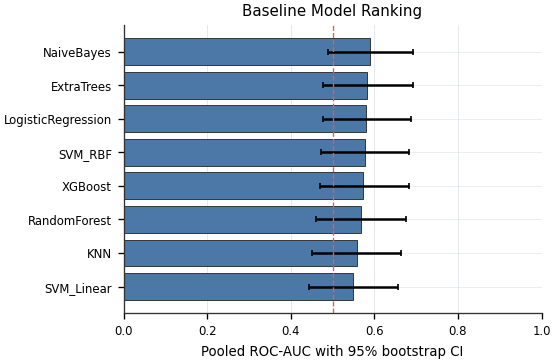

Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig02_baseline_roc_curves_top_models.png
Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig02_baseline_roc_curves_top_models.pdf


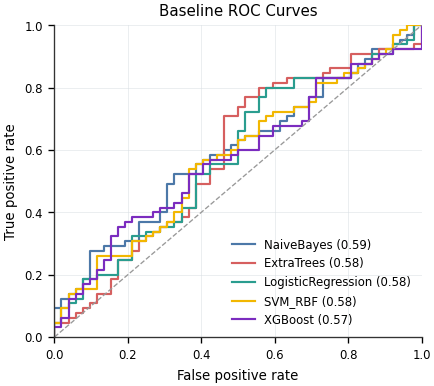

Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig03_baseline_best_model_confusion_matrix.png
Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig03_baseline_best_model_confusion_matrix.pdf


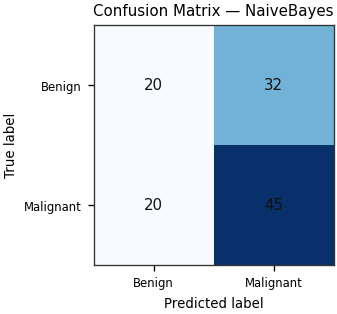

Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig04_baseline_best_model_calibration_curve.png
Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig04_baseline_best_model_calibration_curve.pdf


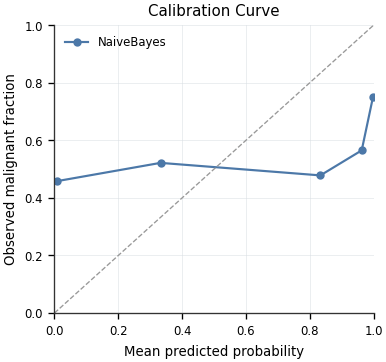

Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig05_baseline_best_model_metric_profile.png
Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig05_baseline_best_model_metric_profile.pdf


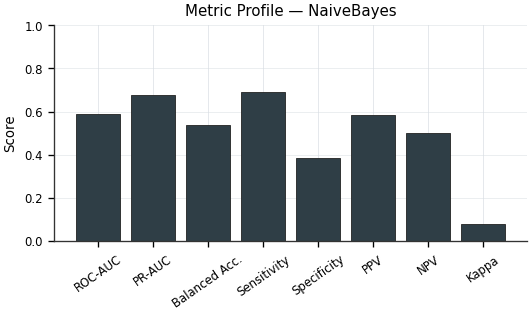

Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig06_baseline_feature_selection_stability.png
Saved: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/step_2b_baseline_reports/plots_publication_style/fig06_baseline_feature_selection_stability.pdf


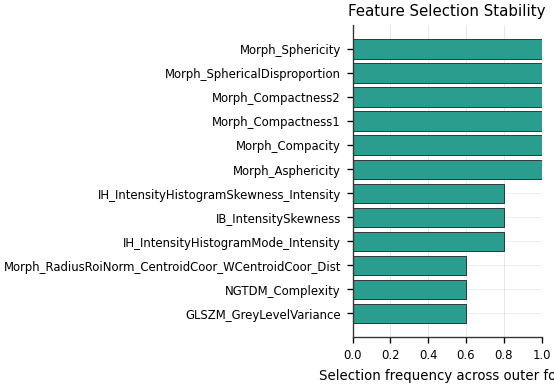


════════════════════════════════════════════════════════════════════════════════
STEP 2B BASELINE SUMMARY
════════════════════════════════════════════════════════════════════════════════
run_name: step_2_baseline_nested_cv_no_smote
save_dir: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote
best_model_by_pooled_auc: NaiveBayes
best_model_roc_auc: 0.5905325443786983
best_model_roc_auc_ci95_low: 0.4888885636221702
best_model_roc_auc_ci95_high: 0.6931311800676553
best_model_pr_auc: 0.6774345078568758
best_model_accuracy: 0.5555555555555556
best_model_balanced_accuracy: 0.5384615384615384
best_model_sensitivity: 0.6923076923076923
best_model_specificity: 0.38461538461538464
best_model_ppv: 0.5844155844155844
best_model_npv: 0.5
best_model_f1: 0.6338028169014085
best_model_cohen_kappa: 0.07874015748031493
best_model_brier_score: 0.3735321070921374
friedman_auc_p_value: 0.6049036814066713
n_models_evaluated: 10
use_smote: False
fs_method: boruta_like
fs_n_features: 16
n_outer_folds: 5


In [170]:
# =============================================================================
# STEP 2B — BASELINE NESTED-CV STATISTICAL REPORTING AND COMPACT FIGURES
# =============================================================================
# Purpose:
#   - Summarize baseline nested-CV performance.
#   - Compute pooled metrics: ROC-AUC, PR-AUC, accuracy, balanced accuracy,
#     sensitivity, specificity, PPV, NPV, F1, Cohen's kappa, Brier score.
#   - Add exploratory statistical comparisons across models.
#   - Generate compact, non-redundant, publication-style plots.
#
# Important:
#   - This cell does NOT retrain models.
#   - It only analyzes outputs from nested_cv_results, df_summary, df_fold_details,
#     and pm_df.
# =============================================================================
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)


print("█" * 80)
print("  STEP 2B — BASELINE STATISTICAL EVALUATION AND PUBLICATION FIGURES")
print("█" * 80)

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    calibration_curve
)

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Output directories
# -----------------------------------------------------------------------------
baseline_dir = CONFIG.get(
    "SAVE_DIR",
    os.path.join("./nested_cv_outputs", "step_2_baseline_nested_cv_no_smote")
)

report_dir = os.path.join(baseline_dir, "step_2b_baseline_reports")
plot_dir = os.path.join(report_dir, "plots_publication_style")

os.makedirs(report_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

print(f"\nBaseline report directory:\n  {report_dir}")
print(f"Plot directory:\n  {plot_dir}")

# -----------------------------------------------------------------------------
# 2. Publication-style plotting theme
# -----------------------------------------------------------------------------
plt.style.use("default")

FIG_DPI = 600

COLORS = {
    "primary": "#4C78A8",
    "secondary": "#D65F5F",
    "accent": "#2A9D8F",
    "dark": "#2F3E46",
    "neutral": "#6C757D",
    "light": "#F1F3F5",
    "grid": "#D9DEE3"
}

MODEL_COLORS = [
    "#4C78A8", "#D65F5F", "#2A9D8F", "#F2B701",
    "#7B2CBF", "#6C757D", "#E76F51", "#264653"
]

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axis(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


def save_figure(fig, filename_base):
    png_path = os.path.join(plot_dir, f"{filename_base}.png")
    pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def compute_specificity_np(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def compute_npv_np(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def bootstrap_metric_ci(y_true, y_score_or_pred, metric_func, n_boot=2000, seed=100):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    arr = np.asarray(y_score_or_pred)
    n = len(y_true)

    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        # Skip bootstrap samples with one class only for AUC-like metrics
        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            values.append(metric_func(y_true[idx], arr[idx]))
        except Exception:
            continue

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    values = np.asarray(values, dtype=float)
    return (
        float(np.nanmean(values)),
        float(np.nanpercentile(values, 2.5)),
        float(np.nanpercentile(values, 97.5))
    )


# -----------------------------------------------------------------------------
# 3. Required object checks
# -----------------------------------------------------------------------------
required_objects = ["nested_cv_results", "df_summary", "df_fold_details", "pm_df"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise RuntimeError(f"Required object '{obj_name}' not found. Run Cell 13 and Cell 14 first.")

# -----------------------------------------------------------------------------
# 4. Pooled baseline metrics for each model
# -----------------------------------------------------------------------------
pooled_rows = []

for model_name, res in nested_cv_results.items():
    y_true = np.asarray(res["y_true"], dtype=int)
    y_prob = np.asarray(res["y_prob"], dtype=float)
    y_pred = np.asarray(res["y_pred"], dtype=int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    specificity = compute_specificity_np(y_true, y_pred)
    ppv = precision_score(y_true, y_pred, zero_division=0)
    npv = compute_npv_np(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_prob)

    auc_mean_boot, auc_ci_low, auc_ci_high = bootstrap_metric_ci(
        y_true,
        y_prob,
        roc_auc_score,
        n_boot=2000,
        seed=CONFIG.get("RANDOM_STATE", 100)
    )

    pr_mean_boot, pr_ci_low, pr_ci_high = bootstrap_metric_ci(
        y_true,
        y_prob,
        average_precision_score,
        n_boot=2000,
        seed=CONFIG.get("RANDOM_STATE", 100) + 1
    )

    pooled_rows.append({
        "Model": model_name,
        "ROC_AUC": roc_auc,
        "ROC_AUC_bootstrap_mean": auc_mean_boot,
        "ROC_AUC_CI95_low": auc_ci_low,
        "ROC_AUC_CI95_high": auc_ci_high,
        "PR_AUC": pr_auc,
        "PR_AUC_bootstrap_mean": pr_mean_boot,
        "PR_AUC_CI95_low": pr_ci_low,
        "PR_AUC_CI95_high": pr_ci_high,
        "Accuracy": acc,
        "Balanced_Accuracy": bal_acc,
        "Sensitivity_Recall": sensitivity,
        "Specificity": specificity,
        "PPV_Precision": ppv,
        "NPV": npv,
        "F1": f1,
        "Cohen_Kappa": kappa,
        "Brier_Score": brier,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
        "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
    })

baseline_pooled_metrics_df = pd.DataFrame(pooled_rows)
baseline_pooled_metrics_df = baseline_pooled_metrics_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

baseline_pooled_metrics_df.to_csv(
    os.path.join(report_dir, "baseline_pooled_metrics_with_ci.csv"),
    index=False
)

print("\n" + "═" * 80)
print("BASELINE POOLED METRICS")
print("═" * 80)
print(
    baseline_pooled_metrics_df[
        [
            "Model", "ROC_AUC", "ROC_AUC_CI95_low", "ROC_AUC_CI95_high",
            "PR_AUC", "Accuracy", "Balanced_Accuracy",
            "Sensitivity_Recall", "Specificity", "PPV_Precision", "NPV",
            "F1", "Cohen_Kappa", "Brier_Score", "Mean_Selected_Features"
        ]
    ].to_string(index=False, float_format="%.4f")
)

best_model_name = baseline_pooled_metrics_df.iloc[0]["Model"]
best_res = nested_cv_results[best_model_name]

print(f"\nBest baseline model by pooled ROC-AUC: {best_model_name}")

# -----------------------------------------------------------------------------
# 5. Exploratory model comparison statistics
# -----------------------------------------------------------------------------
# Friedman test across models using fold AUCs.
# With 5 outer folds, this is exploratory and low-powered.
fold_auc_table = pm_df.pivot(index="Fold", columns="Model", values="AUC")

model_comparison_summary = {}

if fold_auc_table.shape[1] >= 3:
    try:
        friedman_stat, friedman_p = friedmanchisquare(
            *[fold_auc_table[col].values for col in fold_auc_table.columns]
        )
    except Exception:
        friedman_stat, friedman_p = np.nan, np.nan
else:
    friedman_stat, friedman_p = np.nan, np.nan

model_comparison_summary["friedman_auc_statistic"] = float(friedman_stat) if np.isfinite(friedman_stat) else None
model_comparison_summary["friedman_auc_p_value"] = float(friedman_p) if np.isfinite(friedman_p) else None

# Pairwise Wilcoxon against best model
pairwise_rows = []

if best_model_name in fold_auc_table.columns:
    best_auc_values = fold_auc_table[best_model_name].values

    for model_name in fold_auc_table.columns:
        if model_name == best_model_name:
            continue

        other_auc_values = fold_auc_table[model_name].values

        try:
            stat, p = wilcoxon(
                best_auc_values,
                other_auc_values,
                zero_method="wilcox",
                alternative="two-sided"
            )
        except Exception:
            stat, p = np.nan, np.nan

        pairwise_rows.append({
            "Comparison": f"{best_model_name} vs {model_name}",
            "Best_Model": best_model_name,
            "Other_Model": model_name,
            "Mean_AUC_Best": np.mean(best_auc_values),
            "Mean_AUC_Other": np.mean(other_auc_values),
            "Mean_AUC_Difference": np.mean(best_auc_values - other_auc_values),
            "Wilcoxon_Statistic": stat,
            "Wilcoxon_p_value": p
        })

pairwise_model_tests_df = pd.DataFrame(pairwise_rows)

if len(pairwise_model_tests_df) > 0:
    pvals = pairwise_model_tests_df["Wilcoxon_p_value"].values.astype(float)

    valid = np.isfinite(pvals)
    qvals = np.full(len(pvals), np.nan)

    if valid.sum() > 0:
        valid_p = pvals[valid]
        order = np.argsort(valid_p)
        ranked = valid_p[order]
        adjusted = ranked * len(valid_p) / (np.arange(1, len(valid_p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)
        q_valid = np.empty_like(valid_p)
        q_valid[order] = adjusted
        qvals[valid] = q_valid

    pairwise_model_tests_df["Wilcoxon_q_value_FDR"] = qvals

pairwise_model_tests_df.to_csv(
    os.path.join(report_dir, "baseline_pairwise_wilcoxon_auc_vs_best.csv"),
    index=False
)

with open(os.path.join(report_dir, "baseline_model_comparison_summary.json"), "w") as f:
    json.dump(model_comparison_summary, f, indent=4)

print("\n" + "═" * 80)
print("EXPLORATORY MODEL COMPARISON")
print("═" * 80)
print(f"Friedman test across model fold-AUCs: p = {friedman_p:.6f}" if np.isfinite(friedman_p) else "Friedman test not available.")

if len(pairwise_model_tests_df) > 0:
    print("\nPairwise Wilcoxon tests vs best model:")
    print(pairwise_model_tests_df.to_string(index=False, float_format="%.4f"))


# -----------------------------------------------------------------------------
# 6. Figure 1 — Model ROC-AUC ranking with bootstrap CI
# -----------------------------------------------------------------------------
top_models_auc = baseline_pooled_metrics_df.head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(4.8, 3.2))

xerr_low = top_models_auc["ROC_AUC"] - top_models_auc["ROC_AUC_CI95_low"]
xerr_high = top_models_auc["ROC_AUC_CI95_high"] - top_models_auc["ROC_AUC"]

ax.barh(
    top_models_auc["Model"],
    top_models_auc["ROC_AUC"],
    xerr=[xerr_low, xerr_high],
    color=COLORS["primary"],
    edgecolor="#222222",
    linewidth=0.5,
    capsize=2
)

ax.axvline(0.5, linestyle="--", linewidth=0.8, color=COLORS["secondary"])
ax.set_xlim(0.0, 1.0)
ax.set_title("Baseline Model Ranking")
ax.set_xlabel("Pooled ROC-AUC with 95% bootstrap CI")
ax.set_ylabel("")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig01_baseline_model_auc_ranking")
plt.show()


# -----------------------------------------------------------------------------
# 7. Figure 2 — ROC curves for top models
# -----------------------------------------------------------------------------
top_roc_models = baseline_pooled_metrics_df["Model"].head(min(5, len(baseline_pooled_metrics_df))).tolist()

fig, ax = plt.subplots(figsize=(3.8, 3.4))

for i, model_name in enumerate(top_roc_models):
    res = nested_cv_results[model_name]
    y_true = np.asarray(res["y_true"], dtype=int)
    y_prob = np.asarray(res["y_prob"], dtype=float)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)

    ax.plot(
        fpr,
        tpr,
        linewidth=1.3,
        color=MODEL_COLORS[i % len(MODEL_COLORS)],
        label=f"{model_name} ({auc_value:.2f})"
    )

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")
ax.set_title("Baseline ROC Curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
clean_axis(ax, grid_axis="both")

plt.tight_layout()
save_figure(fig, "fig02_baseline_roc_curves_top_models")
plt.show()


# -----------------------------------------------------------------------------
# 8. Figure 3 — Confusion matrix for best baseline model
# -----------------------------------------------------------------------------
best_y_true = np.asarray(best_res["y_true"], dtype=int)
best_y_prob = np.asarray(best_res["y_prob"], dtype=float)
best_y_pred = np.asarray(best_res["y_pred"], dtype=int)

cm = confusion_matrix(best_y_true, best_y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(3.1, 2.8))

im = ax.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="#111111",
            fontsize=9
        )

ax.set_title(f"Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benign", "Malignant"])
ax.set_yticklabels(["Benign", "Malignant"])
ax.grid(False)

plt.tight_layout()
save_figure(fig, "fig03_baseline_best_model_confusion_matrix")
plt.show()


# -----------------------------------------------------------------------------
# 9. Figure 4 — Calibration curve for best baseline model
# -----------------------------------------------------------------------------
frac_pos, mean_pred = manual_calibration_curve(
    best_y_true,
    best_y_prob,
    n_bins=5
)

fig, ax = plt.subplots(figsize=(3.4, 3.2))

ax.plot(
    mean_pred,
    frac_pos,
    marker="o",
    linewidth=1.3,
    markersize=4,
    color=COLORS["primary"],
    label=best_model_name
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

ax.set_title("Calibration Curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed malignant fraction")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper left")
clean_axis(ax, grid_axis="both")

plt.tight_layout()
save_figure(fig, "fig04_baseline_best_model_calibration_curve")
plt.show()


# -----------------------------------------------------------------------------
# 10. Figure 5 — Compact metric profile for best model
# -----------------------------------------------------------------------------
best_metric_row = baseline_pooled_metrics_df[
    baseline_pooled_metrics_df["Model"] == best_model_name
].iloc[0]

metric_profile = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Balanced Acc.",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Kappa"
    ],
    "Value": [
        best_metric_row["ROC_AUC"],
        best_metric_row["PR_AUC"],
        best_metric_row["Balanced_Accuracy"],
        best_metric_row["Sensitivity_Recall"],
        best_metric_row["Specificity"],
        best_metric_row["PPV_Precision"],
        best_metric_row["NPV"],
        best_metric_row["Cohen_Kappa"]
    ]
})

metric_profile.to_csv(
    os.path.join(report_dir, "baseline_best_model_metric_profile.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(4.6, 2.8))

ax.bar(
    metric_profile["Metric"],
    metric_profile["Value"],
    color=COLORS["dark"],
    edgecolor="#222222",
    linewidth=0.5
)

ax.set_ylim(0, 1)
ax.set_title(f"Metric Profile — {best_model_name}")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35)
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig05_baseline_best_model_metric_profile")
plt.show()


# -----------------------------------------------------------------------------
# 11. Figure 6 — Feature selection stability among selected features
# -----------------------------------------------------------------------------
if "df_selected_features_long" in globals() and len(df_selected_features_long) > 0:
    stability_df = (
        df_selected_features_long
        .groupby("Feature_Name")
        .size()
        .reset_index(name="Selection_Count")
        .sort_values("Selection_Count", ascending=False)
    )

    stability_df["Selection_Frequency"] = stability_df["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]

    stability_df.to_csv(
        os.path.join(report_dir, "baseline_feature_selection_stability.csv"),
        index=False
    )

    top_stable = stability_df.head(12).iloc[::-1]

    fig, ax = plt.subplots(figsize=(4.8, 3.4))

    ax.barh(
        top_stable["Feature_Name"],
        top_stable["Selection_Frequency"],
        color=COLORS["accent"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_xlim(0, 1)
    ax.set_title("Feature Selection Stability")
    ax.set_xlabel("Selection frequency across outer folds")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig06_baseline_feature_selection_stability")
    plt.show()
else:
    stability_df = pd.DataFrame()
    print("\nNo selected feature long table found; stability plot skipped.")


# -----------------------------------------------------------------------------
# 12. Compact summary JSON
# -----------------------------------------------------------------------------
step_2b_summary = {
    "run_name": CONFIG.get("RUN_NAME", "step_2_baseline_nested_cv_no_smote"),
    "save_dir": baseline_dir,
    "best_model_by_pooled_auc": best_model_name,
    "best_model_roc_auc": float(best_metric_row["ROC_AUC"]),
    "best_model_roc_auc_ci95_low": float(best_metric_row["ROC_AUC_CI95_low"]),
    "best_model_roc_auc_ci95_high": float(best_metric_row["ROC_AUC_CI95_high"]),
    "best_model_pr_auc": float(best_metric_row["PR_AUC"]),
    "best_model_accuracy": float(best_metric_row["Accuracy"]),
    "best_model_balanced_accuracy": float(best_metric_row["Balanced_Accuracy"]),
    "best_model_sensitivity": float(best_metric_row["Sensitivity_Recall"]),
    "best_model_specificity": float(best_metric_row["Specificity"]),
    "best_model_ppv": float(best_metric_row["PPV_Precision"]),
    "best_model_npv": float(best_metric_row["NPV"]),
    "best_model_f1": float(best_metric_row["F1"]),
    "best_model_cohen_kappa": float(best_metric_row["Cohen_Kappa"]),
    "best_model_brier_score": float(best_metric_row["Brier_Score"]),
    "friedman_auc_p_value": (
        float(friedman_p) if np.isfinite(friedman_p) else None
    ),
    "n_models_evaluated": int(len(baseline_pooled_metrics_df)),
    "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
    "fs_method": CONFIG.get("FS_METHOD", None),
    "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
    "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
    "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
    "report_dir": report_dir,
    "plot_dir": plot_dir
}

with open(os.path.join(report_dir, "step_2b_summary.json"), "w") as f:
    json.dump(step_2b_summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 2B BASELINE SUMMARY")
print("═" * 80)

for k, v in step_2b_summary.items():
    print(f"{k}: {v}")

print("\nSaved baseline reports and compact publication-style plots to:")
print(f"  {report_dir}")
print(f"  {plot_dir}")

print("\n✅ STEP 2B completed successfully.")

In [171]:
# =============================================================================
# STEP 3A — SMOTE ABLATION CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run the same nested-CV pipeline as baseline.
#   - Only change imbalance handling: USE_SMOTE = True.
#   - Keep feature selection, models, folds, Optuna trials, and random seed fixed.
# =============================================================================

print("█" * 80)
print("  STEP 3A — SMOTE ABLATION CONFIGURATION LOCK")
print("█" * 80)

import os
import json

CONFIG["RUN_NAME"] = "step_3_smote_nested_cv"
CONFIG["SAVE_DIR"] = os.path.join(
    "./nested_cv_outputs",
    CONFIG["RUN_NAME"]
)

os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# CONFIG["USE_SMOTE"] = True

# Keep previous baseline settings fixed
CONFIG["FS_METHOD"] = CONFIG.get("FS_METHOD")
CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

if "groups" not in globals():
    raise RuntimeError("groups object not found. Run Step 1 first.")

smote_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups)))
}

with open(os.path.join(CONFIG["SAVE_DIR"], "smote_config_snapshot.json"), "w") as f:
    json.dump(smote_config_snapshot, f, indent=4)

print("\nSMOTE ablation configuration:")
for k, v in smote_config_snapshot.items():
    print(f"  {k}: {v}")

print("\n✅ STEP 3A completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 3A — SMOTE ABLATION CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████

SMOTE ablation configuration:
  RUN_NAME: step_3_smote_nested_cv
  SAVE_DIR: ./nested_cv_outputs/step_3_smote_nested_cv
  USE_SMOTE: False
  FS_METHOD: boruta_like
  FS_N_FEATURES: 16
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 20
  RANDOM_STATE: 100
  N_SAMPLES: 117
  N_FEATURES: 145
  N_PATIENTS: 48

✅ STEP 3A completed successfully.


In [172]:
publication_all_models_df.to_csv(
    os.path.join(CONFIG.get('SAVE_DIR', './nested_cv_outputs'),
                 'publication_all_models_summary.csv'),
    index=False
)

all_model_summary_df.to_csv(
    os.path.join(CONFIG.get('SAVE_DIR', './nested_cv_outputs'),
                 'all_model_summary_statistics.csv'),
    index=False
)

🤖 Best Model Detected: SVM_RBF

✅ High-resolution plot (DPI 900) saved to: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/best_model_SVM_RBF_folds_report.png


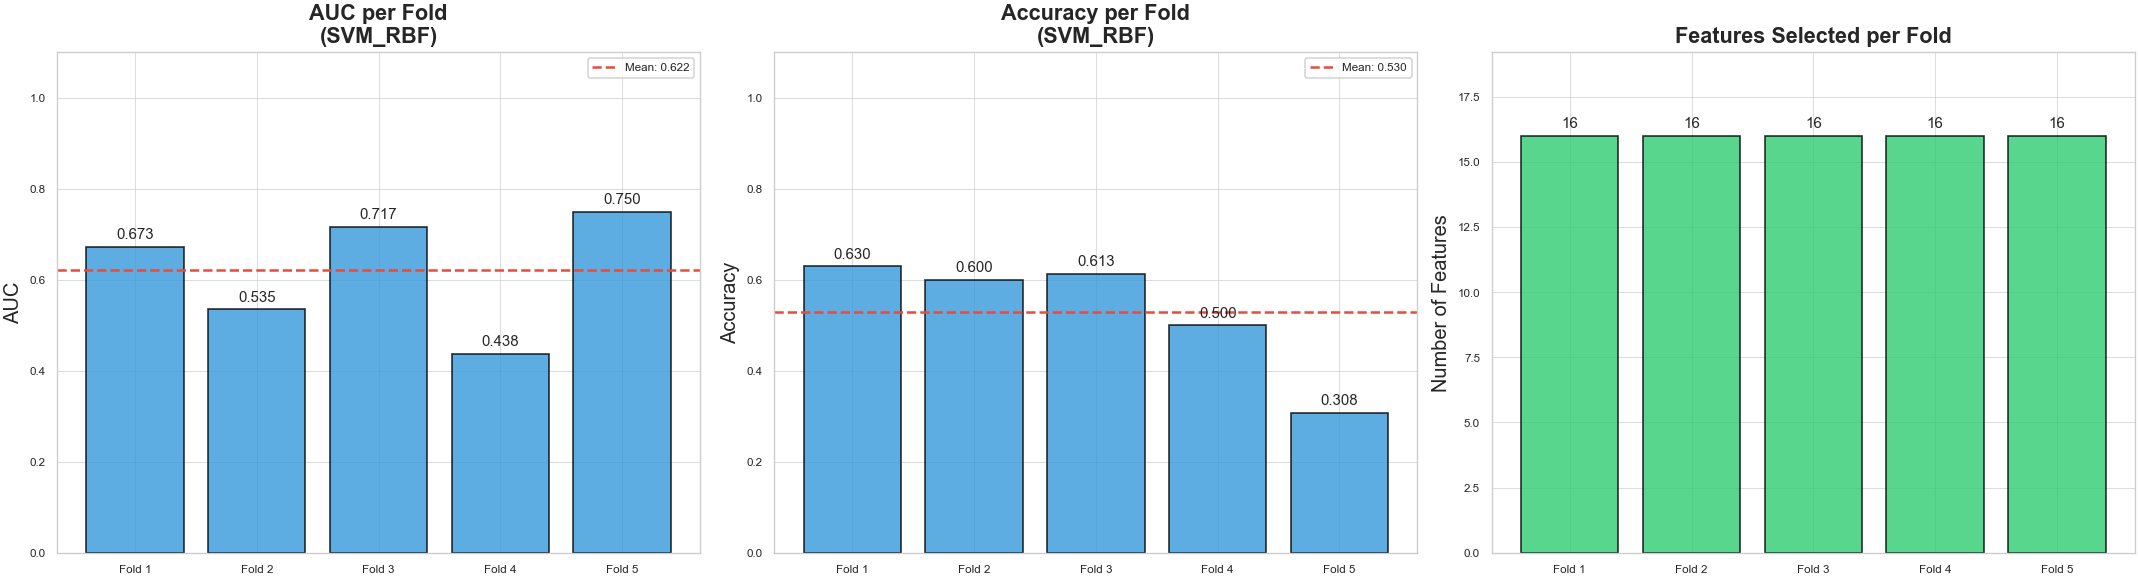


📊 FINAL SUMMARY (SVM_RBF - 5-Fold Cross-Validation)

🔹 AUC:       0.6225 ± 0.1179
   Range: [0.4375, 0.7500]

🔹 Accuracy:  0.5300 ± 0.1200


In [173]:
# =============================================================================
# COHORT GRAPHICAL REPORTING AND FEATURE SELECTION STABILITY MANIFEST
# =============================================================================
# Purpose:
#   - Isolate execution results for the top-performing estimator configuration.
#   - Generate publication-grade, high-resolution tripartite diagnostic charts.
#   - Synthesize a structural feature selection recurrence manifest to evaluate 
#     cross-fold biomarker stability and reproducibility metrics.
# =============================================================================

import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply standardized uniform layout parameters for peer-review charting
sns.set_style("whitegrid")

df_summary = df_summary.sort_values(by='Mean_AUC', ascending=False).reset_index(drop=True)
best_model_name = df_summary.iloc[0]['Model']

# Dynamically isolate the highest performing configuration matrix pattern
best_model_name = df_summary.iloc[0]['Model'] 
print(f"🤖 Best Model Detected: {best_model_name}\n")

# Filter localized out-of-fold diagnostic matrices matching the top candidate
best_model_folds = df_fold_details[df_fold_details['Model'] == best_model_name].copy()

actual_n_outer = len(best_model_folds)

fold_labels = [f"Fold {int(f)}" for f in best_model_folds['Fold']]
aucs = best_model_folds['AUC'].values
accuracies = best_model_folds['Acc'].values
n_features = best_model_folds['n_features'].values

mean_auc = np.mean(aucs)
mean_acc = np.mean(accuracies)

# --- Subplot 1 to 3: Multi-panel Diagnostic Performance Charts ---------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db'] * actual_n_outer

# 1️⃣ Subplot A: Receiver Operating Characteristic Area Under Curve (AUC)
ax1 = axes[0]
bars1 = ax1.bar(fold_labels, aucs, color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_title(f'AUC per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax1.set_ylim(0.0, 1.1)  # Expanded upper boundary to accommodate structural annotation text
ax1.axhline(y=mean_auc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_auc:.3f}")
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax1.legend()

# 2️⃣ Subplot B: Empirical Classification Accuracy Profiles
ax2 = axes[1]
bars2 = ax2.bar(fold_labels, accuracies, color=colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'Accuracy per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax2.set_ylim(0.0, 1.1)
ax2.axhline(y=mean_acc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_acc:.3f}")
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax2.legend()

# 3️⃣ Subplot C: Selected Feature Cardinality Volatility Matrix
ax3 = axes[2]
bars3 = ax3.bar(fold_labels, n_features, color='#2ecc71', edgecolor='black', alpha=0.8)
ax3.set_ylabel('Number of Features', fontsize=12)
ax3.set_title('Features Selected per Fold', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(n_features) * 1.2 if len(n_features) > 0 else 10)
for bar in bars3:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save structural presentation graphics using extreme high-resolution (DPI 900)
os.makedirs(SAVE_DIR, exist_ok=True)
plot_path = os.path.join(SAVE_DIR, f"best_model_{best_model_name}_folds_report.png")
plt.savefig(plot_path, dpi=600)
print(f"✅ High-resolution plot (DPI 900) saved to: {plot_path}")
plt.show()
plt.close()


# =============================================================================
# COHORT SUMMARY AND INFERENCE CRITERIA TABLES
# =============================================================================
print("\n" + "="*60)
print(f"📊 FINAL SUMMARY ({best_model_name} - {actual_n_outer}-Fold Cross-Validation)")
print("="*60)

print(f"\n🔹 AUC:       {mean_auc:.4f} ± {np.std(aucs):.4f}")
print(f"   Range: [{np.min(aucs):.4f}, {np.max(aucs):.4f}]")

print(f"\n🔹 Accuracy:  {mean_acc:.4f} ± {np.std(accuracies):.4f}")


In [174]:
    # =============================================================================
    # STEP 3B — SMOTE VS BASELINE STATISTICAL COMPARISON AND COMPACT FIGURES
    # =============================================================================
    # Purpose:
    #   - Compare Step 3 SMOTE run against Step 2 baseline.
    #   - Use the same models, same CV design, and same evaluation logic.
    #   - Compute pooled metric deltas, paired bootstrap CIs, and fold-wise Wilcoxon tests.
    #   - Generate compact publication-style comparison plots.
    #
    # Important:
    #   - This cell does NOT retrain models.
    #   - It analyzes the current SMOTE nested_cv_results and the saved baseline outputs.
    # =============================================================================
current_use_smote = bool(CONFIG.get("USE_SMOTE", False))

if not current_use_smote:
    print("█" * 80)
    print("  STEP 3B — SKIPPED")
    print("█" * 80)
    print("This cell is only for SMOTE-enabled runs.")
    print(f"Current USE_SMOTE is: {CONFIG.get('USE_SMOTE', None)}")
    print("No SMOTE-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 3B — SMOTE VS BASELINE COMPARISON")
    print("█" * 80)

    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        "./nested_cv_outputs",
        "step_2_baseline_nested_cv_no_smote"
    )

    smote_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join("./nested_cv_outputs", "step_3_smote_nested_cv")
    )

    comparison_dir = os.path.join(smote_dir, "step_3b_smote_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline nested_cv_results not found:\n{baseline_pkl_path}\n"
            "Make sure Step 2 baseline Cell 13 was completed and saved."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current SMOTE nested_cv_results not found. Run Cell 13 after Step 3A.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    smote_results = nested_cv_results

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current SMOTE results from runtime and SAVE_DIR:\n  {smote_dir}")

    # -----------------------------------------------------------------------------
    # 2. Publication-style plotting theme
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "smote": "#D65F5F",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "dark": "#2F3E46",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        """
        Paired bootstrap CI for delta = metric_b - metric_a.
        Here:
            a = baseline
            b = SMOTE
        """
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute pooled metrics
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    smote_metrics_df = pooled_metrics_from_results(smote_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    smote_metrics_df.to_csv(
        os.path.join(comparison_dir, "smote_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(smote_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        s_row = smote_metrics_df[smote_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        s_res = smote_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        s_y_true = np.asarray(s_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(s_y_true)
            and np.array_equal(b_y_true, s_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(s_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(s_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        # Fold-wise Wilcoxon on outer-fold AUCs
        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        s_fold_auc = np.asarray(s_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(s_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    s_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "SMOTE_ROC_AUC": s_row["ROC_AUC"],
            "Delta_ROC_AUC_SMOTE_minus_Baseline": s_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "SMOTE_PR_AUC": s_row["PR_AUC"],
            "Delta_PR_AUC_SMOTE_minus_Baseline": s_row["PR_AUC"] - b_row["PR_AUC"],
            "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

            "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
            "SMOTE_Balanced_Accuracy": s_row["Balanced_Accuracy"],
            "Delta_Balanced_Accuracy": s_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "SMOTE_Sensitivity": s_row["Sensitivity"],
            "Delta_Sensitivity": s_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "SMOTE_Specificity": s_row["Specificity"],
            "Delta_Specificity": s_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "SMOTE_PPV": s_row["PPV"],
            "Delta_PPV": s_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "SMOTE_NPV": s_row["NPV"],
            "Delta_NPV": s_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "SMOTE_Kappa": s_row["Cohen_Kappa"],
            "Delta_Kappa": s_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "SMOTE_Brier": s_row["Brier_Score"],
            "Delta_Brier_SMOTE_minus_Baseline": s_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "SMOTE_Mean_Selected_Features": s_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_SMOTE_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "smote_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("SMOTE VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "SMOTE_ROC_AUC",
        "Delta_ROC_AUC_SMOTE_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "SMOTE_PR_AUC",
        "Delta_PR_AUC_SMOTE_minus_Baseline",
        "Baseline_Sensitivity",
        "SMOTE_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "SMOTE_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 4. Choose best SMOTE and best baseline models
    # -----------------------------------------------------------------------------
    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_smote_model = smote_metrics_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best SMOTE model:   ", best_smote_model)

    best_delta_model = comparison_df.iloc[0]["Model"]
    print("Largest ROC-AUC gain with SMOTE:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 5. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.copy()
    delta_plot = delta_plot.sort_values("Delta_ROC_AUC_SMOTE_minus_Baseline", ascending=True)

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_SMOTE_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_SMOTE_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of SMOTE on ROC-AUC")
    ax.set_xlabel("Δ ROC-AUC: SMOTE − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_smote_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 2 — Baseline vs SMOTE ROC-AUC paired bars for top changed models
    # -----------------------------------------------------------------------------
    top_changed = comparison_df.reindex(
        comparison_df["Delta_ROC_AUC_SMOTE_minus_Baseline"].abs().sort_values(ascending=False).index
    ).head(6)

    x = np.arange(len(top_changed))
    width = 0.36

    fig, ax = plt.subplots(figsize=(5.0, 3.0))

    ax.bar(
        x - width / 2,
        top_changed["Baseline_ROC_AUC"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        top_changed["SMOTE_ROC_AUC"],
        width,
        label="SMOTE",
        color=COLORS["smote"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title("ROC-AUC Before and After SMOTE")
    ax.set_ylabel("ROC-AUC")
    ax.set_xticks(x)
    ax.set_xticklabels(top_changed["Model"], rotation=35, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig02_baseline_vs_smote_roc_auc_top_models")
    plt.show()

    # -----------------------------------------------------------------------------
    # 7. Figure 3 — ROC curves for best baseline and best SMOTE model
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    s_res = smote_results[best_smote_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    s_y_true = np.asarray(s_res["y_true"], dtype=int)
    s_y_prob = np.asarray(s_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    s_fpr, s_tpr, _ = roc_curve(s_y_true, s_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    s_auc = roc_auc_score(s_y_true, s_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        s_fpr,
        s_tpr,
        linewidth=1.4,
        color=COLORS["smote"],
        label=f"SMOTE: {best_smote_model} ({s_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig03_best_baseline_vs_smote_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 8. Figure 4 — Sensitivity/specificity trade-off for best changed model
    # -----------------------------------------------------------------------------
    trade_model = best_delta_model

    trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

    trade_df = pd.DataFrame({
        "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
        "Baseline": [
            trade_row["Baseline_Sensitivity"],
            trade_row["Baseline_Specificity"],
            trade_row["Baseline_PPV"],
            trade_row["Baseline_NPV"],
            trade_row["Baseline_Kappa"]
        ],
        "SMOTE": [
            trade_row["SMOTE_Sensitivity"],
            trade_row["SMOTE_Specificity"],
            trade_row["SMOTE_PPV"],
            trade_row["SMOTE_NPV"],
            trade_row["SMOTE_Kappa"]
        ]
    })

    trade_df.to_csv(
        os.path.join(comparison_dir, "best_delta_model_metric_tradeoff.csv"),
        index=False
    )

    x = np.arange(len(trade_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(4.8, 2.9))

    ax.bar(
        x - width / 2,
        trade_df["Baseline"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        trade_df["SMOTE"],
        width,
        label="SMOTE",
        color=COLORS["smote"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Trade-off — {trade_model}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig04_smote_metric_tradeoff_best_delta_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 9. Figure 5 — Fold AUC paired lines for best delta model
    # -----------------------------------------------------------------------------
    b_fold_auc = np.asarray(baseline_results[trade_model]["fold_aucs"], dtype=float)
    s_fold_auc = np.asarray(smote_results[trade_model]["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(s_fold_auc):
        fig, ax = plt.subplots(figsize=(3.8, 2.8))

        for i in range(len(b_fold_auc)):
            ax.plot(
                [0, 1],
                [b_fold_auc[i], s_fold_auc[i]],
                marker="o",
                linewidth=0.9,
                color=COLORS["neutral"],
                alpha=0.8
            )

        ax.scatter(
            np.zeros_like(b_fold_auc),
            b_fold_auc,
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="Baseline"
        )

        ax.scatter(
            np.ones_like(s_fold_auc),
            s_fold_auc,
            color=COLORS["smote"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="SMOTE"
        )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "SMOTE"])
        ax.set_ylim(0, 1)
        ax.set_title(f"Outer-fold ROC-AUC Change — {trade_model}")
        ax.set_ylabel("Fold ROC-AUC")
        ax.legend(frameon=False, loc="best")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig05_outer_fold_auc_paired_change_best_delta_model")
        plt.show()

    # -----------------------------------------------------------------------------
    # 10. Feature stability comparison
    # -----------------------------------------------------------------------------
    baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")
    smote_features_path = os.path.join(smote_dir, "df_selected_features_long.csv")

    feature_stability_comparison = pd.DataFrame()

    if os.path.exists(baseline_features_path) and os.path.exists(smote_features_path):
        b_feat = pd.read_csv(baseline_features_path)
        s_feat = pd.read_csv(smote_features_path)

        b_stab = (
            b_feat.groupby("Feature_Name")
            .size()
            .reset_index(name="Baseline_Selection_Count")
        )

        s_stab = (
            s_feat.groupby("Feature_Name")
            .size()
            .reset_index(name="SMOTE_Selection_Count")
        )

        feature_stability_comparison = b_stab.merge(
            s_stab,
            on="Feature_Name",
            how="outer"
        ).fillna(0)

        feature_stability_comparison["Baseline_Selection_Frequency"] = (
            feature_stability_comparison["Baseline_Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        feature_stability_comparison["SMOTE_Selection_Frequency"] = (
            feature_stability_comparison["SMOTE_Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        feature_stability_comparison["Delta_Selection_Frequency"] = (
            feature_stability_comparison["SMOTE_Selection_Frequency"]
            - feature_stability_comparison["Baseline_Selection_Frequency"]
        )

        feature_stability_comparison = feature_stability_comparison.sort_values(
            "SMOTE_Selection_Frequency",
            ascending=False
        )

        feature_stability_comparison.to_csv(
            os.path.join(comparison_dir, "feature_stability_baseline_vs_smote.csv"),
            index=False
        )

        top_stability = feature_stability_comparison.head(10).iloc[::-1]

        fig, ax = plt.subplots(figsize=(5.0, 3.2))

        x = np.arange(len(top_stability))
        width = 0.36

        ax.barh(
            x - width / 2,
            top_stability["Baseline_Selection_Frequency"],
            height=width,
            label="Baseline",
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.barh(
            x + width / 2,
            top_stability["SMOTE_Selection_Frequency"],
            height=width,
            label="SMOTE",
            color=COLORS["smote"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_yticks(x)
        ax.set_yticklabels(top_stability["Feature_Name"])
        ax.set_xlim(0, 1)
        ax.set_title("Feature Selection Stability")
        ax.set_xlabel("Selection frequency")
        ax.set_ylabel("")
        ax.legend(frameon=False)
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig06_feature_stability_baseline_vs_smote")
        plt.show()

    else:
        print("\nFeature stability files not found. Stability comparison skipped.")

    # -----------------------------------------------------------------------------
    # 11. Final decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_SMOTE_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_SMOTE_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_SMOTE_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "SMOTE favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "SMOTE improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    smote_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    smote_decision_df.to_csv(
        os.path.join(comparison_dir, "smote_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("SMOTE ABLATION DECISION TABLE")
    print("═" * 80)
    print(smote_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 12. Compact summary JSON
    # -----------------------------------------------------------------------------
    step_3b_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_3_smote_nested_cv"),
        "baseline_dir": baseline_dir,
        "smote_dir": smote_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_smote_model_by_roc_auc": best_smote_model,
        "best_smote_roc_auc": float(smote_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_SMOTE_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", True)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
        "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
        "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
        "n_models_compared": int(len(common_models))
    }

    with open(os.path.join(comparison_dir, "step_3b_summary.json"), "w") as f:
        json.dump(step_3b_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 3B SUMMARY")
    print("═" * 80)

    for k, v in step_3b_summary.items():
        print(f"{k}: {v}")

    print("\nSaved SMOTE comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 3B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 3B — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for SMOTE-enabled runs.
Current USE_SMOTE is: False
No SMOTE-vs-baseline comparison was executed.


In [175]:
# =============================================================================
# STEP 4B — LASSO-ONLY FEATURE SELECTION CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run a controlled LASSO-only feature selection ablation.
#   - Keep SMOTE disabled to isolate the effect of feature selection.
# =============================================================================

print("█" * 80)
print("  STEP 4B — LASSO-ONLY CONFIGURATION LOCK")
print("█" * 80)

import os
import json
import numpy as np

CONFIG["RUN_NAME"] = "step_4_lasso_only_fs_nested_cv_no_smote"
CONFIG["SAVE_DIR"] = os.path.join(
    "./nested_cv_outputs",
    CONFIG["RUN_NAME"]
)

os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# Isolate feature-selection effect
# CONFIG["USE_SMOTE"] = False
# CONFIG["FS_METHOD"] = "lasso_only"

# Keep same target feature count as baseline
CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

# LASSO-specific settings
CONFIG["LASSO_CS"] = [float(x) for x in np.logspace(-3, 1, 10)]
CONFIG["LASSO_COEF_THRESHOLD"] = 1e-6

# Keep nested CV fixed
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

lasso_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "LASSO_CS": CONFIG["LASSO_CS"],
    "LASSO_COEF_THRESHOLD": CONFIG["LASSO_COEF_THRESHOLD"],
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups)))
}

with open(os.path.join(CONFIG["SAVE_DIR"], "lasso_only_config_snapshot.json"), "w") as f:
    json.dump(lasso_config_snapshot, f, indent=4)

print("\nLASSO-only configuration:")
for k, v in lasso_config_snapshot.items():
    print(f"  {k}: {v}")

print("\n✅ STEP 4B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 4B — LASSO-ONLY CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████

LASSO-only configuration:
  RUN_NAME: step_4_lasso_only_fs_nested_cv_no_smote
  SAVE_DIR: ./nested_cv_outputs/step_4_lasso_only_fs_nested_cv_no_smote
  USE_SMOTE: False
  FS_METHOD: boruta_like
  FS_N_FEATURES: 16
  LASSO_CS: [0.001, 0.0027825594022071257, 0.007742636826811269, 0.021544346900318832, 0.05994842503189409, 0.1668100537200059, 0.46415888336127775, 1.2915496650148828, 3.593813663804626, 10.0]
  LASSO_COEF_THRESHOLD: 1e-06
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 20
  RANDOM_STATE: 100
  N_SAMPLES: 117
  N_FEATURES: 145
  N_PATIENTS: 48

✅ STEP 4B completed successfully.


  DeLong Pairwise AUC Comparison — All Model Pairs
           Model_A            Model_B  AUC_A  AUC_B    ΔAUC Z_stat  p_value Significant (α=0.05) Significant (α=0.01) p_value_bonferroni Significant Bonf. (α=0.05)
LogisticRegression         SVM_Linear 0.5805 0.5481 +0.0324  2.048 4.05e-02                    ✓                    ✗           1.00e+00                          ✗
           SVM_RBF         SVM_Linear 0.5769 0.5481 +0.0288  1.836 6.63e-02                    ✗                    ✗           1.00e+00                          ✗
        NaiveBayes         SVM_Linear 0.5905 0.5481 +0.0425  1.441 1.49e-01                    ✗                    ✗           1.00e+00                          ✗
           XGBoost           LightGBM 0.5737 0.5388 +0.0349  1.139 2.55e-01                    ✗                    ✗           1.00e+00                          ✗
        NaiveBayes           LightGBM 0.5905 0.5388 +0.0518  0.958 3.38e-01                    ✗                    ✗           1

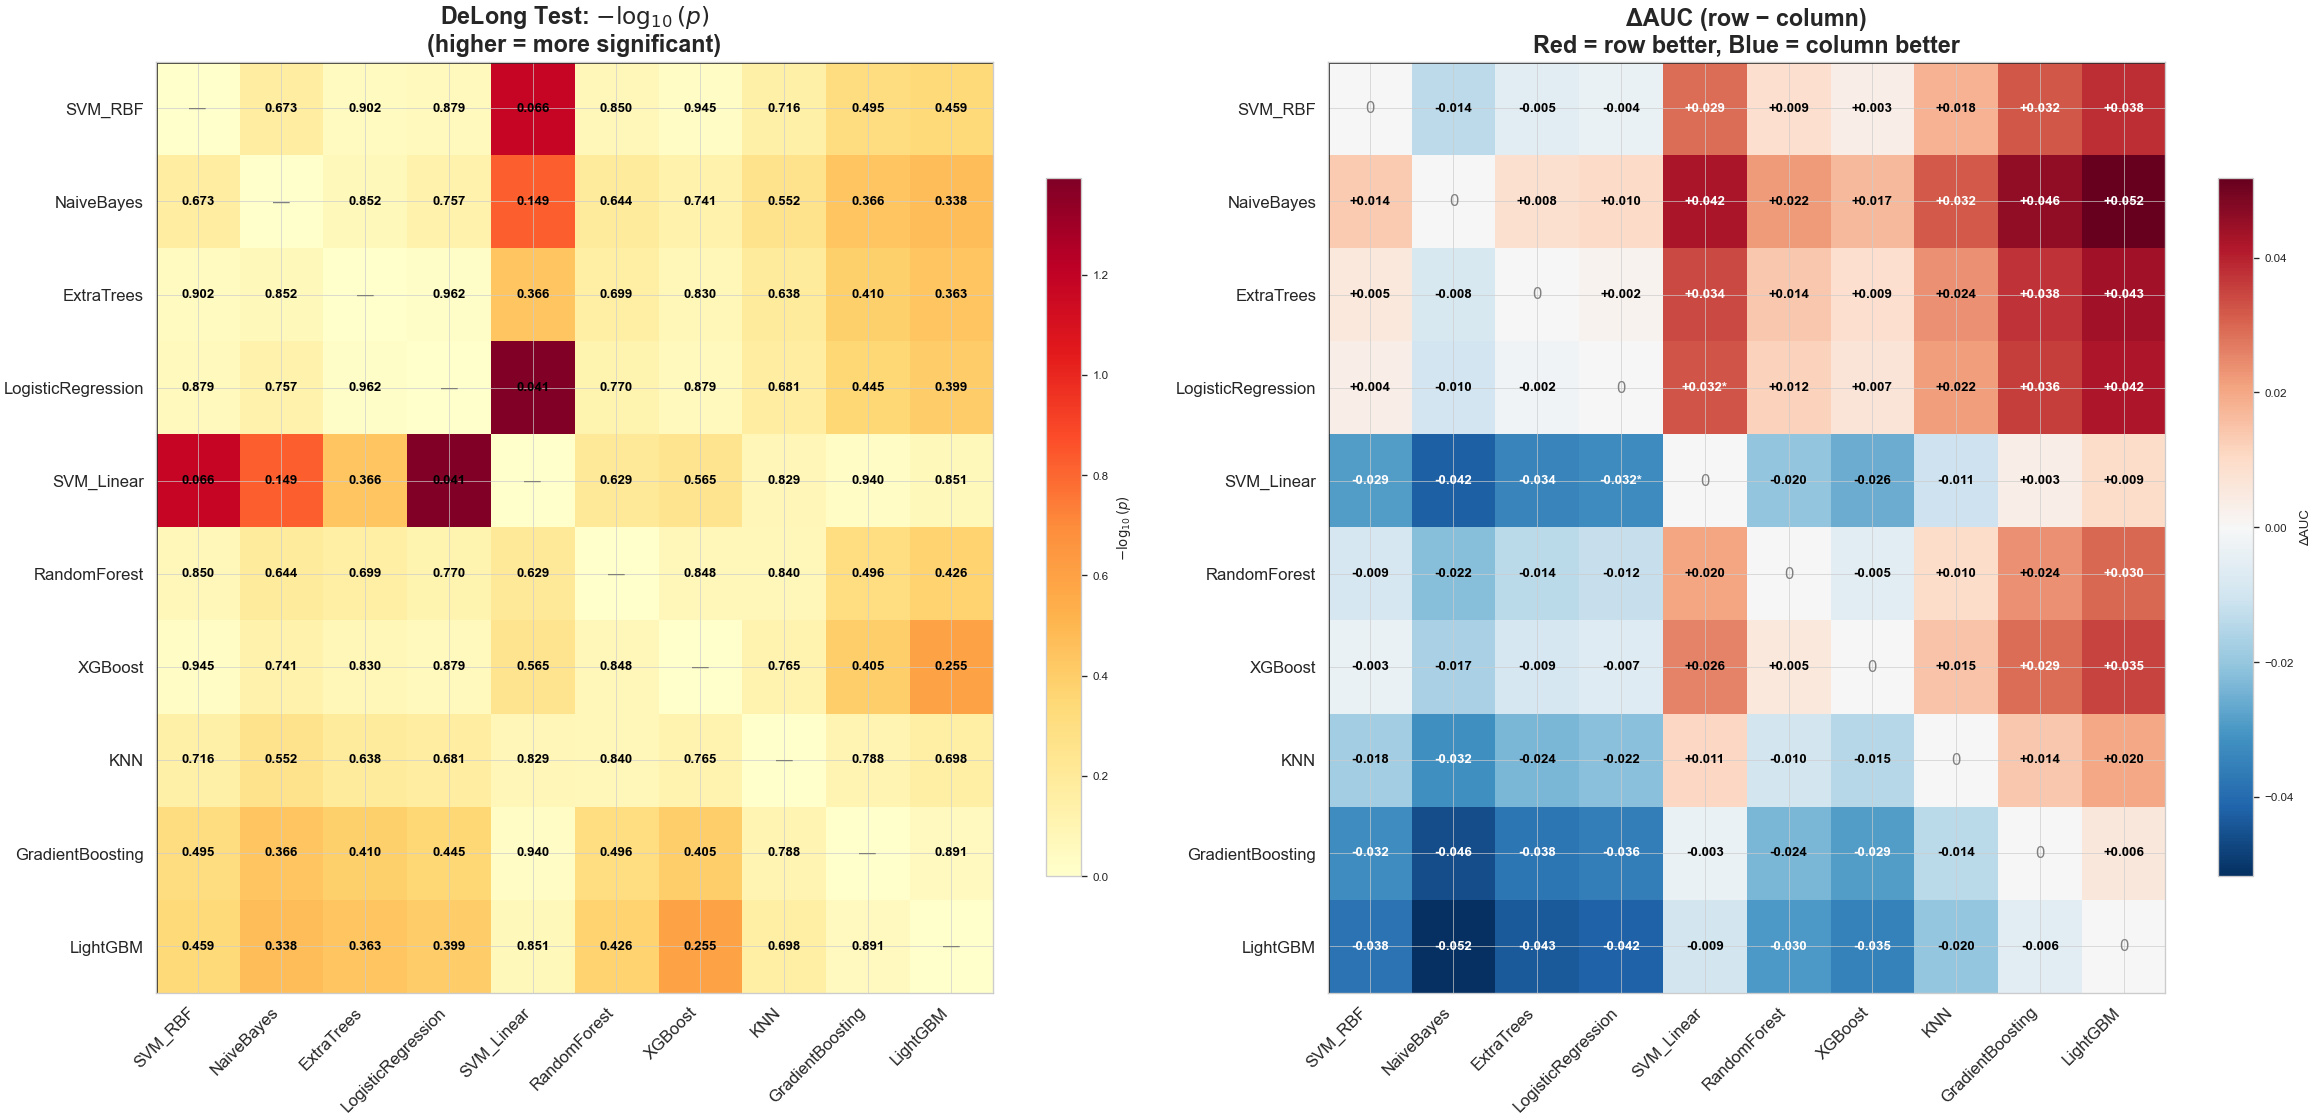


 🏆 Best Model (by Mean AUC): SVM_RBF  (Mean AUC = 0.6225)
 DeLong comparison vs. all other models (sorted by Mean ΔAUC):
        Competitor Competitor_Mean_AUC ΔMean_AUC  p_value p_Bonferroni Significant_uncorrected Significant_Bonferroni
          LightGBM              0.5264   +0.0961 4.59e-01     1.00e+00                       ✗                      ✗
  GradientBoosting              0.5511   +0.0714 4.95e-01     1.00e+00                       ✗                      ✗
               KNN              0.5664   +0.0560 7.16e-01     1.00e+00                       ✗                      ✗
           XGBoost              0.5685   +0.0540 9.45e-01     1.00e+00                       ✗                      ✗
      RandomForest              0.5841   +0.0384 8.50e-01     1.00e+00                       ✗                      ✗
        SVM_Linear              0.5929   +0.0296 6.63e-02     1.00e+00                       ✗                      ✗
LogisticRegression              0.6015   +0.0209 8.7

In [176]:
# =============================================================================
# STATISTICAL INFERENCE VIA DELONG PAIRWISE ROC ANALYSIS
# =============================================================================
# Purpose:
#   - Implement vectorized, fast DeLong test computations for paired ROC curves.
#   - Execute exhaustive pairwise model comparisons with family-wise error rate 
#     control via Bonferroni corrections.
#   - Generate publication-grade diagnostic heatmaps tracking p-values and delta AUCs.
#   - Benchmark the top-performing architecture against all remaining cohorts.
# =============================================================================

import os
import warnings
import itertools
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats

# Enforce strategic default persistence directories if missing from environment context
if 'SAVE_DIR' not in locals() and 'SAVE_DIR' not in globals():
    SAVE_DIR = './nested_cv_outputs'

# -----------------------------------------------------------------------------
# 1. CORE MATH IMPLEMENTATIONS FOR FAST DELONG VECTORIZATION
# -----------------------------------------------------------------------------
def _compute_midrank(x):
    """Computes mathematical midranks for identical entry strings inside vectors."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        midrank = 0.5 * (i + j - 1)
        for k in range(i, j):
            T[k] = midrank
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2


def _fast_delong(predictions_sorted_transposed, label_1_count):
    """Vectorized algorithm mapping structurally unrolled variance-covariance arrays."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tz[r] = _compute_midrank(predictions_sorted_transposed[r])
        tx[r] = _compute_midrank(predictions_sorted_transposed[r, :m])
        ty[r] = _compute_midrank(predictions_sorted_transposed[r, m:])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01) if k > 1 else np.var(v01, ddof=1).reshape(1, 1)
    sy = np.cov(v10) if k > 1 else np.var(v10, ddof=1).reshape(1, 1)

    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_test(y_true, y_prob_1, y_prob_2):
    """Executes the standard DeLong test to evaluate two correlated ROC curves.

    Args:
        y_true (np.ndarray): Target true classification outcomes.
        y_prob_1 (np.ndarray): Probability vectors produced by Model 1.
        y_prob_2 (np.ndarray): Probability vectors produced by Model 2.

    Returns:
        dict: Empirical metrics mapping standalone AUCs, Z-scores, and two-tailed p-values.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob_1 = np.asarray(y_prob_1, dtype=np.float64)
    y_prob_2 = np.asarray(y_prob_2, dtype=np.float64)

    order = (-y_true).argsort()
    y_true_sorted = y_true[order]
    label_1_count = int(y_true_sorted.sum())

    predictions_sorted_transposed = np.vstack([
        y_prob_1[order],
        y_prob_2[order]
    ])

    aucs, delongcov = _fast_delong(predictions_sorted_transposed, label_1_count)

    diff = aucs[0] - aucs[1]
    var_diff = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]

    if var_diff <= 0:
        z_stat = 0.0
        p_value = 1.0
    else:
        z_stat = diff / np.sqrt(var_diff)
        p_value = 2.0 * stats.norm.sf(abs(z_stat))

    return {
        'auc1': aucs[0],
        'auc2': aucs[1],
        'z_stat': z_stat,
        'p_value': p_value,
    }


# -----------------------------------------------------------------------------
# 2. PAIRWISE MODEL MATRIX INFERENCE PROTOCOL
# -----------------------------------------------------------------------------
model_names = (
    df_summary.sort_values('Mean_AUC', ascending=False)['Model']
    .tolist()
)

n_models = len(model_names)

pvalue_matrix = pd.DataFrame(np.ones((n_models, n_models)), index=model_names, columns=model_names)
zstat_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)

comparison_rows = []
ref_y_true = np.array(nested_cv_results[model_names[0]]['y_true'])

for i, j in itertools.combinations(range(n_models), 2):
    m1, m2 = model_names[i], model_names[j]

    y_true_1 = np.array(nested_cv_results[m1]['y_true'])
    y_true_2 = np.array(nested_cv_results[m2]['y_true'])
    y_prob_1 = np.array(nested_cv_results[m1]['y_prob'])
    y_prob_2 = np.array(nested_cv_results[m2]['y_prob'])

    assert np.array_equal(y_true_1, y_true_2), f"y_true mismatch between {m1} and {m2}!"

    result = delong_roc_test(y_true_1, y_prob_1, y_prob_2)

    pvalue_matrix.loc[m1, m2] = result['p_value']
    pvalue_matrix.loc[m2, m1] = result['p_value']
    zstat_matrix.loc[m1, m2] = result['z_stat']
    zstat_matrix.loc[m2, m1] = -result['z_stat']

    comparison_rows.append({
        'Model_A': m1,
        'Model_B': m2,
        'AUC_A': result['auc1'],
        'AUC_B': result['auc2'],
        'ΔAUC': result['auc1'] - result['auc2'],
        'Z_stat': result['z_stat'],
        'p_value': result['p_value'],
        'Significant (α=0.05)': '✓' if result['p_value'] < 0.05 else '✗',
        'Significant (α=0.01)': '✓' if result['p_value'] < 0.01 else '✗',
    })

df_delong = pd.DataFrame(comparison_rows)
df_delong = df_delong.sort_values('p_value').reset_index(drop=True)

# Enforce rigid Family-Wise Error Rate control using Bonferroni Adjustments
n_comparisons = len(comparison_rows)
df_delong['p_value_bonferroni'] = np.minimum(df_delong['p_value'] * n_comparisons, 1.0)
df_delong['Significant Bonf. (α=0.05)'] = df_delong['p_value_bonferroni'].apply(lambda p: '✓' if p < 0.05 else '✗')


# --- Display Tabular Outputs -------------------------------------------------
print("=" * 90)
print("  DeLong Pairwise AUC Comparison — All Model Pairs")
print("=" * 90)
df_display = df_delong.copy()
df_display['AUC_A'] = df_display['AUC_A'].map('{:.4f}'.format)
df_display['AUC_B'] = df_display['AUC_B'].map('{:.4f}'.format)
df_display['ΔAUC'] = df_display['ΔAUC'].map('{:+.4f}'.format)
df_display['Z_stat'] = df_display['Z_stat'].map('{:.3f}'.format)
df_display['p_value'] = df_display['p_value'].map('{:.2e}'.format)
df_display['p_value_bonferroni'] = df_display['p_value_bonferroni'].map('{:.2e}'.format)
print(df_display.to_string(index=False))

n_sig_005 = (df_delong['p_value'] < 0.05).sum()
n_sig_001 = (df_delong['p_value'] < 0.01).sum()
n_sig_bonf = (df_delong['p_value_bonferroni'] < 0.05).sum()

print(f"\n📊 Summary: {n_comparisons} pairwise comparisons")
print(f"   • Significant at α=0.05:              {n_sig_005}/{n_comparisons}")
print(f"   • Significant at α=0.01:              {n_sig_001}/{n_comparisons}")
print(f"   • Significant after Bonferroni (0.05): {n_sig_bonf}/{n_comparisons}")


# -----------------------------------------------------------------------------
# 3. HIGH-RESOLUTION PRESENTATION HEATMAP GENERATION (DPI 900)
# -----------------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    fig, axes = plt.subplots(1, 2, figsize=(20, 9.5))

    # --- Heatmap Panel A: -log10(p-value) Magnitude Mapping ---
    log_pval = -np.log10(pvalue_matrix.values.astype(float) + 1e-300)
    np.fill_diagonal(log_pval, 0)

    im1 = axes[0].imshow(log_pval, cmap='YlOrRd', aspect='auto')
    axes[0].set_xticks(range(n_models))
    axes[0].set_yticks(range(n_models))
    axes[0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[0].set_yticklabels(model_names, fontsize=10)
    axes[0].set_title('DeLong Test: $-\\log_{10}(p)$\n(higher = more significant)', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                pval = pvalue_matrix.iloc[ii, jj]
                txt = f'{pval:.1e}' if pval < 0.001 else f'{pval:.3f}'
                color = 'white' if log_pval[ii, jj] > 2 else 'black'
                axes[0].text(jj, ii, txt, ha='center', va='center', fontsize=8, color=color, fontweight='bold')
            else:
                axes[0].text(jj, ii, '—', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im1, ax=axes[0], shrink=0.75, label='$-\\log_{10}(p)$')

    # --- Heatmap Panel B: Unrolled Delta AUC Directional Matrix ---
    auc_diff_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)
    for _, row in df_delong.iterrows():
        m1, m2 = row['Model_A'], row['Model_B']
        d = float(row['ΔAUC'])
        auc_diff_matrix.loc[m1, m2] = d
        auc_diff_matrix.loc[m2, m1] = -d

    max_abs = max(abs(auc_diff_matrix.values.min()), abs(auc_diff_matrix.values.max()), 0.01)
    im2 = axes[1].imshow(auc_diff_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-max_abs, vmax=max_abs)
    axes[1].set_xticks(range(n_models))
    axes[1].set_yticks(range(n_models))
    axes[1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[1].set_yticklabels(model_names, fontsize=10)
    axes[1].set_title('ΔAUC (row − column)\nRed = row better, Blue = column better', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                val = auc_diff_matrix.iloc[ii, jj]
                pval = pvalue_matrix.iloc[ii, jj]
                star = '*' if pval < 0.05 else ''
                txt = f'{val:+.3f}{star}'
                axes[1].text(jj, ii, txt, ha='center', va='center', fontsize=8,
                             color='white' if abs(val) > max_abs * 0.5 else 'black', fontweight='bold')
            else:
                axes[1].text(jj, ii, '0', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im2, ax=axes[1], shrink=0.75, label='ΔAUC')

    for ax in axes:
        ax.axhline(y=-0.5, color='black', linewidth=1.5)
        ax.axvline(x=-0.5, color='black', linewidth=1.5)

    plt.tight_layout()
    
    os.makedirs(SAVE_DIR, exist_ok=True)
    heatmap_save_path = os.path.join(SAVE_DIR, 'delong_pairwise_heatmap.png')
    plt.savefig(heatmap_save_path, dpi=600, bbox_inches='tight')
    print(f"\n💾 High-resolution heatmap (DPI 900) saved to: {heatmap_save_path}")
    plt.show()
    plt.close()

except ImportError:
    print("\n⚠️ matplotlib not available — skipping heatmap visualisation.")


# -----------------------------------------------------------------------------
# 4. CRITICAL CHRONOLOGICAL ANALYSIS: CHOSEN CHAMPION VS INDEPENDENT COHORTS
# -----------------------------------------------------------------------------
mean_aucs = {}
for mn in model_names:
    try:
        # Compute baseline criteria mapping directly on Cross-Validation Fold means
        mean_aucs[mn] = np.mean(nested_cv_results[mn]['fold_aucs'])
    except Exception:
        mean_aucs[mn] = 0.5

# Extract optimal model design index relying exclusively on structural Mean AUC performance
best_model = df_summary.sort_values('Mean_AUC', ascending=False).iloc[0]['Model']
best_auc = mean_aucs[best_model]

print(f"\n{'=' * 70}")
print(f" 🏆 Best Model (by Mean AUC): {best_model}  (Mean AUC = {best_auc:.4f})")
print(f" DeLong comparison vs. all other models (sorted by Mean ΔAUC):")
print(f"{'=' * 70}")



best_vs_rest = []
for mn in model_names:
    if mn == best_model:
        continue
    
    # Query paired historical database rows matching target experimental configurations
    row_data = df_delong[
        ((df_delong['Model_A'] == best_model) & (df_delong['Model_B'] == mn)) |
        ((df_delong['Model_A'] == mn) & (df_delong['Model_B'] == best_model))
    ]
    
    if len(row_data) > 0:
        row = row_data.iloc[0]
        p_val = row['p_value']
        p_bonf = row['p_value_bonferroni']
    else:
        p_val, p_bonf = 1.0, 1.0

    # Calculate absolute delta values using standalone Mean AUC frame locations
    delta = best_auc - mean_aucs[mn]
    
    best_vs_rest.append({
        'Competitor': mn,
        'Competitor_Mean_AUC': mean_aucs[mn],
        'ΔMean_AUC': delta,
        'p_value': p_val,
        'p_Bonferroni': p_bonf,
        'Significant_uncorrected': '✓' if p_val < 0.05 else '✗',
        'Significant_Bonferroni': '✓' if p_bonf < 0.05 else '✗',
    })

# Format and rank baseline comparisons sequentially from largest to minimal delta deviations
df_best_vs_rest = pd.DataFrame(best_vs_rest).sort_values('ΔMean_AUC', ascending=False).reset_index(drop=True)
df_best_vs_rest['Competitor_Mean_AUC'] = df_best_vs_rest['Competitor_Mean_AUC'].map('{:.4f}'.format)
df_best_vs_rest['ΔMean_AUC'] = df_best_vs_rest['ΔMean_AUC'].map('{:+.4f}'.format)
df_best_vs_rest['p_value'] = df_best_vs_rest['p_value'].map('{:.2e}'.format)
df_best_vs_rest['p_Bonferroni'] = df_best_vs_rest['p_Bonferroni'].map('{:.2e}'.format)



df_delong.to_csv(os.path.join(SAVE_DIR, 'df_delong_pairwise.csv'), index=False)
pvalue_matrix.to_csv(os.path.join(SAVE_DIR, 'delong_pvalue_matrix.csv'))
zstat_matrix.to_csv(os.path.join(SAVE_DIR, 'delong_zstat_matrix.csv'))
df_best_vs_rest.to_csv(os.path.join(SAVE_DIR, 'delong_best_vs_rest.csv'), index=False)



print(df_best_vs_rest.to_string(index=False))
print("\n✅ DeLong analysis complete.")

In [177]:
    # =============================================================================
    # STEP 4C — LASSO-ONLY VS BASELINE STATISTICAL COMPARISON
    # =============================================================================
    # Purpose:
    #   - Compare LASSO-only FS against the Step 2 baseline.
    #   - Keep analysis compact and manuscript-style.
    #   - Generate non-redundant plots:
    #       1) ROC-AUC delta by model
    #       2) Best ROC curves
    #       3) Fold-wise AUC paired change
    #       4) LASSO feature-selection stability
    #       5) Metric trade-off for best changed model
    # =============================================================================


current_fs_method = CONFIG.get("FS_METHOD", None)

if current_fs_method != "lasso_only":
    print("█" * 80)
    print("  STEP 4C — SKIPPED")
    print("█" * 80)
    print("This cell is only for FS_METHOD='lasso_only'.")
    print(f"Current FS_METHOD is: {current_fs_method}")
    print("No LASSO-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 4C — LASSO-ONLY VS BASELINE COMPARISON")
    print("█" * 80)
    

    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        "./nested_cv_outputs",
        "step_2_baseline_nested_cv_no_smote"
    )

    lasso_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join("./nested_cv_outputs", "step_4_lasso_only_fs_nested_cv_no_smote")
    )

    comparison_dir = os.path.join(lasso_dir, "step_4c_lasso_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline results not found:\n{baseline_pkl_path}\n"
            "Run Step 2 baseline first."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current LASSO nested_cv_results not found. Run Cell 13 after Step 4B.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    lasso_results = nested_cv_results

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current LASSO results from:\n  {lasso_dir}")

    # -----------------------------------------------------------------------------
    # 2. Publication-style plotting theme
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "lasso": "#2A9D8F",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "dark": "#2F3E46",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        """
        Paired bootstrap CI for delta = metric_b - metric_a.
        Here:
            a = baseline
            b = LASSO
        """
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute metrics
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    lasso_metrics_df = pooled_metrics_from_results(lasso_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    lasso_metrics_df.to_csv(
        os.path.join(comparison_dir, "lasso_only_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(lasso_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        l_row = lasso_metrics_df[lasso_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        l_res = lasso_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        l_y_true = np.asarray(l_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(l_y_true)
            and np.array_equal(b_y_true, l_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(l_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(l_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        l_fold_auc = np.asarray(l_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(l_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    l_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "LASSO_ROC_AUC": l_row["ROC_AUC"],
            "Delta_ROC_AUC_LASSO_minus_Baseline": l_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "LASSO_PR_AUC": l_row["PR_AUC"],
            "Delta_PR_AUC_LASSO_minus_Baseline": l_row["PR_AUC"] - b_row["PR_AUC"],
            "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

            "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
            "LASSO_Balanced_Accuracy": l_row["Balanced_Accuracy"],
            "Delta_Balanced_Accuracy": l_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "LASSO_Sensitivity": l_row["Sensitivity"],
            "Delta_Sensitivity": l_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "LASSO_Specificity": l_row["Specificity"],
            "Delta_Specificity": l_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "LASSO_PPV": l_row["PPV"],
            "Delta_PPV": l_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "LASSO_NPV": l_row["NPV"],
            "Delta_NPV": l_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "LASSO_Kappa": l_row["Cohen_Kappa"],
            "Delta_Kappa": l_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "LASSO_Brier": l_row["Brier_Score"],
            "Delta_Brier_LASSO_minus_Baseline": l_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "LASSO_Mean_Selected_Features": l_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_LASSO_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "lasso_only_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("LASSO-ONLY VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "LASSO_ROC_AUC",
        "Delta_ROC_AUC_LASSO_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "LASSO_PR_AUC",
        "Delta_PR_AUC_LASSO_minus_Baseline",
        "Baseline_Sensitivity",
        "LASSO_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "LASSO_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_lasso_model = lasso_metrics_df.iloc[0]["Model"]
    best_delta_model = comparison_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best LASSO model:   ", best_lasso_model)
    print("Largest ROC-AUC gain with LASSO:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 4. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.sort_values(
        "Delta_ROC_AUC_LASSO_minus_Baseline",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_LASSO_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_LASSO_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of LASSO Feature Selection")
    ax.set_xlabel("Δ ROC-AUC: LASSO − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_lasso_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 5. Figure 2 — Best ROC curves
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    l_res = lasso_results[best_lasso_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    l_y_true = np.asarray(l_res["y_true"], dtype=int)
    l_y_prob = np.asarray(l_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    l_fpr, l_tpr, _ = roc_curve(l_y_true, l_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    l_auc = roc_auc_score(l_y_true, l_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        l_fpr,
        l_tpr,
        linewidth=1.4,
        color=COLORS["lasso"],
        label=f"LASSO: {best_lasso_model} ({l_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig02_best_baseline_vs_lasso_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 3 — Fold-wise AUC paired change for best delta model
    # -----------------------------------------------------------------------------
    b_fold_auc = np.asarray(baseline_results[best_delta_model]["fold_aucs"], dtype=float)
    l_fold_auc = np.asarray(lasso_results[best_delta_model]["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(l_fold_auc):
        fig, ax = plt.subplots(figsize=(3.8, 2.8))

        for i in range(len(b_fold_auc)):
            ax.plot(
                [0, 1],
                [b_fold_auc[i], l_fold_auc[i]],
                marker="o",
                linewidth=0.9,
                color=COLORS["neutral"],
                alpha=0.8
            )

        ax.scatter(
            np.zeros_like(b_fold_auc),
            b_fold_auc,
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="Baseline"
        )

        ax.scatter(
            np.ones_like(l_fold_auc),
            l_fold_auc,
            color=COLORS["lasso"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="LASSO"
        )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "LASSO"])
        ax.set_ylim(0, 1)
        ax.set_title(f"Outer-fold ROC-AUC Change — {best_delta_model}")
        ax.set_ylabel("Fold ROC-AUC")
        ax.legend(frameon=False, loc="best")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig03_outer_fold_auc_paired_change_lasso")
        plt.show()

    # -----------------------------------------------------------------------------
    # 7. Figure 4 — LASSO feature selection stability
    # -----------------------------------------------------------------------------
    lasso_features_path = os.path.join(lasso_dir, "df_selected_features_long.csv")

    if os.path.exists(lasso_features_path):
        lasso_feat = pd.read_csv(lasso_features_path)

        lasso_stability = (
            lasso_feat
            .groupby("Feature_Name")
            .size()
            .reset_index(name="Selection_Count")
            .sort_values("Selection_Count", ascending=False)
        )

        lasso_stability["Selection_Frequency"] = (
            lasso_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        lasso_stability.to_csv(
            os.path.join(comparison_dir, "lasso_feature_selection_stability.csv"),
            index=False
        )

        top_lasso_stable = lasso_stability.head(12).iloc[::-1]

        fig, ax = plt.subplots(figsize=(4.8, 3.3))

        ax.barh(
            top_lasso_stable["Feature_Name"],
            top_lasso_stable["Selection_Frequency"],
            color=COLORS["lasso"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_xlim(0, 1)
        ax.set_title("LASSO Feature Stability")
        ax.set_xlabel("Selection frequency across outer folds")
        ax.set_ylabel("")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig04_lasso_feature_selection_stability")
        plt.show()
    else:
        lasso_stability = pd.DataFrame()
        print("\nLASSO selected-feature file not found; stability plot skipped.")

    # -----------------------------------------------------------------------------
    # 8. Feature overlap: Baseline vs LASSO
    # -----------------------------------------------------------------------------
    baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")

    overlap_summary = {}

    if os.path.exists(baseline_features_path) and os.path.exists(lasso_features_path):
        b_feat = pd.read_csv(baseline_features_path)
        l_feat = pd.read_csv(lasso_features_path)

        b_set = set(b_feat["Feature_Name"].unique())
        l_set = set(l_feat["Feature_Name"].unique())

        intersection = b_set.intersection(l_set)
        union = b_set.union(l_set)

        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

        overlap_summary = {
            "baseline_unique_features": int(len(b_set)),
            "lasso_unique_features": int(len(l_set)),
            "shared_features": int(len(intersection)),
            "union_features": int(len(union)),
            "jaccard_overlap": float(jaccard)
        }

        pd.DataFrame([overlap_summary]).to_csv(
            os.path.join(comparison_dir, "baseline_vs_lasso_feature_overlap.csv"),
            index=False
        )

        print("\n" + "═" * 80)
        print("FEATURE OVERLAP SUMMARY")
        print("═" * 80)
        for k, v in overlap_summary.items():
            print(f"{k}: {v}")

    # -----------------------------------------------------------------------------
    # 9. Figure 5 — Metric trade-off for best delta model
    # -----------------------------------------------------------------------------
    trade_model = best_delta_model
    trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

    trade_df = pd.DataFrame({
        "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
        "Baseline": [
            trade_row["Baseline_Sensitivity"],
            trade_row["Baseline_Specificity"],
            trade_row["Baseline_PPV"],
            trade_row["Baseline_NPV"],
            trade_row["Baseline_Kappa"]
        ],
        "LASSO": [
            trade_row["LASSO_Sensitivity"],
            trade_row["LASSO_Specificity"],
            trade_row["LASSO_PPV"],
            trade_row["LASSO_NPV"],
            trade_row["LASSO_Kappa"]
        ]
    })

    trade_df.to_csv(
        os.path.join(comparison_dir, "best_delta_model_lasso_metric_tradeoff.csv"),
        index=False
    )

    x = np.arange(len(trade_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(4.8, 2.9))

    ax.bar(
        x - width / 2,
        trade_df["Baseline"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        trade_df["LASSO"],
        width,
        label="LASSO",
        color=COLORS["lasso"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Trade-off — {trade_model}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig05_lasso_metric_tradeoff_best_delta_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 10. Decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_LASSO_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_LASSO_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_LASSO_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "LASSO favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "LASSO improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    lasso_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    lasso_decision_df.to_csv(
        os.path.join(comparison_dir, "lasso_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("LASSO ABLATION DECISION TABLE")
    print("═" * 80)
    print(lasso_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 11. Compact summary JSON
    # -----------------------------------------------------------------------------
    step_4c_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_4_lasso_only_fs_nested_cv_no_smote"),
        "baseline_dir": baseline_dir,
        "lasso_dir": lasso_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_lasso_model_by_roc_auc": best_lasso_model,
        "best_lasso_roc_auc": float(lasso_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_LASSO_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
        "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
        "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
        "n_models_compared": int(len(common_models)),
        "feature_overlap_summary": overlap_summary
    }

    with open(os.path.join(comparison_dir, "step_4c_summary.json"), "w") as f:
        json.dump(step_4c_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 4C SUMMARY")
    print("═" * 80)

    for k, v in step_4c_summary.items():
        print(f"{k}: {v}")

    print("\nSaved LASSO comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 4C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 4C — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for FS_METHOD='lasso_only'.
Current FS_METHOD is: boruta_like
No LASSO-vs-baseline comparison was executed.


In [178]:
# =============================================================================
# STEP 5B — RFE-ONLY FEATURE SELECTION CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run a controlled RFE-only feature selection ablation.
#   - Keep SMOTE disabled to isolate the effect of feature selection.
# =============================================================================

print("█" * 80)
print("  STEP 5B — RFE-ONLY CONFIGURATION LOCK")
print("█" * 80)

import os
import json

CONFIG["RUN_NAME"] = "step_5_rfe_only_fs_nested_cv_no_smote"
CONFIG["SAVE_DIR"] = os.path.join(
    "./nested_cv_outputs",
    CONFIG["RUN_NAME"]
)

os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# Isolate feature-selection effect
# CONFIG["USE_SMOTE"] = False

# CONFIG["FS_METHOD"] = "rfe_only"

# Keep same feature count as baseline/LASSO
CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

# RFE-specific settings
CONFIG["RFE_STEP"] = 0.10
CONFIG["RFE_C"] = 1.0

# Keep nested CV fixed
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

rfe_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "RFE_STEP": CONFIG["RFE_STEP"],
    "RFE_C": CONFIG["RFE_C"],
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups)))
}

with open(os.path.join(CONFIG["SAVE_DIR"], "rfe_only_config_snapshot.json"), "w") as f:
    json.dump(rfe_config_snapshot, f, indent=4)

print("\nRFE-only configuration:")
for k, v in rfe_config_snapshot.items():
    print(f"  {k}: {v}")

print("\n✅ STEP 5B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 5B — RFE-ONLY CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████

RFE-only configuration:
  RUN_NAME: step_5_rfe_only_fs_nested_cv_no_smote
  SAVE_DIR: ./nested_cv_outputs/step_5_rfe_only_fs_nested_cv_no_smote
  USE_SMOTE: False
  FS_METHOD: boruta_like
  FS_N_FEATURES: 16
  RFE_STEP: 0.1
  RFE_C: 1.0
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 20
  RANDOM_STATE: 100
  N_SAMPLES: 117
  N_FEATURES: 145
  N_PATIENTS: 48

✅ STEP 5B completed successfully.


In [179]:
    # =============================================================================
    # STEP 5C — RFE-ONLY VS BASELINE STATISTICAL COMPARISON
    # =============================================================================
    # Purpose:
    #   - Compare RFE-only FS against Step 2 baseline.
    #   - Use compact non-redundant manuscript-style figures.
    # =============================================================================
current_fs_method = CONFIG.get("FS_METHOD", None)

if current_fs_method != "rfe_only":
    print("█" * 80)
    print("  STEP 5C — SKIPPED")
    print("█" * 80)
    print("This cell is only for FS_METHOD='rfe_only'.")
    print(f"Current FS_METHOD is: {current_fs_method}")
    print("No RFE-vs-baseline comparison was executed.")

else:
    print("█" * 80)
    print("  STEP 5C — RFE-ONLY VS BASELINE COMPARISON")
    print("█" * 80)


    import os
    import json
    import pickle
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from scipy.stats import wilcoxon

    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        accuracy_score,
        balanced_accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        cohen_kappa_score,
        brier_score_loss,
        roc_curve
    )

    warnings.filterwarnings("ignore")

    # -----------------------------------------------------------------------------
    # 1. Paths
    # -----------------------------------------------------------------------------
    baseline_dir = os.path.join(
        "./nested_cv_outputs",
        "step_2_baseline_nested_cv_no_smote"
    )

    rfe_dir = CONFIG.get(
        "SAVE_DIR",
        os.path.join("./nested_cv_outputs", "step_5_rfe_only_fs_nested_cv_no_smote")
    )

    comparison_dir = os.path.join(rfe_dir, "step_5c_rfe_vs_baseline_reports")
    plot_dir = os.path.join(comparison_dir, "plots_publication_style")

    os.makedirs(comparison_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

    if not os.path.exists(baseline_pkl_path):
        raise FileNotFoundError(
            f"Baseline results not found:\n{baseline_pkl_path}\n"
            "Run Step 2 baseline first."
        )

    if "nested_cv_results" not in globals():
        raise RuntimeError("Current RFE nested_cv_results not found. Run Cell 13 after Step 5B.")

    with open(baseline_pkl_path, "rb") as f:
        baseline_results = pickle.load(f)

    rfe_results = nested_cv_results

    print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
    print(f"Using current RFE results from:\n  {rfe_dir}")

    # -----------------------------------------------------------------------------
    # 2. Publication-style plotting theme
    # -----------------------------------------------------------------------------
    plt.style.use("default")

    FIG_DPI = 600

    COLORS = {
        "baseline": "#4C78A8",
        "rfe": "#7B2CBF",
        "delta_pos": "#2A9D8F",
        "delta_neg": "#B23A48",
        "dark": "#2F3E46",
        "neutral": "#6C757D",
        "grid": "#D9DEE3"
    }

    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": FIG_DPI,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "#333333",
        "axes.grid": True,
        "grid.color": COLORS["grid"],
        "grid.linewidth": 0.5,
        "grid.alpha": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


    def clean_axis(ax, grid_axis="y"):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)


    def save_figure(fig, filename_base):
        png_path = os.path.join(plot_dir, f"{filename_base}.png")
        pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
        fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved: {png_path}")
        print(f"Saved: {pdf_path}")


    def compute_specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan


    def compute_npv(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fn) if (tn + fn) > 0 else np.nan


    def benjamini_hochberg(p_values):
        p_values = np.asarray(p_values, dtype=float)
        q_values = np.full(len(p_values), np.nan)

        valid = np.isfinite(p_values)
        p = p_values[valid]

        if len(p) == 0:
            return q_values

        order = np.argsort(p)
        ranked = p[order]
        adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
        adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
        adjusted = np.clip(adjusted, 0, 1)

        q_valid = np.empty_like(p)
        q_valid[order] = adjusted
        q_values[valid] = q_valid

        return q_values


    def pooled_metrics_from_results(results_dict):
        rows = []

        for model_name, res in results_dict.items():
            y_true = np.asarray(res["y_true"], dtype=int)
            y_prob = np.asarray(res["y_prob"], dtype=float)
            y_pred = np.asarray(res["y_pred"], dtype=int)

            rows.append({
                "Model": model_name,
                "ROC_AUC": roc_auc_score(y_true, y_prob),
                "PR_AUC": average_precision_score(y_true, y_prob),
                "Accuracy": accuracy_score(y_true, y_pred),
                "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
                "Specificity": compute_specificity(y_true, y_pred),
                "PPV": precision_score(y_true, y_pred, zero_division=0),
                "NPV": compute_npv(y_true, y_pred),
                "F1": f1_score(y_true, y_pred, zero_division=0),
                "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
                "Brier_Score": brier_score_loss(y_true, y_prob),
                "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
                "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
            })

        return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


    def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
        """
        Paired bootstrap CI for delta = metric_b - metric_a.
        Here:
            a = baseline
            b = RFE
        """
        rng = np.random.default_rng(seed)

        y_true = np.asarray(y_true, dtype=int)
        prob_a = np.asarray(prob_a, dtype=float)
        prob_b = np.asarray(prob_b, dtype=float)

        n = len(y_true)
        deltas = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            try:
                val_a = metric_func(y_true[idx], prob_a[idx])
                val_b = metric_func(y_true[idx], prob_b[idx])
                deltas.append(val_b - val_a)
            except Exception:
                continue

        if len(deltas) == 0:
            return np.nan, np.nan, np.nan

        deltas = np.asarray(deltas, dtype=float)

        return (
            float(np.nanmean(deltas)),
            float(np.nanpercentile(deltas, 2.5)),
            float(np.nanpercentile(deltas, 97.5))
        )


    # -----------------------------------------------------------------------------
    # 3. Compute metrics
    # -----------------------------------------------------------------------------
    baseline_metrics_df = pooled_metrics_from_results(baseline_results)
    rfe_metrics_df = pooled_metrics_from_results(rfe_results)

    baseline_metrics_df.to_csv(
        os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
        index=False
    )

    rfe_metrics_df.to_csv(
        os.path.join(comparison_dir, "rfe_only_pooled_metrics.csv"),
        index=False
    )

    common_models = sorted(set(baseline_metrics_df["Model"]).intersection(rfe_metrics_df["Model"]))

    comparison_rows = []

    for model_name in common_models:
        b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
        r_row = rfe_metrics_df[rfe_metrics_df["Model"] == model_name].iloc[0]

        b_res = baseline_results[model_name]
        r_res = rfe_results[model_name]

        b_y_true = np.asarray(b_res["y_true"], dtype=int)
        r_y_true = np.asarray(r_res["y_true"], dtype=int)

        same_oof_order = (
            len(b_y_true) == len(r_y_true)
            and np.array_equal(b_y_true, r_y_true)
        )

        if same_oof_order:
            auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(r_res["y_prob"], dtype=float),
                roc_auc_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100)
            )

            pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
                b_y_true,
                np.asarray(b_res["y_prob"], dtype=float),
                np.asarray(r_res["y_prob"], dtype=float),
                average_precision_score,
                n_boot=2000,
                seed=CONFIG.get("RANDOM_STATE", 100) + 1
            )
        else:
            auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
            pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

        b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
        r_fold_auc = np.asarray(r_res["fold_aucs"], dtype=float)

        if len(b_fold_auc) == len(r_fold_auc) and len(b_fold_auc) >= 2:
            try:
                w_stat, w_p = wilcoxon(
                    r_fold_auc,
                    b_fold_auc,
                    alternative="two-sided",
                    zero_method="wilcox"
                )
            except Exception:
                w_stat, w_p = np.nan, np.nan
        else:
            w_stat, w_p = np.nan, np.nan

        comparison_rows.append({
            "Model": model_name,

            "Baseline_ROC_AUC": b_row["ROC_AUC"],
            "RFE_ROC_AUC": r_row["ROC_AUC"],
            "Delta_ROC_AUC_RFE_minus_Baseline": r_row["ROC_AUC"] - b_row["ROC_AUC"],
            "Paired_Bootstrap_Delta_ROC_AUC_Mean": auc_delta_mean,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
            "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

            "Baseline_PR_AUC": b_row["PR_AUC"],
            "RFE_PR_AUC": r_row["PR_AUC"],
            "Delta_PR_AUC_RFE_minus_Baseline": r_row["PR_AUC"] - b_row["PR_AUC"],
            "Paired_Bootstrap_Delta_PR_AUC_Mean": pr_delta_mean,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_Low": pr_delta_low,
            "Paired_Bootstrap_Delta_PR_AUC_CI95_High": pr_delta_high,

            "Baseline_Balanced_Accuracy": b_row["Balanced_Accuracy"],
            "RFE_Balanced_Accuracy": r_row["Balanced_Accuracy"],
            "Delta_Balanced_Accuracy": r_row["Balanced_Accuracy"] - b_row["Balanced_Accuracy"],

            "Baseline_Sensitivity": b_row["Sensitivity"],
            "RFE_Sensitivity": r_row["Sensitivity"],
            "Delta_Sensitivity": r_row["Sensitivity"] - b_row["Sensitivity"],

            "Baseline_Specificity": b_row["Specificity"],
            "RFE_Specificity": r_row["Specificity"],
            "Delta_Specificity": r_row["Specificity"] - b_row["Specificity"],

            "Baseline_PPV": b_row["PPV"],
            "RFE_PPV": r_row["PPV"],
            "Delta_PPV": r_row["PPV"] - b_row["PPV"],

            "Baseline_NPV": b_row["NPV"],
            "RFE_NPV": r_row["NPV"],
            "Delta_NPV": r_row["NPV"] - b_row["NPV"],

            "Baseline_Kappa": b_row["Cohen_Kappa"],
            "RFE_Kappa": r_row["Cohen_Kappa"],
            "Delta_Kappa": r_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

            "Baseline_Brier": b_row["Brier_Score"],
            "RFE_Brier": r_row["Brier_Score"],
            "Delta_Brier_RFE_minus_Baseline": r_row["Brier_Score"] - b_row["Brier_Score"],

            "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
            "RFE_Mean_Selected_Features": r_row["Mean_Selected_Features"],

            "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
            "Foldwise_Wilcoxon_AUC_p_value": w_p,
            "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
        })

    comparison_df = pd.DataFrame(comparison_rows)

    comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
        comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
    )

    comparison_df = comparison_df.sort_values(
        "Delta_ROC_AUC_RFE_minus_Baseline",
        ascending=False
    ).reset_index(drop=True)

    comparison_df.to_csv(
        os.path.join(comparison_dir, "rfe_only_vs_baseline_model_comparison.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("RFE-ONLY VS BASELINE — MODEL COMPARISON")
    print("═" * 80)

    display_cols = [
        "Model",
        "Baseline_ROC_AUC",
        "RFE_ROC_AUC",
        "Delta_ROC_AUC_RFE_minus_Baseline",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
        "Baseline_PR_AUC",
        "RFE_PR_AUC",
        "Delta_PR_AUC_RFE_minus_Baseline",
        "Baseline_Sensitivity",
        "RFE_Sensitivity",
        "Delta_Sensitivity",
        "Baseline_Specificity",
        "RFE_Specificity",
        "Delta_Specificity",
        "Foldwise_Wilcoxon_AUC_p_value",
        "Foldwise_Wilcoxon_AUC_q_value_FDR"
    ]

    print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

    best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
    best_rfe_model = rfe_metrics_df.iloc[0]["Model"]
    best_delta_model = comparison_df.iloc[0]["Model"]

    print("\nBest baseline model:", best_baseline_model)
    print("Best RFE model:     ", best_rfe_model)
    print("Largest ROC-AUC gain with RFE:", best_delta_model)

    # -----------------------------------------------------------------------------
    # 4. Figure 1 — ROC-AUC delta by model
    # -----------------------------------------------------------------------------
    delta_plot = comparison_df.sort_values(
        "Delta_ROC_AUC_RFE_minus_Baseline",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(4.8, 3.0))

    bar_colors = [
        COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
        for v in delta_plot["Delta_ROC_AUC_RFE_minus_Baseline"]
    ]

    ax.barh(
        delta_plot["Model"],
        delta_plot["Delta_ROC_AUC_RFE_minus_Baseline"],
        color=bar_colors,
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.axvline(0, color="#222222", linewidth=0.8)
    ax.set_title("Effect of RFE Feature Selection")
    ax.set_xlabel("Δ ROC-AUC: RFE − Baseline")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig01_rfe_delta_roc_auc_by_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 5. Figure 2 — Best ROC curves
    # -----------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(3.8, 3.4))

    b_res = baseline_results[best_baseline_model]
    r_res = rfe_results[best_rfe_model]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

    r_y_true = np.asarray(r_res["y_true"], dtype=int)
    r_y_prob = np.asarray(r_res["y_prob"], dtype=float)

    b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
    r_fpr, r_tpr, _ = roc_curve(r_y_true, r_y_prob)

    b_auc = roc_auc_score(b_y_true, b_y_prob)
    r_auc = roc_auc_score(r_y_true, r_y_prob)

    ax.plot(
        b_fpr,
        b_tpr,
        linewidth=1.4,
        color=COLORS["baseline"],
        label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
    )

    ax.plot(
        r_fpr,
        r_tpr,
        linewidth=1.4,
        color=COLORS["rfe"],
        label=f"RFE: {best_rfe_model} ({r_auc:.2f})"
    )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

    ax.set_title("Best ROC Curves")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="lower right")
    clean_axis(ax, grid_axis="both")

    plt.tight_layout()
    save_figure(fig, "fig02_best_baseline_vs_rfe_roc_curves")
    plt.show()

    # -----------------------------------------------------------------------------
    # 6. Figure 3 — Fold-wise AUC paired change for best delta model
    # -----------------------------------------------------------------------------
    b_fold_auc = np.asarray(baseline_results[best_delta_model]["fold_aucs"], dtype=float)
    r_fold_auc = np.asarray(rfe_results[best_delta_model]["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(r_fold_auc):
        fig, ax = plt.subplots(figsize=(3.8, 2.8))

        for i in range(len(b_fold_auc)):
            ax.plot(
                [0, 1],
                [b_fold_auc[i], r_fold_auc[i]],
                marker="o",
                linewidth=0.9,
                color=COLORS["neutral"],
                alpha=0.8
            )

        ax.scatter(
            np.zeros_like(b_fold_auc),
            b_fold_auc,
            color=COLORS["baseline"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="Baseline"
        )

        ax.scatter(
            np.ones_like(r_fold_auc),
            r_fold_auc,
            color=COLORS["rfe"],
            edgecolor="#222222",
            linewidth=0.4,
            zorder=3,
            label="RFE"
        )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "RFE"])
        ax.set_ylim(0, 1)
        ax.set_title(f"Outer-fold ROC-AUC Change — {best_delta_model}")
        ax.set_ylabel("Fold ROC-AUC")
        ax.legend(frameon=False, loc="best")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig03_outer_fold_auc_paired_change_rfe")
        plt.show()

    # -----------------------------------------------------------------------------
    # 7. Figure 4 — RFE feature selection stability
    # -----------------------------------------------------------------------------
    rfe_features_path = os.path.join(rfe_dir, "df_selected_features_long.csv")

    if os.path.exists(rfe_features_path):
        rfe_feat = pd.read_csv(rfe_features_path)

        rfe_stability = (
            rfe_feat
            .groupby("Feature_Name")
            .size()
            .reset_index(name="Selection_Count")
            .sort_values("Selection_Count", ascending=False)
        )

        rfe_stability["Selection_Frequency"] = (
            rfe_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
        )

        rfe_stability.to_csv(
            os.path.join(comparison_dir, "rfe_feature_selection_stability.csv"),
            index=False
        )

        top_rfe_stable = rfe_stability.head(12).iloc[::-1]

        fig, ax = plt.subplots(figsize=(4.8, 3.3))

        ax.barh(
            top_rfe_stable["Feature_Name"],
            top_rfe_stable["Selection_Frequency"],
            color=COLORS["rfe"],
            edgecolor="#222222",
            linewidth=0.5
        )

        ax.set_xlim(0, 1)
        ax.set_title("RFE Feature Stability")
        ax.set_xlabel("Selection frequency across outer folds")
        ax.set_ylabel("")
        clean_axis(ax)

        plt.tight_layout()
        save_figure(fig, "fig04_rfe_feature_selection_stability")
        plt.show()
    else:
        rfe_stability = pd.DataFrame()
        print("\nRFE selected-feature file not found; stability plot skipped.")

    # -----------------------------------------------------------------------------
    # 8. Feature overlap: Baseline vs RFE
    # -----------------------------------------------------------------------------
    baseline_features_path = os.path.join(baseline_dir, "df_selected_features_long.csv")

    overlap_summary = {}

    if os.path.exists(baseline_features_path) and os.path.exists(rfe_features_path):
        b_feat = pd.read_csv(baseline_features_path)
        r_feat = pd.read_csv(rfe_features_path)

        b_set = set(b_feat["Feature_Name"].unique())
        r_set = set(r_feat["Feature_Name"].unique())

        intersection = b_set.intersection(r_set)
        union = b_set.union(r_set)

        jaccard = len(intersection) / len(union) if len(union) > 0 else np.nan

        overlap_summary = {
            "baseline_unique_features": int(len(b_set)),
            "rfe_unique_features": int(len(r_set)),
            "shared_features": int(len(intersection)),
            "union_features": int(len(union)),
            "jaccard_overlap": float(jaccard)
        }

        pd.DataFrame([overlap_summary]).to_csv(
            os.path.join(comparison_dir, "baseline_vs_rfe_feature_overlap.csv"),
            index=False
        )

        print("\n" + "═" * 80)
        print("FEATURE OVERLAP SUMMARY")
        print("═" * 80)
        for k, v in overlap_summary.items():
            print(f"{k}: {v}")

    # -----------------------------------------------------------------------------
    # 9. Figure 5 — Metric trade-off for best delta model
    # -----------------------------------------------------------------------------
    trade_model = best_delta_model
    trade_row = comparison_df[comparison_df["Model"] == trade_model].iloc[0]

    trade_df = pd.DataFrame({
        "Metric": ["Sensitivity", "Specificity", "PPV", "NPV", "Kappa"],
        "Baseline": [
            trade_row["Baseline_Sensitivity"],
            trade_row["Baseline_Specificity"],
            trade_row["Baseline_PPV"],
            trade_row["Baseline_NPV"],
            trade_row["Baseline_Kappa"]
        ],
        "RFE": [
            trade_row["RFE_Sensitivity"],
            trade_row["RFE_Specificity"],
            trade_row["RFE_PPV"],
            trade_row["RFE_NPV"],
            trade_row["RFE_Kappa"]
        ]
    })

    trade_df.to_csv(
        os.path.join(comparison_dir, "best_delta_model_rfe_metric_tradeoff.csv"),
        index=False
    )

    x = np.arange(len(trade_df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(4.8, 2.9))

    ax.bar(
        x - width / 2,
        trade_df["Baseline"],
        width,
        label="Baseline",
        color=COLORS["baseline"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.bar(
        x + width / 2,
        trade_df["RFE"],
        width,
        label="RFE",
        color=COLORS["rfe"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_ylim(0, 1)
    ax.set_title(f"Metric Trade-off — {trade_model}")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(trade_df["Metric"], rotation=30, ha="right")
    ax.legend(frameon=False)
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig05_rfe_metric_tradeoff_best_delta_model")
    plt.show()

    # -----------------------------------------------------------------------------
    # 10. Decision table
    # -----------------------------------------------------------------------------
    decision_rows = []

    for _, row in comparison_df.iterrows():
        auc_delta = row["Delta_ROC_AUC_RFE_minus_Baseline"]
        pr_delta = row["Delta_PR_AUC_RFE_minus_Baseline"]
        sens_delta = row["Delta_Sensitivity"]
        spec_delta = row["Delta_Specificity"]
        brier_delta = row["Delta_Brier_RFE_minus_Baseline"]

        if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
            recommendation = "RFE favorable"
        elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
            recommendation = "RFE improves sensitivity but reduces specificity"
        elif auc_delta <= 0 and pr_delta <= 0:
            recommendation = "Baseline preferred"
        else:
            recommendation = "Mixed effect"

        decision_rows.append({
            "Model": row["Model"],
            "Delta_ROC_AUC": auc_delta,
            "Delta_PR_AUC": pr_delta,
            "Delta_Sensitivity": sens_delta,
            "Delta_Specificity": spec_delta,
            "Delta_Brier": brier_delta,
            "Recommendation": recommendation
        })

    rfe_decision_df = pd.DataFrame(decision_rows).sort_values(
        "Delta_ROC_AUC",
        ascending=False
    )

    rfe_decision_df.to_csv(
        os.path.join(comparison_dir, "rfe_ablation_decision_table.csv"),
        index=False
    )

    print("\n" + "═" * 80)
    print("RFE ABLATION DECISION TABLE")
    print("═" * 80)
    print(rfe_decision_df.to_string(index=False, float_format="%.4f"))

    # -----------------------------------------------------------------------------
    # 11. Compact summary JSON
    # -----------------------------------------------------------------------------
    step_5c_summary = {
        "run_name": CONFIG.get("RUN_NAME", "step_5_rfe_only_fs_nested_cv_no_smote"),
        "baseline_dir": baseline_dir,
        "rfe_dir": rfe_dir,
        "comparison_dir": comparison_dir,
        "best_baseline_model_by_roc_auc": best_baseline_model,
        "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
        "best_rfe_model_by_roc_auc": best_rfe_model,
        "best_rfe_roc_auc": float(rfe_metrics_df.iloc[0]["ROC_AUC"]),
        "largest_auc_gain_model": best_delta_model,
        "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_RFE_minus_Baseline"]),
        "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
        "fs_method": CONFIG.get("FS_METHOD", None),
        "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
        "rfe_step": float(CONFIG.get("RFE_STEP", 0.10)),
        "rfe_c": float(CONFIG.get("RFE_C", 1.0)),
        "n_outer_folds": int(CONFIG.get("N_OUTER_FOLDS", -1)),
        "n_inner_folds": int(CONFIG.get("N_INNER_FOLDS", -1)),
        "n_models_compared": int(len(common_models)),
        "feature_overlap_summary": overlap_summary
    }

    with open(os.path.join(comparison_dir, "step_5c_summary.json"), "w") as f:
        json.dump(step_5c_summary, f, indent=4)

    print("\n" + "═" * 80)
    print("STEP 5C SUMMARY")
    print("═" * 80)

    for k, v in step_5c_summary.items():
        print(f"{k}: {v}")

    print("\nSaved RFE comparison reports and figures to:")
    print(f"  {comparison_dir}")
    print(f"  {plot_dir}")

    print("\n✅ STEP 5C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 5C — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for FS_METHOD='rfe_only'.
Current FS_METHOD is: boruta_like
No RFE-vs-baseline comparison was executed.


In [180]:
# =============================================================================
# STEP 7B — mRMR-CUSTOM FEATURE SELECTION CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run a controlled mRMR-custom FS ablation.
#   - Keep SMOTE disabled to isolate feature-selection effect.
# =============================================================================

print("█" * 80)
print("  STEP 7B — mRMR-CUSTOM CONFIGURATION LOCK")
print("█" * 80)

import os
import json

CONFIG["RUN_NAME"] = "step_7_mrmr_custom_fs_nested_cv_no_smote"
CONFIG["SAVE_DIR"] = os.path.join(
    "./nested_cv_outputs",
    CONFIG["RUN_NAME"]
)

os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)

# CONFIG["USE_SMOTE"] = False
# CONFIG["FS_METHOD"] = "mrmr_custom"

CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)

# mRMR-specific settings
CONFIG["MRMR_REDUNDANCY_WEIGHT"] = 0.50
CONFIG["MRMR_MI_N_NEIGHBORS"] = 3

# Keep nested CV fixed
CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

mrmr_config_snapshot = {
    "RUN_NAME": CONFIG["RUN_NAME"],
    "SAVE_DIR": CONFIG["SAVE_DIR"],
    "USE_SMOTE": CONFIG["USE_SMOTE"],
    "FS_METHOD": CONFIG["FS_METHOD"],
    "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
    "MRMR_REDUNDANCY_WEIGHT": CONFIG["MRMR_REDUNDANCY_WEIGHT"],
    "MRMR_MI_N_NEIGHBORS": CONFIG["MRMR_MI_N_NEIGHBORS"],
    "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
    "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
    "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
    "RANDOM_STATE": CONFIG["RANDOM_STATE"],
    "N_SAMPLES": int(X.shape[0]),
    "N_FEATURES": int(X.shape[1]),
    "N_PATIENTS": int(len(set(groups)))
}

with open(os.path.join(CONFIG["SAVE_DIR"], "mrmr_custom_config_snapshot.json"), "w") as f:
    json.dump(mrmr_config_snapshot, f, indent=4)

print("\nmRMR-custom configuration:")
for k, v in mrmr_config_snapshot.items():
    print(f"  {k}: {v}")

print("\n✅ STEP 7B completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 7B — mRMR-CUSTOM CONFIGURATION LOCK
████████████████████████████████████████████████████████████████████████████████

mRMR-custom configuration:
  RUN_NAME: step_7_mrmr_custom_fs_nested_cv_no_smote
  SAVE_DIR: ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote
  USE_SMOTE: False
  FS_METHOD: boruta_like
  FS_N_FEATURES: 16
  MRMR_REDUNDANCY_WEIGHT: 0.5
  MRMR_MI_N_NEIGHBORS: 3
  N_OUTER_FOLDS: 5
  N_INNER_FOLDS: 3
  N_OPTUNA_TRIALS: 20
  RANDOM_STATE: 100
  N_SAMPLES: 117
  N_FEATURES: 145
  N_PATIENTS: 48

✅ STEP 7B completed successfully.


████████████████████████████████████████████████████████████████████████████████
  STEP 7C — mRMR-CUSTOM VS BASELINE COMPARISON
████████████████████████████████████████████████████████████████████████████████

Loaded baseline results from:
  ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/nested_cv_results.pkl
Using current mRMR-custom results from:
  ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote

════════════════════════════════════════════════════════════════════════════════
mRMR-CUSTOM VS BASELINE — MODEL COMPARISON
════════════════════════════════════════════════════════════════════════════════
             Model  Baseline_ROC_AUC  mRMR_ROC_AUC  Delta_ROC_AUC_mRMR_minus_Baseline  Paired_Bootstrap_Delta_ROC_AUC_CI95_Low  Paired_Bootstrap_Delta_ROC_AUC_CI95_High  Baseline_PR_AUC  mRMR_PR_AUC  Delta_PR_AUC_mRMR_minus_Baseline  Baseline_Sensitivity  mRMR_Sensitivity  Delta_Sensitivity  Baseline_Specificity  mRMR_Specificity  Delta_Specificity  Foldwise_Wilcoxon_AU

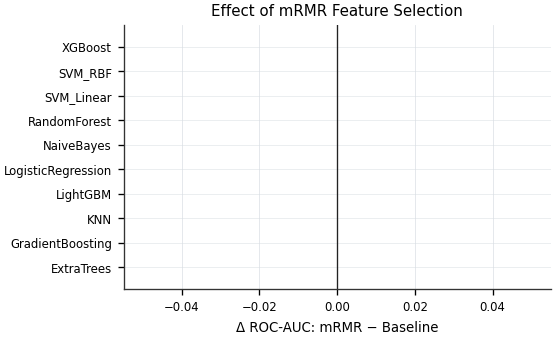

Saved: ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/step_7c_mrmr_vs_baseline_reports/plots_publication_style/fig02_best_baseline_vs_mrmr_roc_curves.png
Saved: ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/step_7c_mrmr_vs_baseline_reports/plots_publication_style/fig02_best_baseline_vs_mrmr_roc_curves.pdf


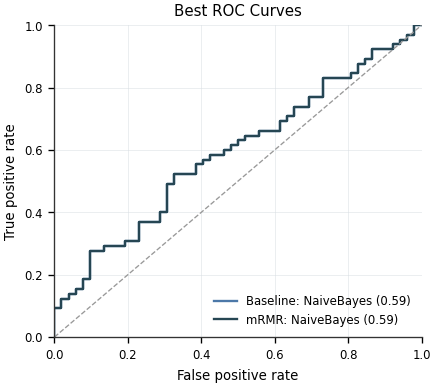


mRMR selected-feature file not found; stability plot skipped.

════════════════════════════════════════════════════════════════════════════════
mRMR ABLATION DECISION TABLE
════════════════════════════════════════════════════════════════════════════════
             Model  Delta_ROC_AUC  Delta_PR_AUC  Delta_Sensitivity  Delta_Specificity  Delta_Brier     Recommendation
        ExtraTrees         0.0000        0.0000             0.0000             0.0000       0.0000 Baseline preferred
  GradientBoosting         0.0000        0.0000             0.0000             0.0000       0.0000 Baseline preferred
               KNN         0.0000        0.0000             0.0000             0.0000       0.0000 Baseline preferred
          LightGBM         0.0000        0.0000             0.0000             0.0000       0.0000 Baseline preferred
LogisticRegression         0.0000        0.0000             0.0000             0.0000       0.0000 Baseline preferred
        NaiveBayes         0.0000    

In [181]:
# =============================================================================
# STEP 7C — mRMR-CUSTOM VS BASELINE STATISTICAL COMPARISON
# =============================================================================
# Purpose:
#   - Compare mRMR-custom FS against Step 2 baseline.
#   - Generate compact, non-redundant manuscript-style figures.
# =============================================================================

print("█" * 80)
print("  STEP 7C — mRMR-CUSTOM VS BASELINE COMPARISON")
print("█" * 80)

import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss,
    roc_curve
)

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Paths
# -----------------------------------------------------------------------------
baseline_dir = os.path.join(
    "./nested_cv_outputs",
    "step_2_baseline_nested_cv_no_smote"
)

mrmr_dir = CONFIG.get(
    "SAVE_DIR",
    os.path.join("./nested_cv_outputs", "step_7_mrmr_custom_fs_nested_cv_no_smote")
)

comparison_dir = os.path.join(mrmr_dir, "step_7c_mrmr_vs_baseline_reports")
plot_dir = os.path.join(comparison_dir, "plots_publication_style")

os.makedirs(comparison_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

if not os.path.exists(baseline_pkl_path):
    raise FileNotFoundError(
        f"Baseline results not found:\n{baseline_pkl_path}\n"
        "Run Step 2 baseline first."
    )

if "nested_cv_results" not in globals():
    raise RuntimeError("Current mRMR nested_cv_results not found. Run Cell 13 after Step 7B.")

with open(baseline_pkl_path, "rb") as f:
    baseline_results = pickle.load(f)

mrmr_results = nested_cv_results

print(f"\nLoaded baseline results from:\n  {baseline_pkl_path}")
print(f"Using current mRMR-custom results from:\n  {mrmr_dir}")

# -----------------------------------------------------------------------------
# 2. Plot style
# -----------------------------------------------------------------------------
plt.style.use("default")

FIG_DPI = 600

COLORS = {
    "baseline": "#4C78A8",
    "mrmr": "#264653",
    "delta_pos": "#2A9D8F",
    "delta_neg": "#B23A48",
    "neutral": "#6C757D",
    "grid": "#D9DEE3"
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


def clean_axis(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis=grid_axis, linestyle="-", linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


def save_figure(fig, filename_base):
    png_path = os.path.join(plot_dir, f"{filename_base}.png")
    pdf_path = os.path.join(plot_dir, f"{filename_base}.pdf")
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def compute_npv(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(len(p_values), np.nan)

    valid = np.isfinite(p_values)
    p = p_values[valid]

    if len(p) == 0:
        return q_values

    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * len(p) / (np.arange(1, len(p) + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    q_valid = np.empty_like(p)
    q_valid[order] = adjusted
    q_values[valid] = q_valid

    return q_values


def pooled_metrics_from_results(results_dict):
    rows = []

    for model_name, res in results_dict.items():
        y_true = np.asarray(res["y_true"], dtype=int)
        y_prob = np.asarray(res["y_prob"], dtype=float)
        y_pred = np.asarray(res["y_pred"], dtype=int)

        rows.append({
            "Model": model_name,
            "ROC_AUC": roc_auc_score(y_true, y_prob),
            "PR_AUC": average_precision_score(y_true, y_prob),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
            "Specificity": compute_specificity(y_true, y_pred),
            "PPV": precision_score(y_true, y_pred, zero_division=0),
            "NPV": compute_npv(y_true, y_pred),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
            "Brier_Score": brier_score_loss(y_true, y_prob),
            "Mean_Selected_Features": np.mean(res["n_features_per_fold"]),
            "Std_Selected_Features": np.std(res["n_features_per_fold"], ddof=1)
        })

    return pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)


def paired_bootstrap_delta_ci(y_true, prob_a, prob_b, metric_func, n_boot=2000, seed=100):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true, dtype=int)
    prob_a = np.asarray(prob_a, dtype=float)
    prob_b = np.asarray(prob_b, dtype=float)

    n = len(y_true)
    deltas = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)

        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            val_a = metric_func(y_true[idx], prob_a[idx])
            val_b = metric_func(y_true[idx], prob_b[idx])
            deltas.append(val_b - val_a)
        except Exception:
            continue

    if len(deltas) == 0:
        return np.nan, np.nan, np.nan

    deltas = np.asarray(deltas, dtype=float)

    return (
        float(np.nanmean(deltas)),
        float(np.nanpercentile(deltas, 2.5)),
        float(np.nanpercentile(deltas, 97.5))
    )


# -----------------------------------------------------------------------------
# 3. Compute comparison table
# -----------------------------------------------------------------------------
baseline_metrics_df = pooled_metrics_from_results(baseline_results)
mrmr_metrics_df = pooled_metrics_from_results(mrmr_results)

baseline_metrics_df.to_csv(
    os.path.join(comparison_dir, "baseline_recomputed_pooled_metrics.csv"),
    index=False
)

mrmr_metrics_df.to_csv(
    os.path.join(comparison_dir, "mrmr_custom_pooled_metrics.csv"),
    index=False
)

common_models = sorted(set(baseline_metrics_df["Model"]).intersection(mrmr_metrics_df["Model"]))

comparison_rows = []

for model_name in common_models:
    b_row = baseline_metrics_df[baseline_metrics_df["Model"] == model_name].iloc[0]
    m_row = mrmr_metrics_df[mrmr_metrics_df["Model"] == model_name].iloc[0]

    b_res = baseline_results[model_name]
    m_res = mrmr_results[model_name]

    b_y_true = np.asarray(b_res["y_true"], dtype=int)
    m_y_true = np.asarray(m_res["y_true"], dtype=int)

    same_oof_order = (
        len(b_y_true) == len(m_y_true)
        and np.array_equal(b_y_true, m_y_true)
    )

    if same_oof_order:
        auc_delta_mean, auc_delta_low, auc_delta_high = paired_bootstrap_delta_ci(
            b_y_true,
            np.asarray(b_res["y_prob"], dtype=float),
            np.asarray(m_res["y_prob"], dtype=float),
            roc_auc_score,
            n_boot=2000,
            seed=CONFIG.get("RANDOM_STATE", 100)
        )

        pr_delta_mean, pr_delta_low, pr_delta_high = paired_bootstrap_delta_ci(
            b_y_true,
            np.asarray(b_res["y_prob"], dtype=float),
            np.asarray(m_res["y_prob"], dtype=float),
            average_precision_score,
            n_boot=2000,
            seed=CONFIG.get("RANDOM_STATE", 100) + 1
        )
    else:
        auc_delta_mean, auc_delta_low, auc_delta_high = np.nan, np.nan, np.nan
        pr_delta_mean, pr_delta_low, pr_delta_high = np.nan, np.nan, np.nan

    b_fold_auc = np.asarray(b_res["fold_aucs"], dtype=float)
    m_fold_auc = np.asarray(m_res["fold_aucs"], dtype=float)

    if len(b_fold_auc) == len(m_fold_auc) and len(b_fold_auc) >= 2:
        try:
            w_stat, w_p = wilcoxon(
                m_fold_auc,
                b_fold_auc,
                alternative="two-sided",
                zero_method="wilcox"
            )
        except Exception:
            w_stat, w_p = np.nan, np.nan
    else:
        w_stat, w_p = np.nan, np.nan

    comparison_rows.append({
        "Model": model_name,

        "Baseline_ROC_AUC": b_row["ROC_AUC"],
        "mRMR_ROC_AUC": m_row["ROC_AUC"],
        "Delta_ROC_AUC_mRMR_minus_Baseline": m_row["ROC_AUC"] - b_row["ROC_AUC"],
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low": auc_delta_low,
        "Paired_Bootstrap_Delta_ROC_AUC_CI95_High": auc_delta_high,

        "Baseline_PR_AUC": b_row["PR_AUC"],
        "mRMR_PR_AUC": m_row["PR_AUC"],
        "Delta_PR_AUC_mRMR_minus_Baseline": m_row["PR_AUC"] - b_row["PR_AUC"],

        "Baseline_Sensitivity": b_row["Sensitivity"],
        "mRMR_Sensitivity": m_row["Sensitivity"],
        "Delta_Sensitivity": m_row["Sensitivity"] - b_row["Sensitivity"],

        "Baseline_Specificity": b_row["Specificity"],
        "mRMR_Specificity": m_row["Specificity"],
        "Delta_Specificity": m_row["Specificity"] - b_row["Specificity"],

        "Baseline_PPV": b_row["PPV"],
        "mRMR_PPV": m_row["PPV"],
        "Delta_PPV": m_row["PPV"] - b_row["PPV"],

        "Baseline_NPV": b_row["NPV"],
        "mRMR_NPV": m_row["NPV"],
        "Delta_NPV": m_row["NPV"] - b_row["NPV"],

        "Baseline_Kappa": b_row["Cohen_Kappa"],
        "mRMR_Kappa": m_row["Cohen_Kappa"],
        "Delta_Kappa": m_row["Cohen_Kappa"] - b_row["Cohen_Kappa"],

        "Baseline_Brier": b_row["Brier_Score"],
        "mRMR_Brier": m_row["Brier_Score"],
        "Delta_Brier_mRMR_minus_Baseline": m_row["Brier_Score"] - b_row["Brier_Score"],

        "Baseline_Mean_Selected_Features": b_row["Mean_Selected_Features"],
        "mRMR_Mean_Selected_Features": m_row["Mean_Selected_Features"],

        "Foldwise_Wilcoxon_AUC_Statistic": w_stat,
        "Foldwise_Wilcoxon_AUC_p_value": w_p,
        "Same_OOF_Order_For_Paired_Bootstrap": same_oof_order
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["Foldwise_Wilcoxon_AUC_q_value_FDR"] = benjamini_hochberg(
    comparison_df["Foldwise_Wilcoxon_AUC_p_value"].values
)

comparison_df = comparison_df.sort_values(
    "Delta_ROC_AUC_mRMR_minus_Baseline",
    ascending=False
).reset_index(drop=True)

comparison_df.to_csv(
    os.path.join(comparison_dir, "mrmr_custom_vs_baseline_model_comparison.csv"),
    index=False
)

print("\n" + "═" * 80)
print("mRMR-CUSTOM VS BASELINE — MODEL COMPARISON")
print("═" * 80)

display_cols = [
    "Model",
    "Baseline_ROC_AUC",
    "mRMR_ROC_AUC",
    "Delta_ROC_AUC_mRMR_minus_Baseline",
    "Paired_Bootstrap_Delta_ROC_AUC_CI95_Low",
    "Paired_Bootstrap_Delta_ROC_AUC_CI95_High",
    "Baseline_PR_AUC",
    "mRMR_PR_AUC",
    "Delta_PR_AUC_mRMR_minus_Baseline",
    "Baseline_Sensitivity",
    "mRMR_Sensitivity",
    "Delta_Sensitivity",
    "Baseline_Specificity",
    "mRMR_Specificity",
    "Delta_Specificity",
    "Foldwise_Wilcoxon_AUC_p_value",
    "Foldwise_Wilcoxon_AUC_q_value_FDR"
]

print(comparison_df[display_cols].to_string(index=False, float_format="%.4f"))

best_baseline_model = baseline_metrics_df.iloc[0]["Model"]
best_mrmr_model = mrmr_metrics_df.iloc[0]["Model"]
best_delta_model = comparison_df.iloc[0]["Model"]

print("\nBest baseline model:", best_baseline_model)
print("Best mRMR model:    ", best_mrmr_model)
print("Largest ROC-AUC gain with mRMR:", best_delta_model)

# -----------------------------------------------------------------------------
# 4. Figure 1 — ROC-AUC delta by model
# -----------------------------------------------------------------------------
delta_plot = comparison_df.sort_values(
    "Delta_ROC_AUC_mRMR_minus_Baseline",
    ascending=True
)

fig, ax = plt.subplots(figsize=(4.8, 3.0))

bar_colors = [
    COLORS["delta_pos"] if v >= 0 else COLORS["delta_neg"]
    for v in delta_plot["Delta_ROC_AUC_mRMR_minus_Baseline"]
]

ax.barh(
    delta_plot["Model"],
    delta_plot["Delta_ROC_AUC_mRMR_minus_Baseline"],
    color=bar_colors,
    edgecolor="#222222",
    linewidth=0.5
)

ax.axvline(0, color="#222222", linewidth=0.8)
ax.set_title("Effect of mRMR Feature Selection")
ax.set_xlabel("Δ ROC-AUC: mRMR − Baseline")
ax.set_ylabel("")
clean_axis(ax)

plt.tight_layout()
save_figure(fig, "fig01_mrmr_delta_roc_auc_by_model")
plt.show()

# -----------------------------------------------------------------------------
# 5. Figure 2 — Best ROC curves
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

b_res = baseline_results[best_baseline_model]
m_res = mrmr_results[best_mrmr_model]

b_y_true = np.asarray(b_res["y_true"], dtype=int)
b_y_prob = np.asarray(b_res["y_prob"], dtype=float)

m_y_true = np.asarray(m_res["y_true"], dtype=int)
m_y_prob = np.asarray(m_res["y_prob"], dtype=float)

b_fpr, b_tpr, _ = roc_curve(b_y_true, b_y_prob)
m_fpr, m_tpr, _ = roc_curve(m_y_true, m_y_prob)

b_auc = roc_auc_score(b_y_true, b_y_prob)
m_auc = roc_auc_score(m_y_true, m_y_prob)

ax.plot(
    b_fpr,
    b_tpr,
    linewidth=1.4,
    color=COLORS["baseline"],
    label=f"Baseline: {best_baseline_model} ({b_auc:.2f})"
)

ax.plot(
    m_fpr,
    m_tpr,
    linewidth=1.4,
    color=COLORS["mrmr"],
    label=f"mRMR: {best_mrmr_model} ({m_auc:.2f})"
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8, color="#999999")

ax.set_title("Best ROC Curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
clean_axis(ax, grid_axis="both")

plt.tight_layout()
save_figure(fig, "fig02_best_baseline_vs_mrmr_roc_curves")
plt.show()

# -----------------------------------------------------------------------------
# 6. Figure 3 — mRMR feature stability
# -----------------------------------------------------------------------------
mrmr_features_path = os.path.join(mrmr_dir, "df_selected_features_long.csv")

if os.path.exists(mrmr_features_path):
    mrmr_feat = pd.read_csv(mrmr_features_path)

    mrmr_stability = (
        mrmr_feat
        .groupby("Feature_Name")
        .size()
        .reset_index(name="Selection_Count")
        .sort_values("Selection_Count", ascending=False)
    )

    mrmr_stability["Selection_Frequency"] = (
        mrmr_stability["Selection_Count"] / CONFIG["N_OUTER_FOLDS"]
    )

    mrmr_stability.to_csv(
        os.path.join(comparison_dir, "mrmr_feature_selection_stability.csv"),
        index=False
    )

    top_mrmr_stable = mrmr_stability.head(12).iloc[::-1]

    fig, ax = plt.subplots(figsize=(4.8, 3.3))

    ax.barh(
        top_mrmr_stable["Feature_Name"],
        top_mrmr_stable["Selection_Frequency"],
        color=COLORS["mrmr"],
        edgecolor="#222222",
        linewidth=0.5
    )

    ax.set_xlim(0, 1)
    ax.set_title("mRMR Feature Stability")
    ax.set_xlabel("Selection frequency across outer folds")
    ax.set_ylabel("")
    clean_axis(ax)

    plt.tight_layout()
    save_figure(fig, "fig03_mrmr_feature_selection_stability")
    plt.show()
else:
    mrmr_stability = pd.DataFrame()
    print("\nmRMR selected-feature file not found; stability plot skipped.")

# -----------------------------------------------------------------------------
# 7. Decision table
# -----------------------------------------------------------------------------
decision_rows = []

for _, row in comparison_df.iterrows():
    auc_delta = row["Delta_ROC_AUC_mRMR_minus_Baseline"]
    pr_delta = row["Delta_PR_AUC_mRMR_minus_Baseline"]
    sens_delta = row["Delta_Sensitivity"]
    spec_delta = row["Delta_Specificity"]
    brier_delta = row["Delta_Brier_mRMR_minus_Baseline"]

    if auc_delta > 0 and pr_delta > 0 and brier_delta <= 0:
        recommendation = "mRMR favorable"
    elif auc_delta > 0 and sens_delta > 0 and spec_delta < 0:
        recommendation = "mRMR improves sensitivity but reduces specificity"
    elif auc_delta <= 0 and pr_delta <= 0:
        recommendation = "Baseline preferred"
    else:
        recommendation = "Mixed effect"

    decision_rows.append({
        "Model": row["Model"],
        "Delta_ROC_AUC": auc_delta,
        "Delta_PR_AUC": pr_delta,
        "Delta_Sensitivity": sens_delta,
        "Delta_Specificity": spec_delta,
        "Delta_Brier": brier_delta,
        "Recommendation": recommendation
    })

mrmr_decision_df = pd.DataFrame(decision_rows).sort_values(
    "Delta_ROC_AUC",
    ascending=False
)

mrmr_decision_df.to_csv(
    os.path.join(comparison_dir, "mrmr_ablation_decision_table.csv"),
    index=False
)

print("\n" + "═" * 80)
print("mRMR ABLATION DECISION TABLE")
print("═" * 80)
print(mrmr_decision_df.to_string(index=False, float_format="%.4f"))

# -----------------------------------------------------------------------------
# 8. Summary
# -----------------------------------------------------------------------------
step_7c_summary = {
    "run_name": CONFIG.get("RUN_NAME", "step_7_mrmr_custom_fs_nested_cv_no_smote"),
    "baseline_dir": baseline_dir,
    "mrmr_dir": mrmr_dir,
    "comparison_dir": comparison_dir,
    "best_baseline_model_by_roc_auc": best_baseline_model,
    "best_baseline_roc_auc": float(baseline_metrics_df.iloc[0]["ROC_AUC"]),
    "best_mrmr_model_by_roc_auc": best_mrmr_model,
    "best_mrmr_roc_auc": float(mrmr_metrics_df.iloc[0]["ROC_AUC"]),
    "largest_auc_gain_model": best_delta_model,
    "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC_mRMR_minus_Baseline"]),
    "use_smote": bool(CONFIG.get("USE_SMOTE", False)),
    "fs_method": CONFIG.get("FS_METHOD", None),
    "fs_n_features": int(CONFIG.get("FS_N_FEATURES", -1)),
    "mrmr_redundancy_weight": float(CONFIG.get("MRMR_REDUNDANCY_WEIGHT", 0.50)),
    "n_models_compared": int(len(common_models))
}

with open(os.path.join(comparison_dir, "step_7c_summary.json"), "w") as f:
    json.dump(step_7c_summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 7C SUMMARY")
print("═" * 80)

for k, v in step_7c_summary.items():
    print(f"{k}: {v}")

print("\nSaved mRMR comparison reports and figures to:")
print(f"  {comparison_dir}")
print(f"  {plot_dir}")

print("\n✅ STEP 7C completed successfully.")

In [182]:
# =============================================================================
# STEP 8A — HIERARCHICAL mRMR + ELASTICNET CONFIGURATION LOCK
# =============================================================================
# Purpose:
#   - Run hierarchical feature selection:
#       1) correlation redundancy filter
#       2) native notebook mrmr_only selector
#       3) ElasticNet/LASSO sparse refinement
#   - Keep SMOTE disabled to isolate feature-selection effect.
# =============================================================================

target_fs_method = globals().get("TARGET_FS_METHOD", None)

if target_fs_method != "hier_mrmr_elasticnet":
    print("█" * 80)
    print("  STEP 8A — SKIPPED")
    print("█" * 80)
    print("This cell is only for TARGET_FS_METHOD='hier_mrmr_elasticnet'.")
    print(f"Current TARGET_FS_METHOD is: {target_fs_method}")
    print("No hierarchical mRMR + ElasticNet configuration was applied.")

else:
    print("█" * 80)
    print("  STEP 8A — HIERARCHICAL mRMR + ELASTICNET CONFIGURATION LOCK")
    print("█" * 80)

    import os
    import json
    import numpy as np

    CONFIG["RUN_NAME"] = "step_8_hier_mrmr_elasticnet_fs_nested_cv_no_smote"
    CONFIG["SAVE_DIR"] = os.path.join(
        "./nested_cv_outputs",
        CONFIG["RUN_NAME"]
    )

    os.makedirs(CONFIG["SAVE_DIR"], exist_ok=True)


    # Final number of selected features
    CONFIG["FS_N_FEATURES"] = CONFIG.get("FS_N_FEATURES", 16)


    # Stage 2: native mRMR candidate pool
    # We intentionally select more candidates first, then refine.
    CONFIG["HIER_MRMR_CANDIDATES"] = max(24, CONFIG["FS_N_FEATURES"] * 2)

    # Stage 3: embedded sparse refinement
    CONFIG["HIER_EMBEDDED_METHOD"] = "elasticnet"   # options: "elasticnet", "lasso"
    CONFIG["HIER_ELASTICNET_L1_RATIO"] = 0.50
    CONFIG["HIER_ELASTICNET_CS"] = [float(x) for x in np.logspace(-3, 1, 10)]
    CONFIG["HIER_COEF_THRESHOLD"] = 1e-6

    # Keep nested CV fixed
    CONFIG["N_OUTER_FOLDS"] = CONFIG.get("N_OUTER_FOLDS", 5)
    CONFIG["N_INNER_FOLDS"] = CONFIG.get("N_INNER_FOLDS", 3)
    CONFIG["N_OPTUNA_TRIALS"] = CONFIG.get("N_OPTUNA_TRIALS", 20)

    hier_config_snapshot = {
        "RUN_NAME": CONFIG["RUN_NAME"],
        "SAVE_DIR": CONFIG["SAVE_DIR"],
        "USE_SMOTE": CONFIG["USE_SMOTE"],
        "FS_METHOD": CONFIG["FS_METHOD"],
        "FS_N_FEATURES": CONFIG["FS_N_FEATURES"],
        "HIER_CORR_THRESHOLD": CONFIG["HIER_CORR_THRESHOLD"],
        "HIER_MRMR_CANDIDATES": CONFIG["HIER_MRMR_CANDIDATES"],
        "HIER_EMBEDDED_METHOD": CONFIG["HIER_EMBEDDED_METHOD"],
        "HIER_ELASTICNET_L1_RATIO": CONFIG["HIER_ELASTICNET_L1_RATIO"],
        "HIER_ELASTICNET_CS": CONFIG["HIER_ELASTICNET_CS"],
        "HIER_COEF_THRESHOLD": CONFIG["HIER_COEF_THRESHOLD"],
        "N_OUTER_FOLDS": CONFIG["N_OUTER_FOLDS"],
        "N_INNER_FOLDS": CONFIG["N_INNER_FOLDS"],
        "N_OPTUNA_TRIALS": CONFIG["N_OPTUNA_TRIALS"],
        "RANDOM_STATE": CONFIG["RANDOM_STATE"],
        "N_SAMPLES": int(X.shape[0]),
        "N_FEATURES": int(X.shape[1]),
        "N_PATIENTS": int(len(set(groups)))
    }

    with open(os.path.join(CONFIG["SAVE_DIR"], "hier_mrmr_elasticnet_config_snapshot.json"), "w") as f:
        json.dump(hier_config_snapshot, f, indent=4)

    print("\nHierarchical mRMR + ElasticNet configuration:")
    for k, v in hier_config_snapshot.items():
        print(f"  {k}: {v}")

    print("\n✅ STEP 8A completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 8A — SKIPPED
████████████████████████████████████████████████████████████████████████████████
This cell is only for TARGET_FS_METHOD='hier_mrmr_elasticnet'.
Current TARGET_FS_METHOD is: None
No hierarchical mRMR + ElasticNet configuration was applied.


In [183]:
# =============================================================================
# STEP 8C — COMPACT HIERARCHICAL FS VS BASELINE COMPARISON
# =============================================================================

print("█" * 80)
print("  STEP 8C — HIERARCHICAL FS VS BASELINE COMPARISON")
print("█" * 80)

import os
import pickle
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    cohen_kappa_score,
    brier_score_loss
)

baseline_dir = "./nested_cv_outputs/step_2_baseline_nested_cv_no_smote"
hier_dir = CONFIG["SAVE_DIR"]

comparison_dir = os.path.join(hier_dir, "step_8c_hier_vs_baseline_reports")
os.makedirs(comparison_dir, exist_ok=True)

baseline_pkl_path = os.path.join(baseline_dir, "nested_cv_results.pkl")

if not os.path.exists(baseline_pkl_path):
    raise FileNotFoundError(f"Baseline results not found: {baseline_pkl_path}")

if "nested_cv_results" not in globals():
    raise RuntimeError("Current hierarchical nested_cv_results not found. Run Cell 13 first.")

with open(baseline_pkl_path, "rb") as f:
    baseline_results = pickle.load(f)

hier_results = nested_cv_results


def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


def npv_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def metrics_from_results(results_dict, fs_label):
    rows = []

    for model_name, res in results_dict.items():
        y_true = np.asarray(res["y_true"], dtype=int)
        y_prob = np.asarray(res["y_prob"], dtype=float)
        y_pred = np.asarray(res["y_pred"], dtype=int)

        rows.append({
            "FS_METHOD": fs_label,
            "Model": model_name,
            "ROC_AUC": roc_auc_score(y_true, y_prob),
            "PR_AUC": average_precision_score(y_true, y_prob),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
            "Specificity": specificity_score(y_true, y_pred),
            "PPV": precision_score(y_true, y_pred, zero_division=0),
            "NPV": npv_score(y_true, y_pred),
            "Kappa": cohen_kappa_score(y_true, y_pred),
            "Brier": brier_score_loss(y_true, y_prob),
            "Mean_Fold_AUC": np.mean(res["fold_aucs"]),
            "Std_Fold_AUC": np.std(res["fold_aucs"], ddof=1),
            "Mean_Selected_Features": np.mean(res["n_features_per_fold"])
        })

    return pd.DataFrame(rows)


baseline_df = metrics_from_results(baseline_results, "Baseline_FS")
hier_df = metrics_from_results(hier_results, CONFIG["FS_METHOD"])

merged = baseline_df.merge(
    hier_df,
    on="Model",
    suffixes=("_Baseline", "_Hier")
)

comparison_rows = []

for _, row in merged.iterrows():
    comparison_rows.append({
        "Model": row["Model"],

        "Baseline_ROC_AUC": row["ROC_AUC_Baseline"],
        "Hier_ROC_AUC": row["ROC_AUC_Hier"],
        "Delta_ROC_AUC": row["ROC_AUC_Hier"] - row["ROC_AUC_Baseline"],

        "Baseline_PR_AUC": row["PR_AUC_Baseline"],
        "Hier_PR_AUC": row["PR_AUC_Hier"],
        "Delta_PR_AUC": row["PR_AUC_Hier"] - row["PR_AUC_Baseline"],

        "Baseline_Sensitivity": row["Sensitivity_Baseline"],
        "Hier_Sensitivity": row["Sensitivity_Hier"],
        "Delta_Sensitivity": row["Sensitivity_Hier"] - row["Sensitivity_Baseline"],

        "Baseline_Specificity": row["Specificity_Baseline"],
        "Hier_Specificity": row["Specificity_Hier"],
        "Delta_Specificity": row["Specificity_Hier"] - row["Specificity_Baseline"],

        "Baseline_Kappa": row["Kappa_Baseline"],
        "Hier_Kappa": row["Kappa_Hier"],
        "Delta_Kappa": row["Kappa_Hier"] - row["Kappa_Baseline"],

        "Baseline_Brier": row["Brier_Baseline"],
        "Hier_Brier": row["Brier_Hier"],
        "Delta_Brier": row["Brier_Hier"] - row["Brier_Baseline"],

        "Baseline_Mean_Selected_Features": row["Mean_Selected_Features_Baseline"],
        "Hier_Mean_Selected_Features": row["Mean_Selected_Features_Hier"]
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "Delta_ROC_AUC",
    ascending=False
).reset_index(drop=True)

decision_rows = []

for _, row in comparison_df.iterrows():
    if row["Delta_ROC_AUC"] > 0 and row["Delta_PR_AUC"] > 0 and row["Delta_Brier"] <= 0:
        recommendation = "Hierarchical FS favorable"
    elif row["Delta_ROC_AUC"] > 0 and row["Delta_Sensitivity"] > 0 and row["Delta_Specificity"] < 0:
        recommendation = "Sensitivity gain with specificity trade-off"
    elif row["Delta_ROC_AUC"] <= 0 and row["Delta_PR_AUC"] <= 0:
        recommendation = "Baseline preferred"
    else:
        recommendation = "Mixed effect"

    decision_rows.append({
        "Model": row["Model"],
        "Delta_ROC_AUC": row["Delta_ROC_AUC"],
        "Delta_PR_AUC": row["Delta_PR_AUC"],
        "Delta_Sensitivity": row["Delta_Sensitivity"],
        "Delta_Specificity": row["Delta_Specificity"],
        "Delta_Kappa": row["Delta_Kappa"],
        "Delta_Brier": row["Delta_Brier"],
        "Recommendation": recommendation
    })

decision_df = pd.DataFrame(decision_rows)

comparison_df.to_csv(
    os.path.join(comparison_dir, "hier_mrmr_elasticnet_vs_baseline_model_comparison.csv"),
    index=False
)

decision_df.to_csv(
    os.path.join(comparison_dir, "hier_mrmr_elasticnet_decision_table.csv"),
    index=False
)

print("\n" + "═" * 80)
print("HIERARCHICAL FS VS BASELINE — COMPARISON")
print("═" * 80)
print(comparison_df.to_string(index=False, float_format="%.4f"))

print("\n" + "═" * 80)
print("HIERARCHICAL FS DECISION TABLE")
print("═" * 80)
print(decision_df.to_string(index=False, float_format="%.4f"))

summary = {
    "run_name": CONFIG["RUN_NAME"],
    "fs_method": CONFIG["FS_METHOD"],
    "comparison_dir": comparison_dir,
    "best_delta_model": str(comparison_df.iloc[0]["Model"]),
    "largest_auc_gain": float(comparison_df.iloc[0]["Delta_ROC_AUC"]),
    "best_hier_model_by_auc": str(hier_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"]),
    "best_hier_auc": float(hier_df.sort_values("ROC_AUC", ascending=False).iloc[0]["ROC_AUC"])
}

with open(os.path.join(comparison_dir, "step_8c_summary.json"), "w") as f:
    json.dump(summary, f, indent=4)

print("\n" + "═" * 80)
print("STEP 8C SUMMARY")
print("═" * 80)

for k, v in summary.items():
    print(f"{k}: {v}")

print("\n✅ STEP 8C completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  STEP 8C — HIERARCHICAL FS VS BASELINE COMPARISON
████████████████████████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════════════════════════
HIERARCHICAL FS VS BASELINE — COMPARISON
════════════════════════════════════════════════════════════════════════════════
             Model  Baseline_ROC_AUC  Hier_ROC_AUC  Delta_ROC_AUC  Baseline_PR_AUC  Hier_PR_AUC  Delta_PR_AUC  Baseline_Sensitivity  Hier_Sensitivity  Delta_Sensitivity  Baseline_Specificity  Hier_Specificity  Delta_Specificity  Baseline_Kappa  Hier_Kappa  Delta_Kappa  Baseline_Brier  Hier_Brier  Delta_Brier  Baseline_Mean_Selected_Features  Hier_Mean_Selected_Features
LogisticRegression            0.5805        0.5805         0.0000           0.6457       0.6457        0.0000                0.5538            0.5538             0.0000                0.5192            0.5192   

In [184]:
# =============================================================================
# apresentATION-READY METRIC EXTRACTION AND GRAPHICAL PLOTTING INGESTION DATA
# =============================================================================
# Purpose:
#   - Isolate diagnostic metadata, coordinate matrices, and threshold metrics
#     for the top candidate model validated across the outer loops.
#   - Export flat serialization frames (ROC, Precision-Recall, Confusion Matrix).
#   - Build generalized summary statistics integrating Pooled values, Fold means,
#     and corresponding Fold standard deviations to secure strict transparency.
#   - Compress verified assets into a unified artifact bundle for publication.
# =============================================================================

import os
import json
import shutil
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix, classification_report,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

# --- 1. Automated Output Destination Initialization -------------------------
save_dir = os.path.join(SAVE_DIR, "plot_data")
os.makedirs(save_dir, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📌 Extracting plot data for the BEST MODEL: {best_model_name}\n")

# Isolate execution statistics of the targeted baseline architecture
results = nested_cv_results[best_model_name]

# -----------------------------------------------------------------------------
# 1) Per-Fold Evaluation Records
# -----------------------------------------------------------------------------
if 'df_fold_details' in locals() or 'df_fold_details' in globals():
    pm_df_dynamic = df_fold_details[df_fold_details['Model'] == best_model_name]
    pm_df_dynamic.to_csv(f"{save_dir}/per_fold_metrics.csv", index=False)
    print("[SAVED] per_fold_metrics.csv")
else:
    print("[SKIP] df_fold_details not found, skipping per_fold_metrics.csv")

# -----------------------------------------------------------------------------
# 2) Consolidated Model Cross-Comparison Manifest
# -----------------------------------------------------------------------------
try:
    df_summary.to_csv(f"{save_dir}/model_summary.csv", index=False)
    print("[SAVED] model_summary.csv")
except NameError:
    print("[SKIP] df_summary not found in memory")

# -----------------------------------------------------------------------------
# 3) Pooled Predictions Profile Matrix
# -----------------------------------------------------------------------------
pred_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_prob': results['y_prob'],
    'y_pred': results['y_pred'],
})
pred_df.to_csv(f"{save_dir}/pooled_predictions.csv", index=False)
print("[SAVED] pooled_predictions.csv")

# -----------------------------------------------------------------------------
# 4) Receiver Operating Characteristic (ROC) Coordinate Curve Values
# -----------------------------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(results['y_true'], results['y_prob'])
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'threshold': roc_thresholds})
roc_df.to_csv(f"{save_dir}/roc_curve.csv", index=False)
print("[SAVED] roc_curve.csv")

# -----------------------------------------------------------------------------
# 5) Precision-Recall (PR) Continuous Curve Values
# -----------------------------------------------------------------------------
prec_arr, rec_arr, pr_thresholds = precision_recall_curve(
    results['y_true'], results['y_prob']
)
pr_df = pd.DataFrame({
    'precision': prec_arr,
    'recall':    rec_arr,
    'threshold': np.append(pr_thresholds, np.nan),
})
pr_df.to_csv(f"{save_dir}/pr_curve.csv", index=False)
print("[SAVED] pr_curve.csv")

# -----------------------------------------------------------------------------
# 6) Confusion Matrix Invariant State Coordinates
# -----------------------------------------------------------------------------
cm = confusion_matrix(results['y_true'], results['y_pred'])
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
cm_df.to_csv(f"{save_dir}/confusion_matrix.csv")
print("[SAVED] confusion_matrix.csv")

# -----------------------------------------------------------------------------
# 7) Comprehensive Multi-Class Classification JSON Manifest
# -----------------------------------------------------------------------------
cls_report = classification_report(
    results['y_true'], results['y_pred'],
    target_names=['Class_0', 'Class_1'],
    digits=4, output_dict=True
)
with open(f"{save_dir}/classification_report.json", 'w') as f:
    json.dump(cls_report, f, indent=2)
print("[SAVED] classification_report.json")

# -----------------------------------------------------------------------------
# 8) Statistical Summary Matrix (Pooled Metrics, Means, and Standard Deviations)
# -----------------------------------------------------------------------------
summary_stats = {
    'model_name':        best_model_name,
    'n_folds':            len(results['fold_aucs']),
    'n_total_samples':    len(results['y_true']),
    
    # Globally Pooled Descriptive Performance Criteria
    'pooled_auc':           roc_auc_score(results['y_true'], results['y_prob']),
    'pooled_accuracy':      accuracy_score(results['y_true'], results['y_pred']),
    'pooled_bal_accuracy': balanced_accuracy_score(results['y_true'], results['y_pred']),
    'pooled_precision':    precision_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_recall':       recall_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_f1':           f1_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_specificity':  compute_specificity(results['y_true'], results['y_pred']) if 'compute_specificity' in locals() else np.nan,

    # Cross-Fold Arithmetic Mean Performance Matrix Indices
    'mean_fold_auc':          np.mean(results['fold_aucs']),
    'mean_fold_accuracy':     np.mean(results['fold_accuracies']),
    'mean_fold_bal_accuracy':  np.mean(results['fold_bal_accuracies']),
    'mean_fold_precision':    np.mean(results['fold_precisions']),
    'mean_fold_recall':       np.mean(results['fold_recalls']),
    'mean_fold_f1':           np.mean(results['fold_f1_scores']),
    'mean_fold_specificity':  np.mean(results['fold_specificities']),

    # Cross-Fold Parametric Standard Deviations (Structural Stability Margins)
    'std_fold_auc':            np.std(results['fold_aucs']),
    'std_fold_accuracy':       np.std(results['fold_accuracies']),
    'std_fold_bal_accuracy':   np.std(results['fold_bal_accuracies']),
    'std_fold_precision':      np.std(results['fold_precisions']),
    'std_fold_recall':         np.std(results['fold_recalls']),
    'std_fold_f1':             np.std(results['fold_f1_scores']),
    'std_fold_specificity':    np.std(results['fold_specificities']),
}

pd.DataFrame([summary_stats]).to_csv(f"{save_dir}/summary_statistics.csv", index=False)
print("[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)")

# -----------------------------------------------------------------------------
# 9) Pack Artifact Repository into a Deployable Package Manifest
# -----------------------------------------------------------------------------
zip_output_name = os.path.join(SAVE_DIR, "plot_data_package")
zip_path = shutil.make_archive(zip_output_name, 'zip', save_dir)
print(f"\n{'='*55}")
print(f"  ALL FILES SAVED IN: {save_dir}/")
print(f"  DOWNLOAD ZIP:       {zip_path}")
print("="*55)

print("\nFiles in package:")
for fname in sorted(os.listdir(save_dir)):
    fsize = os.path.getsize(os.path.join(save_dir, fname))
    print(f"  {fname:35s} ({fsize:,} bytes)")

📌 Extracting plot data for the BEST MODEL: SVM_RBF

[SAVED] per_fold_metrics.csv
[SAVED] model_summary.csv
[SAVED] pooled_predictions.csv
[SAVED] roc_curve.csv
[SAVED] pr_curve.csv
[SAVED] confusion_matrix.csv
[SAVED] classification_report.json
[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)

  ALL FILES SAVED IN: ./nested_cv_outputs/step_2_baseline_nested_cv_no_smote/plot_data/
  DOWNLOAD ZIP:       /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Models/nested_cv_outputs/step_2_baseline_nested_cv_no_smote/plot_data_package.zip

Files in package:
  classification_report.json          (618 bytes)
  confusion_matrix.csv                (45 bytes)
  model_summary.csv                   (5,013 bytes)
  per_fold_metrics.csv                (1,531 bytes)
  pooled_predictions.csv              (2,703 bytes)
  pr_curve.csv                        (6,271 bytes)
  roc_curve.csv  

                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0             SVM_RBF  0.622472             0.622472            0.0   
1          NaiveBayes  0.616939             0.616939            0.0   
2          ExtraTrees  0.609586             0.609586            0.0   
3  LogisticRegression  0.601529             0.601529            0.0   
4          SVM_Linear  0.592869             0.592869            0.0   
5        RandomForest  0.584120             0.584120            0.0   
6             XGBoost  0.568516             0.568516            0.0   
7                 KNN  0.566438             0.566438            0.0   
8    GradientBoosting  0.551100             0.551100            0.0   
9            LightGBM  0.526372             0.526372            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.576923               0.576923              0.0  
1    0.590533               0.590533              0.0  
2    0.582249               0.582249              

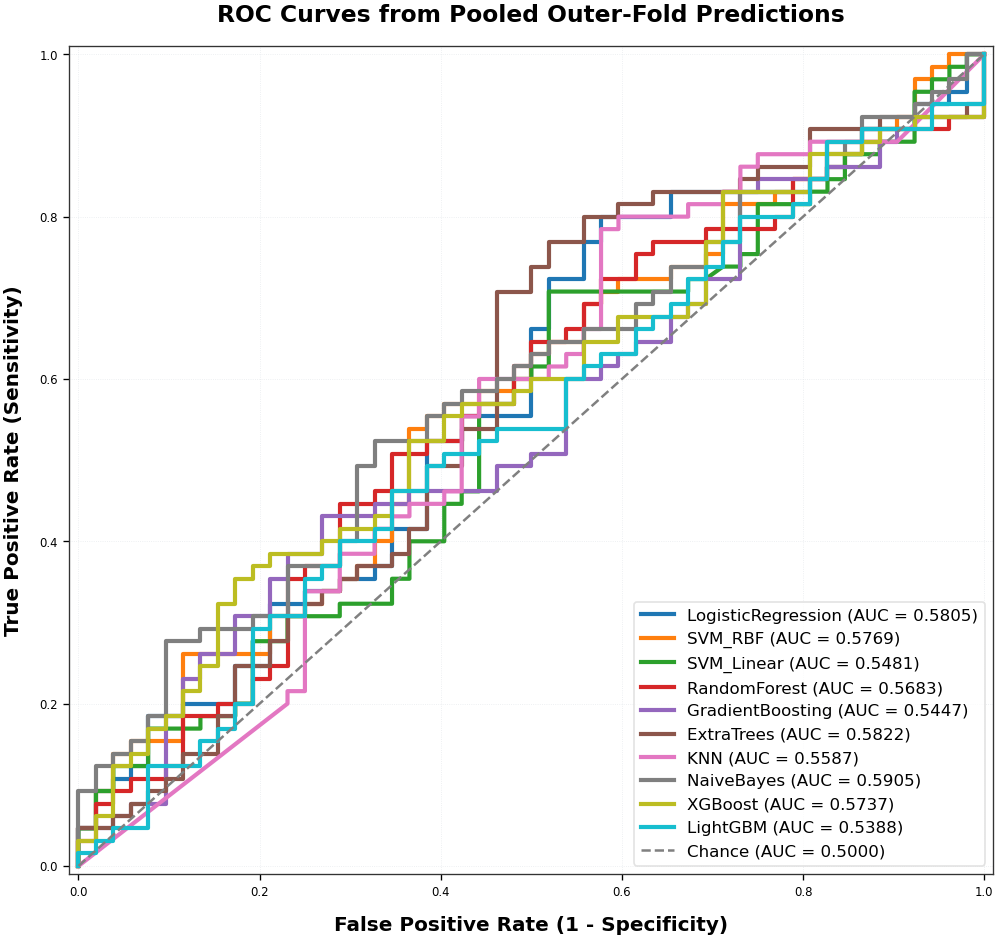


🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/roc_curves.png
 📄 PDF (Vector):   ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/roc_curves.pdf


In [185]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION ROC PLOT DESIGN
# =============================================================================
# Purpose:
#   - Aggregate pooled out-of-fold prediction matrices across all core estimators.
#   - Compute exact empirical Receiver Operating Characteristic (ROC) coordinates.
#   - Generate publication-grade, square-proportioned diagnostic curve overlays.
#   - Persist lossless vector PDF sheets and high-density 900 DPI raster matrices.
# =============================================================================



# =============================================================================
# CONSISTENCY CHECK: df_summary vs nested_cv_results
# =============================================================================

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    if len(np.unique(y_true_chk)) < 2:
        pooled_auc_chk = np.nan
    else:
        pooled_auc_chk = roc_auc_score(y_true_chk, y_prob_chk)

    check_rows.append({
        'Model': model_name,
        'Pooled_AUC_recomputed': pooled_auc_chk,
        'Mean_AUC_recomputed': np.mean(res['fold_aucs'])
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on='Model', how='left')
df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']
df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']

print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                  'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

if (
    df_compare['Mean_AUC_diff'].abs().max() > 1e-8
    or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun cells sequentially from data loading through nested CV."
    )



import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dynamic asset extraction directory synchronization
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# Establish rigorous square geometry aspect configurations optimized for ROC tracking
plt.figure(figsize=(8.5, 8))

# Sequential functional mapping loop navigating through validated cohort predictions
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping ROC for {model_name}: only one class present in y_true.")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    # Render presentation-ready continuous curves using appropriate lineweights
    plt.plot(fpr, tpr, lw=2.5, label=f"{model_name} (AUC = {auc_val:.4f})")

# Construct baseline random distribution benchmark (Chance Line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Chance (AUC = 0.5000)')

# Rigorous layout margin boundary setting
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curves from Pooled Outer-Fold Predictions', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend to bypass asset collision while securing strict contrast margins
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Absolute multi-format storage target compilation
roc_png = os.path.join(PLOT_DIR, 'roc_curves.png')
roc_pdf = os.path.join(PLOT_DIR, 'roc_curves.pdf')

# Execute dual persistence strategy (DPI 900 Raster + Resolution-Invariant Vector)
plt.savefig(roc_png, dpi=600, bbox_inches='tight')
plt.savefig(roc_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", roc_png)
print(" 📄 PDF (Vector):  ", roc_pdf)
print("="*50)

                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0             SVM_RBF  0.622472             0.622472            0.0   
1          NaiveBayes  0.616939             0.616939            0.0   
2          ExtraTrees  0.609586             0.609586            0.0   
3  LogisticRegression  0.601529             0.601529            0.0   
4          SVM_Linear  0.592869             0.592869            0.0   
5        RandomForest  0.584120             0.584120            0.0   
6             XGBoost  0.568516             0.568516            0.0   
7                 KNN  0.566438             0.566438            0.0   
8    GradientBoosting  0.551100             0.551100            0.0   
9            LightGBM  0.526372             0.526372            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.576923               0.576923              0.0  
1    0.590533               0.590533              0.0  
2    0.582249               0.582249              

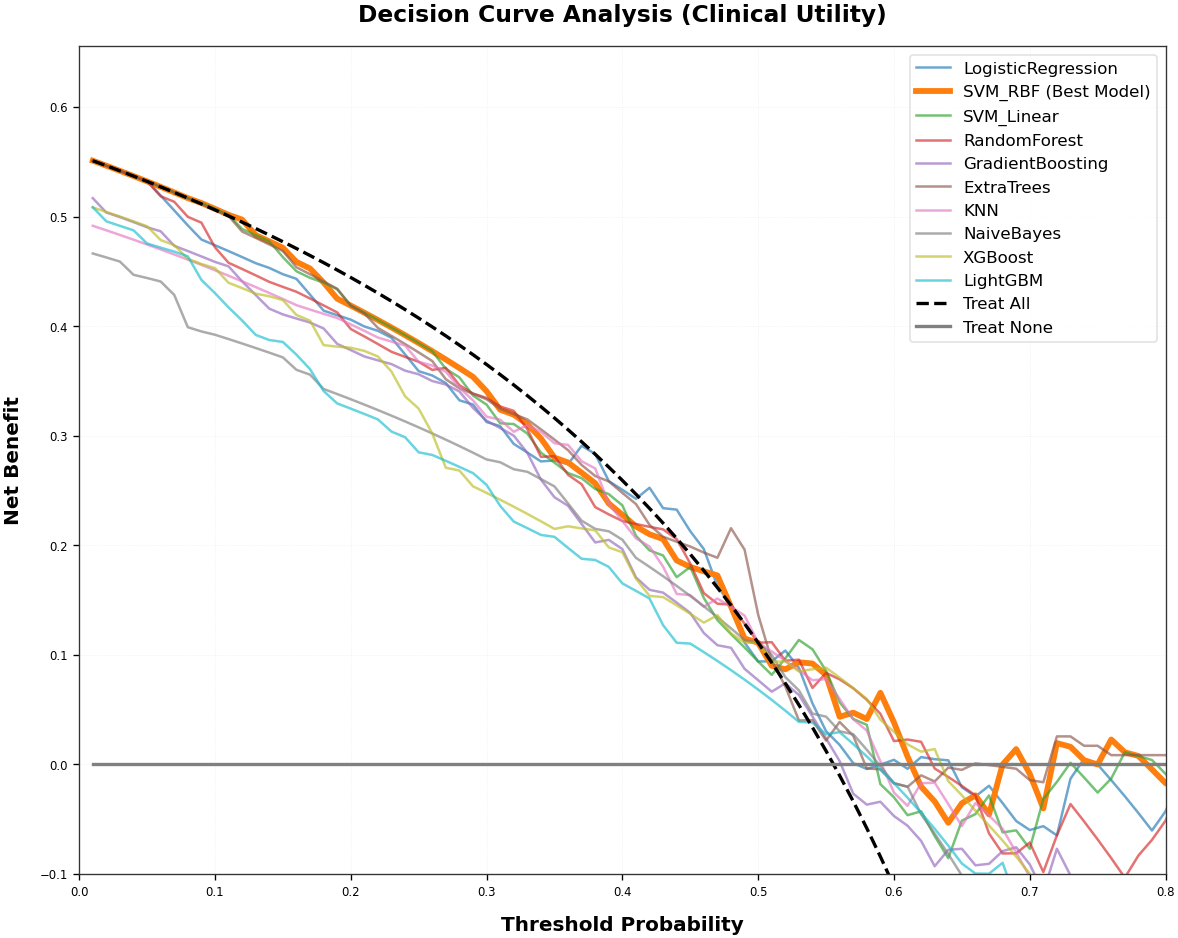


🚀 HIGH-RESOLUTION DCA PLOTS SAVED:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/decision_curve.png
 📄 PDF (Vector):   ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/decision_curve.pdf


In [186]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION DECISION CURVE ANALYSIS
# =============================================================================
# Purpose:
#   - Implement mathematical Net Benefit formulations to evaluate clinical utility.
#   - Contrast dynamic machine learning model configurations against baseline clinical 
#     benchmarks ("Treat All" and "Treat None" strategies).
#   - Dynamically scale line-weights to automatically highlight the champion model.
#   - Save presentation-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

# =============================================================================
# CONSISTENCY CHECK BEFORE DCA
# =============================================================================
from sklearn.metrics import roc_auc_score

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    pooled_auc_chk = roc_auc_score(y_true_chk, y_prob_chk)
    mean_auc_chk = np.mean(res['fold_aucs'])

    check_rows.append({
        'Model': model_name,
        'Mean_AUC_recomputed': mean_auc_chk,
        'Pooled_AUC_recomputed': pooled_auc_chk
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on='Model', how='left')
df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']
df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']

print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                  'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

if (
    df_compare['Mean_AUC_diff'].abs().max() > 1e-8
    or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun all cells sequentially from data loading to nested CV."
    )


import os
import numpy as np
import matplotlib.pyplot as plt

def decision_curve_net_benefit(y_true, y_prob, thresholds):
    """Computes empirical Net Benefit criteria for specified decision thresholds."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue

        y_pred = (y_prob >= pt).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))

        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


def treat_all_net_benefit(y_true, thresholds):
    """Computes standard reference baseline Net Benefit assuming all patients are treated."""
    y_true = np.asarray(y_true)
    n = len(y_true)
    prevalence = np.mean(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue
        nb = prevalence - (1 - prevalence) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📈 Generating DCA. Best model '{best_model_name}' will be highlighted.")

thresholds = np.linspace(0.01, 0.99, 99)
plt.figure(figsize=(10, 8))

# Initialize baseline clinical markers relying on the primary validation array
first_model = next(iter(nested_cv_results.keys()))
reference_y_true = np.asarray(nested_cv_results[first_model]['y_true'])
prevalence = np.mean(reference_y_true)

# --- 3. Dynamic Sequential Curve Plotting ------------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping DCA for {model_name}: only one class present in y_true.")
        continue

    # Dynamically optimize lineweights to highlight the top-performing candidate
    if model_name == best_model_name:
        lw = 3.5
        alpha = 1.0
        label_str = f"{model_name} (Best Model)"
    else:
        lw = 1.5
        alpha = 0.65
        label_str = model_name
    
    nb_model = decision_curve_net_benefit(y_true, y_prob, thresholds)
    plt.plot(thresholds, nb_model, lw=lw, alpha=alpha, label=label_str)

# --- 4. Clinical Reference Baseline Integration ------------------------------
nb_all = treat_all_net_benefit(reference_y_true, thresholds)
nb_none = np.zeros_like(thresholds)

plt.plot(thresholds, nb_all, linestyle='--', color='black', lw=2, label='Treat All')
plt.plot(thresholds, nb_none, linestyle='-', color='gray', lw=2, label='Treat None')

# Enforce strict medical research layout configuration standards
plt.xlim([0.0, 0.8]) 
plt.ylim([-0.1, max(prevalence + 0.1, 0.5)]) 

plt.xlabel('Threshold Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Net Benefit', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Decision Curve Analysis (Clinical Utility)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
dca_png = os.path.join(PLOT_DIR, 'decision_curve.png')
dca_pdf = os.path.join(PLOT_DIR, 'decision_curve.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(dca_png, dpi=600, bbox_inches='tight')
plt.savefig(dca_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION DCA PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", dca_png)
print(" 📄 PDF (Vector):  ", dca_pdf)
print("="*50)


dca_rows = []

for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    if len(np.unique(y_true)) < 2:
        continue

    nb_model = decision_curve_net_benefit(y_true, y_prob, thresholds)

    for pt, nb in zip(thresholds, nb_model):
        dca_rows.append({
            'Model': model_name,
            'Threshold': pt,
            'Net_Benefit': nb
        })

nb_all = treat_all_net_benefit(reference_y_true, thresholds)
for pt, nb in zip(thresholds, nb_all):
    dca_rows.append({
        'Model': 'Treat All',
        'Threshold': pt,
        'Net_Benefit': nb
    })

for pt in thresholds:
    dca_rows.append({
        'Model': 'Treat None',
        'Threshold': pt,
        'Net_Benefit': 0.0
    })

df_dca = pd.DataFrame(dca_rows)
df_dca.to_csv(os.path.join(PLOT_DIR, 'decision_curve_data.csv'), index=False)



🔎 Calibration consistency check:
                Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  \
0             SVM_RBF  0.622472             0.622472            0.0   
1          NaiveBayes  0.616939             0.616939            0.0   
2          ExtraTrees  0.609586             0.609586            0.0   
3  LogisticRegression  0.601529             0.601529            0.0   
4          SVM_Linear  0.592869             0.592869            0.0   
5        RandomForest  0.584120             0.584120            0.0   
6             XGBoost  0.568516             0.568516            0.0   
7                 KNN  0.566438             0.566438            0.0   
8    GradientBoosting  0.551100             0.551100            0.0   
9            LightGBM  0.526372             0.526372            0.0   

   Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff  
0    0.576923               0.576923              0.0  
1    0.590533               0.590533              0.0  
2    0.582249   

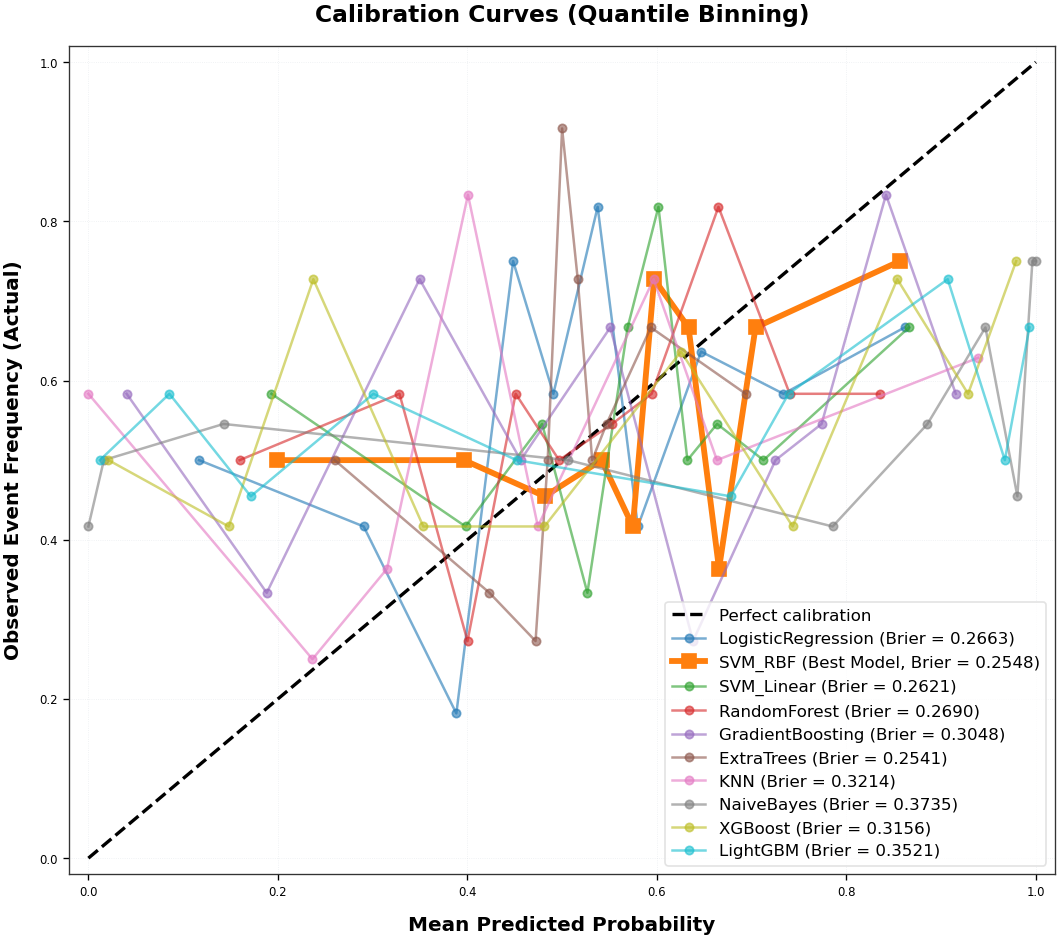


🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/calibration_curves.png
 📄 PDF (Vector):   ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/calibration_curves.pdf


In [187]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION CALIBRATION CURVES
# =============================================================================
# Purpose:
#   - Compute exact empirical calibration curves (reliability diagrams) across 
#     all model configurations using quantile binning strategies.
#   - Quantify global calibration performance via Brier Score Loss calculations.
#   - Dynamically highlight the top-performing candidate model using customized 
#     markers, markersizes, and dominant lineweights.
#   - Save production-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    df_summary = df_summary.sort_values('Mean_AUC', ascending=False).reset_index(drop=True)
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]
    

from sklearn.metrics import roc_auc_score

check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res['y_true'])
    y_prob_chk = np.asarray(res['y_prob'])

    check_rows.append({
        'Model': model_name,
        'Mean_AUC_recomputed': np.mean(res['fold_aucs']),
        'Pooled_AUC_recomputed': roc_auc_score(y_true_chk, y_prob_chk)
    })

df_check = pd.DataFrame(check_rows)

if 'df_summary' in locals() or 'df_summary' in globals():
    df_compare = df_summary.merge(df_check, on='Model', how='left')
    df_compare['Mean_AUC_diff'] = df_compare['Mean_AUC'] - df_compare['Mean_AUC_recomputed']
    df_compare['Pooled_AUC_diff'] = df_compare['Pooled_AUC'] - df_compare['Pooled_AUC_recomputed']

    print("\n🔎 Calibration consistency check:")
    print(df_compare[['Model', 'Mean_AUC', 'Mean_AUC_recomputed', 'Mean_AUC_diff',
                      'Pooled_AUC', 'Pooled_AUC_recomputed', 'Pooled_AUC_diff']])

    if (
        df_compare['Mean_AUC_diff'].abs().max() > 1e-8
        or df_compare['Pooled_AUC_diff'].abs().max() > 1e-8
    ):
        raise ValueError(
            "df_summary and nested_cv_results are inconsistent. "
            "Restart kernel and rerun all cells sequentially from data loading to nested CV."
        )
    

print(f"📊 Generating Calibration Curves. Best model '{best_model_name}' will be highlighted.")

n_bins = 10  # Standard clinical deciles of risk distribution
plt.figure(figsize=(9, 8))

# Reference baseline for a theoretically perfect diagnostic model (Perfect Calibration)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', lw=2, label='Perfect calibration')

# --- 3. Dynamic Sequential Calibration Plotting -------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping calibration for {model_name}: only one class present in y_true.")
        continue

    try:
        # Enforce quantile strategy to preserve uniform sample counts across cross-validation bins
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
        brier = brier_score_loss(y_true, y_prob)

        # Dynamically allocate structural lineweights and shapes to emphasize the best model
        if model_name == best_model_name:
            lw = 3.5
            alpha = 1.0
            marker = 's'  # Square marker chosen exclusively for the champion model
            ms = 8
            label_str = f"{model_name} (Best Model, Brier = {brier:.4f})"
        else:
            lw = 1.5
            alpha = 0.6
            marker = 'o'  # Standard circle marker for baseline competitor profiles
            ms = 5
            label_str = f"{model_name} (Brier = {brier:.4f})"

        plt.plot(mean_pred, frac_pos, marker=marker, markersize=ms, lw=lw, alpha=alpha, label=label_str)
        
    except Exception as e:
        print(f"❌ Skipping calibration for {model_name}: {e}")

# Enforce strict layout configuration boundaries
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Observed Event Frequency (Actual)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Calibration Curves (Quantile Binning)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
cal_png = os.path.join(PLOT_DIR, 'calibration_curves.png')
cal_pdf = os.path.join(PLOT_DIR, 'calibration_curves.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(cal_png, dpi=600, bbox_inches='tight')
plt.savefig(cal_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", cal_png)
print(" 📄 PDF (Vector):  ", cal_pdf)
print("="*50)

In [188]:
# =============================================================================
# COHORT ARTIFACT PERSISTENCE AND CROSS-MODEL EVALUATION EXTRACTOR
# =============================================================================
# Purpose:
#   - Atomically validate array distributions and nomenclature consistency.
#   - Export isolated vector matrices (ROC, PR-Curve, Confusion Matrices) 
#     separately for each individual model topology in the execution memory.
#   - Compute stratified descriptive macro-parameters (mean, std, min, max, pooled).
#   - Persist cross-model evaluation rankings to secure tabular outputs.
# =============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score
)

# -----------------------------------------------------------------------------
# 1. COMPONSATIONAL VALIDATION AND DATA ALIGNMENT UTILITY FUNCTIONS
# -----------------------------------------------------------------------------

def safe_array(x):
    """Converts upstream iterable objects cleanly into 1D contiguous NumPy arrays."""
    if x is None:
        return np.array([])
    return np.asarray(x).ravel()


def safe_metric_stats(values):
    """Computes robust descriptive parameters for localized fold evaluation records.

    Safeguards downstream IO processes from crashing when encountered with empty 
    or incomplete cross-validation tracks by adaptively embedding NaN limits.
    """
    if values is None:
        return np.nan, np.nan, np.nan, np.nan
    
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    return (
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values))
    )


def get_optional_metric(results, key, model_name=None):
    """Safely extracts supplementary non-mandatory metrics from execution arrays."""
    if key not in results or results[key] is None or len(results[key]) == 0:
        warnings.warn(
            f"[{model_name}] Optional metric '{key}' not found in results. "
            f"Summary values will be saved as NaN."
        )
        return []
    return results[key]


def validate_required_keys(results, required_keys, model_name="unknown_model"):
    """Enforces rigid metadata verification to protect analytical structural integrity."""
    missing = [k for k in required_keys if k not in results]
    if missing:
        raise ValueError(
            f"Model '{model_name}' is missing required keys in results: {missing}"
        )


# -----------------------------------------------------------------------------
# 2. CORE SERIALIZATION ENGINE FOR ARTIFACT GENERATION
# -----------------------------------------------------------------------------
def save_model_data(model_name, results, base_dir='plot_data'):
    """Atomically exports performance plots, vector logs, and meta-logs for a model.

    Args:
        model_name (str): Matching token matching the target estimator signature.
        results (dict): Log tracking historical prediction matrices and fold outputs.
        base_dir (str): Relative destination path defining asset storage boundaries.

    Returns:
        dict: Flattened composite mapping consisting of pooled indices and fold statistics.
    """
    required_keys = [
        'y_true', 'y_prob', 'y_pred',
        'fold_aucs', 'fold_accuracies',
        'fold_f1_scores', 'fold_precisions', 'fold_recalls',
        'n_features_per_fold'
    ]
    validate_required_keys(results, required_keys, model_name)

    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    y_true = safe_array(results['y_true'])
    y_prob = safe_array(results['y_prob'])
    y_pred = safe_array(results['y_pred'])

    if len(y_true) == 0:
        raise ValueError(f"Model '{model_name}' has empty y_true.")
    if not (len(y_true) == len(y_prob) == len(y_pred)):
        raise ValueError(
            f"Model '{model_name}' has inconsistent lengths: "
            f"len(y_true)={len(y_true)}, len(y_prob)={len(y_prob)}, len(y_pred)={len(y_pred)}"
        )

    # Ingest complementary auxiliary fold sequences
    fold_pr_aucs = get_optional_metric(results, 'fold_pr_aucs', model_name=model_name)
    fold_bal_accuracies = get_optional_metric(results, 'fold_bal_accuracies', model_name=model_name)

    # ─── 1. Receiver Operating Characteristic (ROC) Coordinate Curves ───
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_df = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr
    })
    roc_df['threshold'] = np.nan
    roc_df.iloc[:len(thresholds_roc), roc_df.columns.get_loc('threshold')] = thresholds_roc
    roc_df.to_csv(os.path.join(model_dir, 'roc_curve.csv'), index=False)

    # ─── 2. Precision-Recall (PR) Continuous Curve Values ───
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)

    pr_df = pd.DataFrame({
        'precision': precision_curve,
        'recall': recall_curve
    })
    pr_df['threshold'] = np.nan
    pr_df.iloc[:len(thresholds_pr), pr_df.columns.get_loc('threshold')] = thresholds_pr
    pr_df.to_csv(os.path.join(model_dir, 'pr_curve.csv'), index=False)

    # ─── 3. Invariant State Confusion Matrices ───
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual_0', 'Actual_1'],
        columns=['Predicted_0', 'Predicted_1']
    )
    cm_df.to_csv(os.path.join(model_dir, 'confusion_matrix.csv'))

    # ─── 4. Pooled Prediction Tracking Profiles ───
    pooled_df = pd.DataFrame({
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred
    })
    pooled_df.to_csv(os.path.join(model_dir, 'pooled_predictions.csv'), index=False)

    # ─── 5. High-Fidelity Categorization Reports (JSON Manifest) ───
    report = classification_report(y_true, y_pred, output_dict=True)
    report['roc_auc'] = float(roc_auc)
    report['average_precision'] = float(ap_score)
    report['balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    with open(os.path.join(model_dir, 'classification_report.json'), 'w') as f:
        json.dump(report, f, indent=2)

    # ─── 6. Structural Longitudinal Fold Progress Matrix ───
    n_folds = len(results['fold_aucs'])

    fold_data = {
        'fold': list(range(1, n_folds + 1)),
        'auc': list(results['fold_aucs']),
        'pr_auc': list(fold_pr_aucs) if len(fold_pr_aucs) == n_folds else [np.nan] * n_folds,
        'accuracy': list(results['fold_accuracies']),
        'bal_accuracy': list(fold_bal_accuracies) if len(fold_bal_accuracies) == n_folds else [np.nan] * n_folds,
        'f1_score': list(results['fold_f1_scores']),
        'precision': list(results['fold_precisions']),
        'recall': list(results['fold_recalls']),
        'n_features': list(results['n_features_per_fold']),
    }

    fold_df = pd.DataFrame(fold_data)
    fold_df.to_csv(os.path.join(model_dir, 'per_fold_metrics.csv'), index=False)

    # ─── 7. Optimal Dynamic Hyperparameter Log Maps ───
    if results.get('best_params_per_fold') is not None and len(results.get('best_params_per_fold')) > 0:
        params_df = pd.DataFrame(results['best_params_per_fold'])
        params_df.insert(0, 'fold', range(1, len(params_df) + 1))
        params_df.to_csv(os.path.join(model_dir, 'best_params_per_fold.csv'), index=False)

    # ─── 8. Summary Statistics Tabular Matrix Construction ───
    auc_mean, auc_std, auc_min, auc_max = safe_metric_stats(results['fold_aucs'])
    pr_mean, pr_std, pr_min, pr_max = safe_metric_stats(fold_pr_aucs)
    acc_mean, acc_std, acc_min, acc_max = safe_metric_stats(results['fold_accuracies'])
    bal_mean, bal_std, bal_min, bal_max = safe_metric_stats(fold_bal_accuracies)
    f1_mean, f1_std, f1_min, f1_max = safe_metric_stats(results['fold_f1_scores'])
    prec_mean, prec_std, prec_min, prec_max = safe_metric_stats(results['fold_precisions'])
    rec_mean, rec_std, rec_min, rec_max = safe_metric_stats(results['fold_recalls'])

    summary = {
        'metric': ['AUC', 'PR_AUC', 'Accuracy', 'Bal_Accuracy', 'F1_Score', 'Precision', 'Recall'],
        'mean':   [auc_mean, pr_mean, acc_mean, bal_mean, f1_mean, prec_mean, rec_mean],
        'std':    [auc_std,  pr_std, acc_std, bal_std, f1_std, prec_std, rec_std],
        'min':    [auc_min,  pr_min, acc_min, bal_min, f1_min, prec_min, rec_min],
        'max':    [auc_max,  pr_max, acc_max, bal_max, f1_max, prec_max, rec_max],
        'pooled': [
            float(roc_auc),
            float(ap_score),  # Maps pooled PR-AUC / Average Precision criteria
            float(accuracy_score(y_true, y_pred)),
            float(balanced_accuracy_score(y_true, y_pred)),
            float(f1_score(y_true, y_pred)),
            float(precision_score(y_true, y_pred, zero_division=0)),
            float(recall_score(y_true, y_pred, zero_division=0)),
        ]
    }

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(model_dir, 'summary_statistics.csv'), index=False)

    return {
        'pooled_auc': float(roc_auc),
        'pooled_pr_auc': float(ap_score),
        'pooled_accuracy': float(accuracy_score(y_true, y_pred)),
        'pooled_bal_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'pooled_f1': float(f1_score(y_true, y_pred)),
        'pooled_precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'pooled_recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'n_samples': int(len(y_true)),
        'n_folds': int(n_folds),
        'fold_auc_mean': auc_mean,
        'fold_auc_std': auc_std,
        'fold_pr_auc_mean': pr_mean,
        'fold_pr_auc_std': pr_std,
        'fold_accuracy_mean': acc_mean,
        'fold_accuracy_std': acc_std,
        'fold_bal_accuracy_mean': bal_mean,
        'fold_bal_accuracy_std': bal_std,
        'fold_f1_mean': f1_mean,
        'fold_f1_std': f1_std,
        'fold_precision_mean': prec_mean,
        'fold_precision_std': prec_std,
        'fold_recall_mean': rec_mean,
        'fold_recall_std': rec_std,
    }


# -----------------------------------------------------------------------------
# 3. GLOBAL ROUTING PIPELINE SEQUENCE: SYSTEM OVERVIEW LOGGING
# -----------------------------------------------------------------------------
base_dir = 'plot_data'
os.makedirs(base_dir, exist_ok=True)

print("=" * 70)
print("📦 Saving data for all models...")
print("=" * 70)

all_models_summary = []

for model_name, results in nested_cv_results.items():
    try:
        if 'y_true' not in results or len(results['y_true']) == 0:
            print(f"  ⚠️  {model_name}: No data found, skipping...")
            continue

        model_summary = save_model_data(model_name, results, base_dir)

        all_models_summary.append({
            'model': model_name,
            'mean_auc': model_summary['fold_auc_mean'],
            'std_auc': model_summary['fold_auc_std'],
            'pooled_auc': model_summary['pooled_auc'],
            'mean_pr_auc': model_summary['fold_pr_auc_mean'],
            'std_pr_auc': model_summary['fold_pr_auc_std'],
            'pooled_pr_auc': model_summary['pooled_pr_auc'],
            'mean_accuracy': model_summary['fold_accuracy_mean'],
            'std_accuracy': model_summary['fold_accuracy_std'],
            'pooled_accuracy': model_summary['pooled_accuracy'],
            'mean_bal_accuracy': model_summary['fold_bal_accuracy_mean'],
            'std_bal_accuracy': model_summary['fold_bal_accuracy_std'],
            'pooled_bal_accuracy': model_summary['pooled_bal_accuracy'],
            'mean_f1': model_summary['fold_f1_mean'],
            'std_f1': model_summary['fold_f1_std'],
            'pooled_f1': model_summary['pooled_f1'],
            'mean_precision': model_summary['fold_precision_mean'],
            'std_precision': model_summary['fold_precision_std'],
            'pooled_precision': model_summary['pooled_precision'],
            'mean_recall': model_summary['fold_recall_mean'],
            'std_recall': model_summary['fold_recall_std'],
            'pooled_recall': model_summary['pooled_recall'],
            'n_samples': model_summary['n_samples'],
            'n_folds': model_summary['n_folds'],
        })

        print(
            f"   ✅ {model_name:25s} | "
            f"Pooled AUC={model_summary['pooled_auc']:.4f} | "
            f"Pooled PR-AUC={model_summary['pooled_pr_auc']:.4f} | "
            f"{model_summary['n_samples']} samples | "
            f"{model_summary['n_folds']} folds"
        )

    except Exception as e:
        print(f"   ❌ {model_name}: Failed -> {e}")


# -----------------------------------------------------------------------------
# 4. CROSS-MODEL TABULAR RANKING MATRIX EVALUATION
# -----------------------------------------------------------------------------
comparison_dir = os.path.join(base_dir, 'comparison')
os.makedirs(comparison_dir, exist_ok=True)

summary_all_df = pd.DataFrame(all_models_summary)

if len(summary_all_df) > 0:
    summary_all_df = summary_all_df.sort_values('mean_auc', ascending=False).reset_index(drop=True)
    summary_all_df.to_csv(os.path.join(comparison_dir, 'all_models_summary.csv'), index=False)

print("=" * 70)
print(f"✅ Done! {len(all_models_summary)} models saved.")
print(f"📁 Output directory: {os.path.abspath(base_dir)}")
print("=" * 70)

# --- Dynamic Directory Verification Sequence ---------------------------------
print("\n📂 Directory structure:")
for item_name in sorted(os.listdir(base_dir)):
    item_path = os.path.join(base_dir, item_name)
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f"   ├── {item_name}/ ({len(files)} files)")

📦 Saving data for all models...
   ✅ LogisticRegression        | Pooled AUC=0.5805 | Pooled PR-AUC=0.6457 | 117 samples | 5 folds
   ✅ SVM_RBF                   | Pooled AUC=0.5769 | Pooled PR-AUC=0.6509 | 117 samples | 5 folds
   ✅ SVM_Linear                | Pooled AUC=0.5481 | Pooled PR-AUC=0.6280 | 117 samples | 5 folds
   ✅ RandomForest              | Pooled AUC=0.5683 | Pooled PR-AUC=0.6302 | 117 samples | 5 folds
   ✅ GradientBoosting          | Pooled AUC=0.5447 | Pooled PR-AUC=0.6241 | 117 samples | 5 folds
   ✅ ExtraTrees                | Pooled AUC=0.5822 | Pooled PR-AUC=0.6244 | 117 samples | 5 folds
   ✅ KNN                       | Pooled AUC=0.5587 | Pooled PR-AUC=0.5798 | 117 samples | 5 folds
   ✅ NaiveBayes                | Pooled AUC=0.5905 | Pooled PR-AUC=0.6774 | 117 samples | 5 folds
   ✅ XGBoost                   | Pooled AUC=0.5737 | Pooled PR-AUC=0.6491 | 117 samples | 5 folds
   ✅ LightGBM                  | Pooled AUC=0.5388 | Pooled PR-AUC=0.5964 | 117 sample

In [189]:
# =============================================================================
# RADIOMICS MANIFOLD LEARNING AND HIGH-DIMENSIONAL COHORT CLUSTERING (t-SNE)
# =============================================================================
# Purpose:
#   - Isolate raw numeric multi-modality features from global diagnostic frames.
#   - Execute non-linear dimensionality reduction utilizing manifold learning (t-SNE).
#   - Generate presentation-grade, high-resolution diagnostic cluster charts 
#     evaluating class boundaries (0 vs 1) and intra-patient batch effects.
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- 1. Vector Matrix Isolation and Baseline Extraction ---------------------
# Filter continuous numeric radiomics parameters dynamically from system memory
X_numeric = pd.DataFrame(X, columns=feature_names).copy()
y_labels = np.asarray(y)
patient_groups = np.asarray(groups)

print(f"t-SNE input shape: {X_numeric.shape}")
print(f"Number of labels: {len(y_labels)}")
print(f"Number of patient groups: {len(patient_groups)}")


print("⏳ Scaling data and calculating t-SNE (This may take 1-2 minutes)...")

# --- 2. Invariant Standardization and Feature Rescaling ---------------------
# Enforce zero-mean and unit-variance scaling to protect optimization algorithms 
# from dominant dimensional variance artifacts.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# --- 3. Manifold Learning and Low-Dimensional Embedding Space ----------------
# Compile non-linear high-dimensional topological boundaries into an optimized 
# 2D coordinate map using t-Distributed Stochastic Neighbor Embedding.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Assemble lower-dimensional array coordinates into a clean structured tracking DataFrame
tsne_df = pd.DataFrame({
    'TSNE_1': X_tsne[:, 0],
    'TSNE_2': X_tsne[:, 1],
    'Class': y_labels,
    'Patient_ID': patient_groups
})

# Establish destination directory framework for persistent storage
os.makedirs('plot_data/Clustering', exist_ok=True)

# -----------------------------------------------------------------------------
# GRAPHICAL CHART 1: TARGET PATHOLOGICAL SIGNAL ISOLATION ANALYSIS
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Class',
    palette=['#FF7043', '#00ACC1'],  # Balanced vibrant coral and deep cyan accents
    data=tsne_df,
    alpha=0.7,
    s=60,
    edgecolor=None
)
plt.title("t-SNE Visualization: Separation by Class (0 vs 1)", fontsize=14, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title='Target Class')
plt.tight_layout()
plt.savefig('plot_data/Clustering/tsne_by_class.png', dpi=300)
plt.close()

# -----------------------------------------------------------------------------
# GRAPHICAL CHART 2: INTRA-PATIENT LESION CLUSTERING MATRIX
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 9))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Patient_ID',
    palette='tab20',  # Distinct qualitative layout to track discrete subject profiles
    data=tsne_df,
    alpha=0.8,
    s=50,
    edgecolor='k',
    linewidth=0.2
)
plt.title("t-SNE Visualization: Lesion Clustering by Patient", fontsize=14, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

# Prevent bounding-box metric clipping by projecting the legend externally
plt.legend(title='Patient ID', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.savefig('plot_data/Clustering/tsne_by_patient.png', dpi=600)
plt.close()

print("✅ t-SNE plots saved successfully in 'plot_data/Clustering/'")

t-SNE input shape: (117, 145)
Number of labels: 117
Number of patient groups: 117
⏳ Scaling data and calculating t-SNE (This may take 1-2 minutes)...
✅ t-SNE plots saved successfully in 'plot_data/Clustering/'


🌟 FINAL XAI PIPELINE: STABLE-FEATURE SHAP ANALYSIS

🔎 Consistency check:
             Model  Mean_AUC  Mean_AUC_recomputed  Mean_AUC_diff  Pooled_AUC  Pooled_AUC_recomputed  Pooled_AUC_diff
           SVM_RBF  0.622472             0.622472            0.0    0.576923               0.576923              0.0
        NaiveBayes  0.616939             0.616939            0.0    0.590533               0.590533              0.0
        ExtraTrees  0.609586             0.609586            0.0    0.582249               0.582249              0.0
LogisticRegression  0.601529             0.601529            0.0    0.580473               0.580473              0.0
        SVM_Linear  0.592869             0.592869            0.0    0.548077               0.548077              0.0
      RandomForest  0.584120             0.584120            0.0    0.568343               0.568343              0.0
           XGBoost  0.568516             0.568516            0.0    0.573669               0.573669         

PermutationExplainer explainer: 118it [00:22,  2.92it/s]                         



✅ SHAP calculation complete.

Top SHAP features:
                                                         Feature_Original                                                         Feature_Sanitized  MeanAbsSHAP  Selection_Count
Morph_RadiusSphereNorm_MaxIntensityCoor_PerimeterCoor_2DAxialSmallestDist Morph_RadiusSphereNorm_MaxIntensityCoor_PerimeterCoor_2DAxialSmallestDist     0.044153                2
                                                     IB_IntensitySkewness                                                      IB_IntensitySkewness     0.037477                4
                                  IH_IntensityHistogramSkewness_Intensity                                   IH_IntensityHistogramSkewness_Intensity     0.035869                4
           Morph_MaxIntensityCoor_PerimeterCoor_2DSagittalSmallestDist_mm            Morph_MaxIntensityCoor_PerimeterCoor_2DSagittalSmallestDist_mm     0.031563                2
                                                       Morph

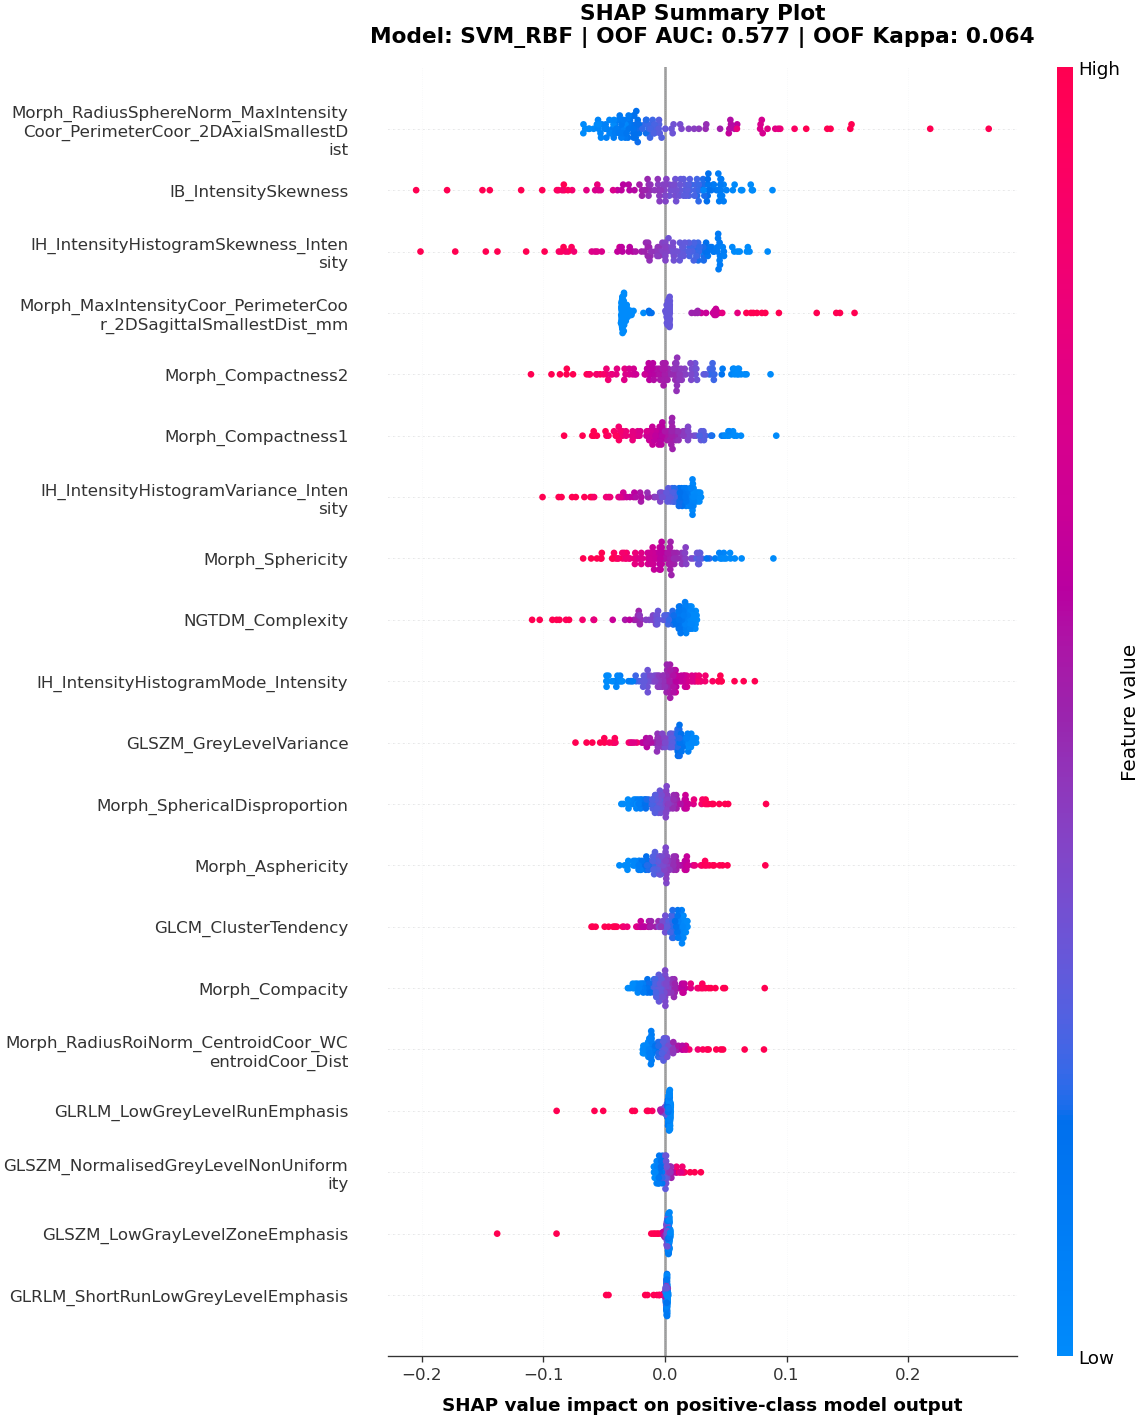

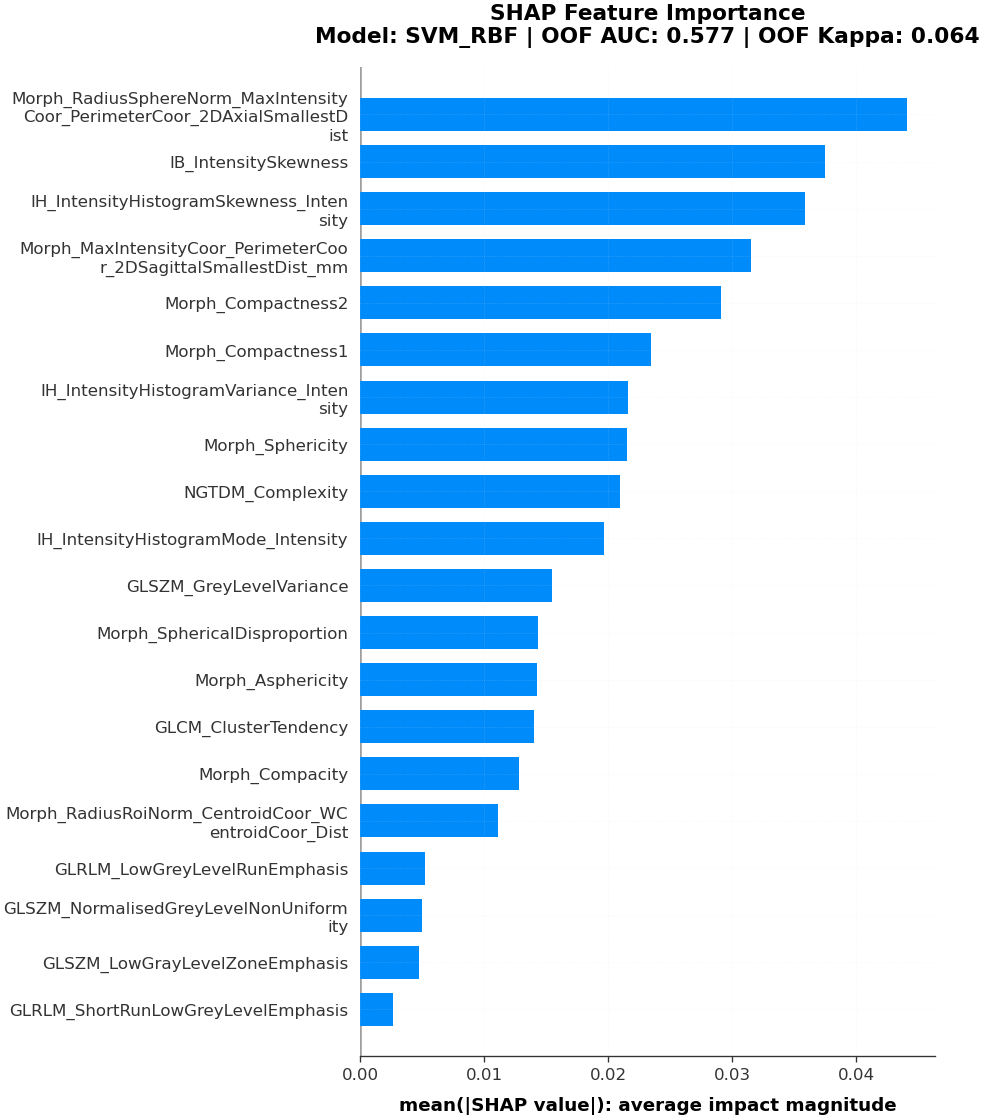


🎉 FINAL XAI PIPELINE COMPLETE
📁 Output directory: ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/SHAP_Plots
💾 Metadata:         ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/SHAP_Plots/xai_metadata.json
💾 Model artifact:   ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/SHAP_Plots/Best_Model_SVM_RBF_XAI_Artifact.joblib
💾 SHAP dot plot:    ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/SHAP_Plots/shap_summary_dot_stable.png
💾 SHAP bar plot:    ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote/SHAP_Plots/shap_summary_bar_stable.png


In [190]:
# =============================================================================
# FINAL EXPLAINABLE AI MODULE: STABLE-FEATURE SHAP ANALYSIS
# =============================================================================
# Purpose:
#   - Verify consistency between df_summary and nested_cv_results.
#   - Select the best model by Mean AUC from nested CV.
#   - Build a recurrence-based stable feature set from outer-fold feature selection.
#   - Refit the best model on the full cohort using the same imputation/scaling logic.
#   - Use OOF metrics for reported performance/Kappa, not in-sample metrics.
#   - Compute SHAP explanations on positive-class probability / model score.
#   - Save SHAP plots, feature-importance tables, stability tables, and model artifact.
# =============================================================================

import os
import re
import json
import math
import textwrap
import warnings
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

print("=" * 80)
print("🌟 FINAL XAI PIPELINE: STABLE-FEATURE SHAP ANALYSIS")
print("=" * 80)


# =============================================================================
# 0. REQUIRED OBJECT CHECKS
# =============================================================================
required_objects = [
    "df", "y", "df_summary", "nested_cv_results",
    "selected_features_per_fold", "CONFIG", "NESTED_CV_MODELS"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]
if len(missing_objects) > 0:
    raise RuntimeError(
        f"Missing required runtime objects: {missing_objects}. "
        "Run the previous notebook cells sequentially before this XAI cell."
    )


# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================
def sanitize_feature_name(name):
    """Convert feature names to model-safe strings."""
    name = str(name)
    name = re.sub(r"[^a-zA-Z0-9_]", "_", name)
    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name


def wrap_feature_labels(labels, width=35):
    """Wrap long feature names for readable SHAP plots."""
    return [textwrap.fill(str(label), width=width) for label in labels]


def interpret_kappa(kappa_score):
    """Interpret Cohen's Kappa."""
    if kappa_score < 0:
        return "No agreement / worse than chance"
    elif kappa_score <= 0.20:
        return "Slight agreement / very weak"
    elif kappa_score <= 0.40:
        return "Fair agreement / low"
    elif kappa_score <= 0.60:
        return "Moderate agreement"
    elif kappa_score <= 0.80:
        return "Substantial agreement"
    else:
        return "Almost perfect agreement"


def to_jsonable(obj):
    """Convert NumPy/Pandas objects to JSON-safe objects."""
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if pd.isna(obj) if not isinstance(obj, (list, dict, tuple, np.ndarray)) else False:
        return None
    return obj


def aggregate_best_params(params_per_fold):
    """
    Aggregate Optuna-selected hyperparameters across outer folds without using
    outer-test performance to choose a single fold.

    Numeric parameters -> median.
    Integer numeric parameters -> rounded median.
    Categorical/string/bool/None parameters -> mode.
    """
    if params_per_fold is None or len(params_per_fold) == 0:
        return {}

    all_keys = sorted(set().union(*[p.keys() for p in params_per_fold if isinstance(p, dict)]))
    aggregated = {}

    for key in all_keys:
        vals = [p[key] for p in params_per_fold if isinstance(p, dict) and key in p]

        if len(vals) == 0:
            continue

        all_numeric = all(isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool) for v in vals)

        if all_numeric:
            med_val = float(np.median(vals))
            all_int = all(isinstance(v, (int, np.integer)) and not isinstance(v, bool) for v in vals)
            aggregated[key] = int(round(med_val)) if all_int else med_val
        else:
            aggregated[key] = Counter(vals).most_common(1)[0][0]

    return aggregated


def compute_specificity_from_arrays(y_true, y_pred):
    """Compute specificity = TN / (TN + FP)."""
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return np.nan

    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


# =============================================================================
# 2. CONSISTENCY CHECK: df_summary vs nested_cv_results
# =============================================================================
check_rows = []

for model_name, res in nested_cv_results.items():
    y_true_chk = np.asarray(res["y_true"])
    y_prob_chk = np.asarray(res["y_prob"])

    check_rows.append({
        "Model": model_name,
        "Mean_AUC_recomputed": float(np.mean(res["fold_aucs"])),
        "Pooled_AUC_recomputed": float(roc_auc_score(y_true_chk, y_prob_chk)),
        "Pooled_PR_AUC_recomputed": float(average_precision_score(y_true_chk, y_prob_chk))
    })

df_check = pd.DataFrame(check_rows)

df_compare = df_summary.merge(df_check, on="Model", how="left")
df_compare["Mean_AUC_diff"] = df_compare["Mean_AUC"] - df_compare["Mean_AUC_recomputed"]
df_compare["Pooled_AUC_diff"] = df_compare["Pooled_AUC"] - df_compare["Pooled_AUC_recomputed"]

print("\n🔎 Consistency check:")
print(
    df_compare[
        [
            "Model",
            "Mean_AUC",
            "Mean_AUC_recomputed",
            "Mean_AUC_diff",
            "Pooled_AUC",
            "Pooled_AUC_recomputed",
            "Pooled_AUC_diff"
        ]
    ].to_string(index=False)
)

if (
    df_compare["Mean_AUC_diff"].abs().max() > 1e-8 or
    df_compare["Pooled_AUC_diff"].abs().max() > 1e-8
):
    raise ValueError(
        "df_summary and nested_cv_results are inconsistent. "
        "Restart kernel and rerun all cells sequentially from data loading to nested CV."
    )


# =============================================================================
# 3. BEST MODEL SELECTION BY NESTED-CV MEAN AUC
# =============================================================================
df_summary_sorted = df_summary.sort_values("Mean_AUC", ascending=False).reset_index(drop=True)
best_model_name = df_summary_sorted.iloc[0]["Model"]
best_model_results = nested_cv_results[best_model_name]

print("\n" + "=" * 80)
print(f"🏆 Champion Model Detected by Mean AUC: {best_model_name}")
print(f"📈 Mean Fold AUC:   {df_summary_sorted.iloc[0]['Mean_AUC']:.4f}")
print(f"📈 Pooled OOF AUC:  {df_summary_sorted.iloc[0]['Pooled_AUC']:.4f}")
print("=" * 80)


# =============================================================================
# 4. OOF PERFORMANCE AND AGREEMENT PROFILE
# =============================================================================
y_oof_true = np.asarray(best_model_results["y_true"])
y_oof_prob = np.asarray(best_model_results["y_prob"])
y_oof_pred = np.asarray(best_model_results["y_pred"])

oof_metrics = {
    "oof_auc": float(roc_auc_score(y_oof_true, y_oof_prob)),
    "oof_pr_auc": float(average_precision_score(y_oof_true, y_oof_prob)),
    "oof_accuracy": float(accuracy_score(y_oof_true, y_oof_pred)),
    "oof_balanced_accuracy": float(balanced_accuracy_score(y_oof_true, y_oof_pred)),
    "oof_precision": float(precision_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_recall": float(recall_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_f1": float(f1_score(y_oof_true, y_oof_pred, zero_division=0)),
    "oof_specificity": float(compute_specificity_from_arrays(y_oof_true, y_oof_pred)),
    "oof_kappa": float(cohen_kappa_score(y_oof_true, y_oof_pred)),
}

print("\n📊 OOF agreement/performance profile for SHAP title and metadata:")
for k, v in oof_metrics.items():
    print(f"   {k:25s}: {v:.4f}")

print(f"   kappa_interpretation     : {interpret_kappa(oof_metrics['oof_kappa'])}")


# =============================================================================
# 5. STABLE FEATURE SELECTION BY CROSS-FOLD RECURRENCE
# =============================================================================
all_selected_features = []
for fold_features in selected_features_per_fold:
    all_selected_features.extend(list(fold_features))

feature_counts = Counter(all_selected_features)
n_fs_folds = len(selected_features_per_fold)

if n_fs_folds == 0 or len(feature_counts) == 0:
    raise ValueError("selected_features_per_fold is empty. Cannot perform stable-feature SHAP analysis.")

min_stability_freq = CONFIG.get(
    "XAI_MIN_STABILITY_FREQ",
    max(2, math.ceil(0.40 * n_fs_folds))
)

stable_features = [
    feat for feat, count in feature_counts.items()
    if count >= min_stability_freq
]

stable_features = sorted(
    stable_features,
    key=lambda f: (feature_counts[f], f),
    reverse=True
)

# Conservative fallback: use top recurrent selected features, not all numeric features.
if len(stable_features) == 0:
    fallback_n = min(CONFIG.get("FS_N_FEATURES", 12), len(feature_counts))
    stable_features = [feat for feat, _ in feature_counts.most_common(fallback_n)]
    print(
        f"\n⚠️ No feature reached stability threshold >= {min_stability_freq}/{n_fs_folds}. "
        f"Using top {fallback_n} recurrent selected features instead."
    )

df_feature_stability = pd.DataFrame([
    {
        "Feature_Name": feat,
        "Selection_Count": feature_counts[feat],
        "Selection_Frequency": feature_counts[feat] / n_fs_folds,
        "Selected_As_Stable": feat in stable_features
    }
    for feat in sorted(feature_counts.keys(), key=lambda f: feature_counts[f], reverse=True)
])

print("\n" + "=" * 80)
print("🧬 Feature-selection stability summary")
print("=" * 80)
print(f"Outer FS folds: {n_fs_folds}")
print(f"Stability threshold: selected in >= {min_stability_freq}/{n_fs_folds} folds")
print(f"Stable/recurrent features selected for SHAP: {len(stable_features)}")
print(df_feature_stability.head(30).to_string(index=False))


# =============================================================================
# 6. ALIGN STABLE FEATURE NAMES WITH df COLUMNS
# =============================================================================
label_col = CONFIG.get("LABEL_COL", "Label")
group_col = CONFIG.get("GROUP_COL", "INFO_PatientName")

unwanted_cols = {
    label_col,
    group_col,
    "Unnamed: 0",
    "Unnamed: 2",
    "id",
    "ID",
    "Batch",
    "INFO_NameOfRoi",
    "INFO_NameOfRoi_PET",
    "INFO_PatientName_PET",
    "Batch_PET",
}

df_columns = list(df.columns)
sanitized_to_original = {}

for col in df_columns:
    s_col = sanitize_feature_name(col)
    if s_col not in sanitized_to_original:
        sanitized_to_original[s_col] = col

clean_features = []
unmatched_features = []

for feat in stable_features:
    if feat in df.columns and feat not in unwanted_cols and pd.api.types.is_numeric_dtype(df[feat]):
        clean_features.append(feat)
        continue

    s_feat = sanitize_feature_name(feat)
    if (
        s_feat in sanitized_to_original
        and sanitized_to_original[s_feat] not in unwanted_cols
        and pd.api.types.is_numeric_dtype(df[sanitized_to_original[s_feat]])
    ):
        clean_features.append(sanitized_to_original[s_feat])
    else:
        unmatched_features.append(feat)

# Remove duplicates while preserving order
clean_features = list(dict.fromkeys(clean_features))

if len(unmatched_features) > 0:
    print("\n⚠️ Stable features not matched to df columns:")
    for f in unmatched_features:
        print(f"   - {f}")

if len(clean_features) == 0:
    raise ValueError(
        "No stable selected features matched df columns. "
        "Check selected_features_per_fold and feature names before SHAP."
    )

print("\n✅ Final SHAP feature space verified.")
print(f"   Active features: {len(clean_features)}")
for i, f in enumerate(clean_features, 1):
    print(f"   {i:02d}. {f}")


# =============================================================================
# 7. FULL-COHORT REFIT FOR INTERPRETATION ONLY
# =============================================================================
print("\n" + "=" * 80)
print("🚀 Refitting champion model on full cohort for interpretation only")
print("   Note: reported metrics remain OOF/nested-CV metrics, not in-sample refit metrics.")
print("=" * 80)

X_final_raw = df[clean_features].copy()
y_final = np.asarray(y).astype(int)

sanitized_feature_names = [sanitize_feature_name(c) for c in X_final_raw.columns]

# Ensure uniqueness after sanitization
seen = {}
unique_sanitized_feature_names = []
for name in sanitized_feature_names:
    if name not in seen:
        seen[name] = 0
        unique_sanitized_feature_names.append(name)
    else:
        seen[name] += 1
        unique_sanitized_feature_names.append(f"{name}_{seen[name]}")

final_imputer = SimpleImputer(strategy="median")
X_final_imp = final_imputer.fit_transform(X_final_raw)

final_scaler = StandardScaler()
X_final_scaled = final_scaler.fit_transform(X_final_imp)

X_for_model = pd.DataFrame(
    X_final_scaled,
    columns=unique_sanitized_feature_names,
    index=X_final_raw.index
)

best_params_aggregated = aggregate_best_params(best_model_results.get("best_params_per_fold", []))

print("\n🔧 Aggregated hyperparameters from outer folds:")
print(best_params_aggregated)

if "build_model_from_best_params" in globals():
    final_model = build_model_from_best_params(
        model_name=best_model_name,
        params=best_params_aggregated,
        random_state=CONFIG.get("RANDOM_STATE", 42)
    )
else:
    warnings.warn(
        "build_model_from_best_params() not found. Falling back to clone + set_params. "
        "For maximum consistency, define build_model_from_best_params in the Optuna cell."
    )
    final_model = clone(NESTED_CV_MODELS[best_model_name])
    try:
        final_model.set_params(**best_params_aggregated)
    except Exception as e:
        warnings.warn(f"Could not set aggregated params on cloned model: {e}")

final_model.fit(X_for_model, y_final)

# In-sample refit diagnostics, printed only as sanity check, not validation.
y_refit_pred = final_model.predict(X_for_model)
refit_acc = accuracy_score(y_final, y_refit_pred)
refit_kappa = cohen_kappa_score(y_final, y_refit_pred)

print("\n⚠️ In-sample refit diagnostics only — do not report as validation performance:")
print(f"   Refit accuracy: {refit_acc:.4f}")
print(f"   Refit kappa:    {refit_kappa:.4f}")


# =============================================================================
# 8. OUTPUT DIRECTORIES AND ARTIFACT SAVE
# =============================================================================
PLOT_DIR = CONFIG.get("SAVE_DIR", "./nested_cv_outputs")
output_dir = os.path.join(PLOT_DIR, "SHAP_Plots")
os.makedirs(output_dir, exist_ok=True)

feature_stability_path = os.path.join(output_dir, "xai_feature_stability.csv")
df_feature_stability.to_csv(feature_stability_path, index=False)

model_artifact = {
    "model": final_model,
    "imputer": final_imputer,
    "scaler": final_scaler,
    "best_model_name": best_model_name,
    "best_params_aggregated": best_params_aggregated,
    "features_original": clean_features,
    "features_sanitized": unique_sanitized_feature_names,
    "oof_metrics": oof_metrics,
    "feature_stability": df_feature_stability
}

model_path = os.path.join(output_dir, f"Best_Model_{best_model_name}_XAI_Artifact.joblib")
joblib.dump(model_artifact, model_path)

print(f"\n💾 XAI model artifact saved to: {model_path}")
print(f"💾 Feature-stability table saved to: {feature_stability_path}")


# =============================================================================
# 9. SHAP EXPLAINER ON POSITIVE-CLASS PROBABILITY / SCORE
# =============================================================================
print("\n⏳ Calculating SHAP values...")

def model_output_positive(X_input):
    """
    Return positive-class model output for SHAP.
    Uses predict_proba[:, 1] when available; otherwise decision_function.
    """
    X_input = pd.DataFrame(X_input, columns=X_for_model.columns)

    if hasattr(final_model, "predict_proba"):
        return final_model.predict_proba(X_input)[:, 1]

    if hasattr(final_model, "decision_function"):
        return final_model.decision_function(X_input)

    return final_model.predict(X_input)


masker = shap.maskers.Independent(
    X_for_model,
    max_samples=X_for_model.shape[0]
)

explainer = shap.Explainer(
    model_output_positive,
    masker
)

shap_values_obj = explainer(X_for_model)
shap_values = shap_values_obj.values

if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

if shap_values.shape[1] != X_for_model.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_for_model has {X_for_model.shape[1]} features."
    )

mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

df_shap_importance = pd.DataFrame({
    "Feature_Original": clean_features,
    "Feature_Sanitized": unique_sanitized_feature_names,
    "MeanAbsSHAP": mean_abs_shap,
    "Selection_Count": [feature_counts.get(f, 0) for f in stable_features[:len(clean_features)]]
}).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)

shap_importance_path = os.path.join(output_dir, "shap_feature_importance.csv")
df_shap_importance.to_csv(shap_importance_path, index=False)

print("\n✅ SHAP calculation complete.")
print("\nTop SHAP features:")
print(df_shap_importance.head(20).to_string(index=False))
print(f"\n💾 SHAP importance table saved to: {shap_importance_path}")


# =============================================================================
# 10. SHAP PLOTS
# =============================================================================
max_display = min(20, X_for_model.shape[1])
fig_height = max(7.0, min(12.0, 3.0 + 0.45 * max_display))

wrapped_feature_names = wrap_feature_labels(clean_features, width=35)

title_suffix = (
    f"Model: {best_model_name} | "
    f"OOF AUC: {oof_metrics['oof_auc']:.3f} | "
    f"OOF Kappa: {oof_metrics['oof_kappa']:.3f}"
)

# -----------------------------------------------------------------------------
# Plot A: SHAP summary dot plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, fig_height))

shap.summary_plot(
    shap_values,
    X_for_model,
    feature_names=wrapped_feature_names,
    max_display=max_display,
    plot_size=None,
    show=False
)

plt.title(
    f"SHAP Summary Plot\n{title_suffix}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel(
    "SHAP value impact on positive-class model output",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)
plt.gca().tick_params(axis="y", labelsize=10)
plt.gca().tick_params(axis="x", labelsize=10)
plt.grid(True, linestyle=":", alpha=0.25)
plt.tight_layout()

summary_dot_path = os.path.join(output_dir, "shap_summary_dot_stable.png")
summary_dot_pdf_path = os.path.join(output_dir, "shap_summary_dot_stable.pdf")

plt.savefig(summary_dot_path, dpi=600, bbox_inches="tight")
plt.savefig(summary_dot_pdf_path, bbox_inches="tight")
plt.show()
plt.close()


# -----------------------------------------------------------------------------
# Plot B: SHAP global feature importance bar plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, fig_height))

shap.summary_plot(
    shap_values,
    X_for_model,
    feature_names=wrapped_feature_names,
    plot_type="bar",
    max_display=max_display,
    show=False
)

plt.title(
    f"SHAP Feature Importance\n{title_suffix}",
    fontsize=13,
    fontweight="bold",
    pad=15
)
plt.xlabel(
    "mean(|SHAP value|): average impact magnitude",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)
plt.gca().tick_params(axis="y", labelsize=10)
plt.gca().tick_params(axis="x", labelsize=10)
plt.grid(True, linestyle=":", alpha=0.25)
plt.tight_layout()

summary_bar_path = os.path.join(output_dir, "shap_summary_bar_stable.png")
summary_bar_pdf_path = os.path.join(output_dir, "shap_summary_bar_stable.pdf")

plt.savefig(summary_bar_path, dpi=600, bbox_inches="tight")
plt.savefig(summary_bar_pdf_path, bbox_inches="tight")
plt.show()
plt.close()


# =============================================================================
# 11. METADATA SAVE
# =============================================================================
metadata = {
    "best_model_name": best_model_name,
    "selection_criterion": "Highest nested-CV Mean_AUC from df_summary",
    "oof_metrics": oof_metrics,
    "kappa_interpretation": interpret_kappa(oof_metrics["oof_kappa"]),
    "n_total_samples": int(len(y_final)),
    "n_selected_features_for_xai": int(len(clean_features)),
    "stability_threshold_min_folds": int(min_stability_freq),
    "n_feature_selection_folds": int(n_fs_folds),
    "best_params_aggregated": best_params_aggregated,
    "features_original": clean_features,
    "features_sanitized": unique_sanitized_feature_names,
    "notes": [
        "Final refit on the full cohort is used only for SHAP interpretation.",
        "Reported performance values are OOF/nested-CV metrics.",
        "SHAP explanations use positive-class probability when predict_proba is available.",
        "Stable features are selected by recurrence across outer folds, not by using all numeric features."
    ],
    "saved_files": {
        "model_artifact": model_path,
        "feature_stability": feature_stability_path,
        "shap_importance": shap_importance_path,
        "summary_dot_png": summary_dot_path,
        "summary_dot_pdf": summary_dot_pdf_path,
        "summary_bar_png": summary_bar_path,
        "summary_bar_pdf": summary_bar_pdf_path,
    }
}

metadata_path = os.path.join(output_dir, "xai_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(to_jsonable(metadata), f, ensure_ascii=False, indent=2)

print("\n" + "=" * 80)
print("🎉 FINAL XAI PIPELINE COMPLETE")
print("=" * 80)
print(f"📁 Output directory: {output_dir}")
print(f"💾 Metadata:         {metadata_path}")
print(f"💾 Model artifact:   {model_path}")
print(f"💾 SHAP dot plot:    {summary_dot_path}")
print(f"💾 SHAP bar plot:    {summary_bar_path}")
print("=" * 80)

In [191]:
# =============================================================================
# FINAL FEATURE COUNT REPORT
# =============================================================================
# Purpose:
#   - Print how many features were used by the current FS_METHOD.
#   - Report feature count per model and per outer fold.
#   - Report unique selected features across the full nested-CV run.
# =============================================================================

print("█" * 80)
print("  FINAL FEATURE COUNT REPORT")
print("█" * 80)

import os
import json
import numpy as np
import pandas as pd

current_run_name = CONFIG.get("RUN_NAME", "unknown_run")
current_fs_method = CONFIG.get("FS_METHOD", "unknown_fs_method")
current_save_dir = CONFIG.get("SAVE_DIR", "./nested_cv_outputs/unknown_run")

print(f"\nRun name:   {current_run_name}")
print(f"FS method:  {current_fs_method}")
print(f"Save dir:   {current_save_dir}")

# -----------------------------------------------------------------------------
# 1. Primary source: nested_cv_results
# -----------------------------------------------------------------------------
if "nested_cv_results" not in globals():
    raise RuntimeError(
        "nested_cv_results not found. Run the Integrated Nested CV cell first."
    )

feature_count_rows = []

for model_name, res in nested_cv_results.items():
    n_features_per_fold = res.get("n_features_per_fold", None)

    if n_features_per_fold is None:
        continue

    n_features_per_fold = np.asarray(n_features_per_fold, dtype=float)

    row = {
        "Model": model_name,
        "FS_METHOD": current_fs_method,
        "N_Outer_Folds": int(len(n_features_per_fold)),
        "Mean_Selected_Features": float(np.nanmean(n_features_per_fold)),
        "Std_Selected_Features": float(np.nanstd(n_features_per_fold, ddof=1)) if len(n_features_per_fold) > 1 else 0.0,
        "Min_Selected_Features": int(np.nanmin(n_features_per_fold)),
        "Max_Selected_Features": int(np.nanmax(n_features_per_fold)),
        "Selected_Features_Per_Fold": list(n_features_per_fold.astype(int))
    }

    feature_count_rows.append(row)

feature_count_df = pd.DataFrame(feature_count_rows)

if feature_count_df.empty:
    print("\n⚠️ No n_features_per_fold found inside nested_cv_results.")
else:
    print("\n" + "═" * 80)
    print("SELECTED FEATURE COUNT BY MODEL")
    print("═" * 80)

    display_cols = [
        "Model",
        "Mean_Selected_Features",
        "Std_Selected_Features",
        "Min_Selected_Features",
        "Max_Selected_Features",
        "Selected_Features_Per_Fold"
    ]

    print(feature_count_df[display_cols].to_string(index=False))

# -----------------------------------------------------------------------------
# 2. Overall summary
# -----------------------------------------------------------------------------
if not feature_count_df.empty:
    overall_mean = feature_count_df["Mean_Selected_Features"].mean()
    overall_min = feature_count_df["Min_Selected_Features"].min()
    overall_max = feature_count_df["Max_Selected_Features"].max()

    print("\n" + "═" * 80)
    print("OVERALL FEATURE COUNT SUMMARY")
    print("═" * 80)

    print(f"FS_METHOD: {current_fs_method}")
    print(f"Target FS_N_FEATURES: {CONFIG.get('FS_N_FEATURES', 'not_set')}")
    print(f"Mean selected features across models: {overall_mean:.2f}")
    print(f"Minimum selected features across all folds/models: {overall_min}")
    print(f"Maximum selected features across all folds/models: {overall_max}")

# -----------------------------------------------------------------------------
# 3. Unique selected features across run
# -----------------------------------------------------------------------------
unique_feature_summary = {}

if "df_selected_features_long" in globals():
    if isinstance(df_selected_features_long, pd.DataFrame) and not df_selected_features_long.empty:
        if "Feature_Name" in df_selected_features_long.columns:
            unique_features = sorted(df_selected_features_long["Feature_Name"].dropna().unique())
            n_unique_features = len(unique_features)

            unique_feature_summary = {
                "N_Unique_Selected_Features_Across_Run": int(n_unique_features),
                "Unique_Selected_Features": unique_features
            }

            print("\n" + "═" * 80)
            print("UNIQUE SELECTED FEATURES ACROSS CURRENT RUN")
            print("═" * 80)

            print(f"Number of unique selected features across all models/folds: {n_unique_features}")
            print("\nUnique selected features:")
            for i, feat in enumerate(unique_features, start=1):
                print(f"{i:02d}. {feat}")

else:
    print("\n⚠️ df_selected_features_long not found in memory. Unique feature list skipped.")

# -----------------------------------------------------------------------------
# 4. Save report
# -----------------------------------------------------------------------------
feature_report_dir = os.path.join(current_save_dir, "final_feature_count_report")
os.makedirs(feature_report_dir, exist_ok=True)

if not feature_count_df.empty:
    feature_count_df.to_csv(
        os.path.join(feature_report_dir, "selected_feature_count_by_model.csv"),
        index=False
    )

if unique_feature_summary:
    pd.DataFrame({
        "Feature_Name": unique_feature_summary["Unique_Selected_Features"]
    }).to_csv(
        os.path.join(feature_report_dir, "unique_selected_features_across_run.csv"),
        index=False
    )

summary_json = {
    "RUN_NAME": current_run_name,
    "FS_METHOD": current_fs_method,
    "FS_N_FEATURES_TARGET": CONFIG.get("FS_N_FEATURES", None),
    "N_MODELS": int(len(nested_cv_results)),
    "Overall_Mean_Selected_Features": float(feature_count_df["Mean_Selected_Features"].mean()) if not feature_count_df.empty else None,
    "Overall_Min_Selected_Features": int(feature_count_df["Min_Selected_Features"].min()) if not feature_count_df.empty else None,
    "Overall_Max_Selected_Features": int(feature_count_df["Max_Selected_Features"].max()) if not feature_count_df.empty else None,
    "N_Unique_Selected_Features_Across_Run": unique_feature_summary.get("N_Unique_Selected_Features_Across_Run", None)
}

with open(os.path.join(feature_report_dir, "feature_count_summary.json"), "w") as f:
    json.dump(summary_json, f, indent=4)

print("\n" + "═" * 80)
print("FEATURE COUNT REPORT SAVED")
print("═" * 80)

print(f"Saved to: {feature_report_dir}")
print("\n✅ FINAL FEATURE COUNT REPORT completed successfully.")

████████████████████████████████████████████████████████████████████████████████
  FINAL FEATURE COUNT REPORT
████████████████████████████████████████████████████████████████████████████████

Run name:   step_7_mrmr_custom_fs_nested_cv_no_smote
FS method:  boruta_like
Save dir:   ./nested_cv_outputs/step_7_mrmr_custom_fs_nested_cv_no_smote

════════════════════════════════════════════════════════════════════════════════
SELECTED FEATURE COUNT BY MODEL
════════════════════════════════════════════════════════════════════════════════
             Model  Mean_Selected_Features  Std_Selected_Features  Min_Selected_Features  Max_Selected_Features Selected_Features_Per_Fold
LogisticRegression                    16.0                    0.0                     16                     16       [16, 16, 16, 16, 16]
           SVM_RBF                    16.0                    0.0                     16                     16       [16, 16, 16, 16, 16]
        SVM_Linear                    16.0    

In [192]:
# =============================================================================
# ARTIFACT CONSOLIDATION, WORKSPACE PURGE, AND PRODUCTION DEPLOYMENT
# =============================================================================
# Purpose:
#   - Initialize a centralized staging directory to aggregate multi-source logs.
#   - Purge stale runtime structures to mitigate workspace conflict errors.
#   - Merge cross-validation analytical outputs and high-DPI scientific visuals.
#   - Compile and compress verified directory clusters into a single deployable 
#     ZIP archive optimized for clinical storage and publication appendices.
# =============================================================================

import os
import shutil

# --- 1. Destination Mapping and Structural Target Initialization ------------
base_working_dir = os.getcwd()
source_dir_1 = os.path.join(base_working_dir, 'nested_cv_outputs')
source_dir_2 = os.path.join(base_working_dir, 'plot_data')

# Temporary staging environment for multi-source matrix collation
staging_dir = os.path.join(base_working_dir, 'final_outputs')
output_zip_path = os.path.join(base_working_dir, 'final1_results_archive')

# --- 2. Operational Environment Purge Strategy ------------------------------
# Prevent covariate leakage or residual data interpolation by deleting prior logs
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir, exist_ok=True)

print("⏳ Consolidating experimental artifacts into a single deployment directory...")

# --- 3. Sub-Directory Ingestion: Nested Cross-Validation Logs ----------------
if os.path.exists(source_dir_1):
    dest_1 = os.path.join(staging_dir, 'nested_cv_outputs')
    if os.path.exists(dest_1):
        shutil.rmtree(dest_1)
    shutil.copytree(source_dir_1, dest_1)
    print(f"  📂 Merged: {os.path.basename(source_dir_1)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_1}' not found. Skipping.")

# --- 4. Sub-Directory Ingestion: High-DPI Presentation Curves ----------------
if os.path.exists(source_dir_2):
    dest_2 = os.path.join(staging_dir, 'plot_data')
    if os.path.exists(dest_2):
        shutil.rmtree(dest_2)
    shutil.copytree(source_dir_2, dest_2)
    print(f"  📂 Merged: {os.path.basename(source_dir_2)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_2}' not found. Skipping.")

# --- 5. Production Serialization and Compression Sequence -------------------
print("\n📦 Generating centralized production archive...")
if len(os.listdir(staging_dir)) > 0:
    # Compile multi-layer workspace branches into a unified binary bundle
    shutil.make_archive(output_zip_path, 'zip', staging_dir)
    
    # Actively purge temporary operational tracks to secure clean local storage blocks
    shutil.rmtree(staging_dir)
    
    print("=" * 80)
    print(f"✅ Successful! Consolidated package deployed at: {output_zip_path}.zip")
    print("💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.")
    print("=" * 80)
else:
    shutil.rmtree(staging_dir)
    print("❌ Critical Error: Staging matrix empty. Compilation aborted due to missing source data.")

⏳ Consolidating experimental artifacts into a single deployment directory...
  📂 Merged: nested_cv_outputs -> Combined Package
  📂 Merged: plot_data -> Combined Package

📦 Generating centralized production archive...
✅ Successful! Consolidated package deployed at: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Models/final1_results_archive.zip
💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.


# Resaults:

RFE-based feature selection improved the pooled ROC-AUC and PR-AUC mainly for the RBF-SVM classifier, suggesting that nonlinear margin-based models may benefit from recursive elimination of redundant radiomic features. However, the gain was not consistent across all classifiers.